# Идентификация лиц по embeddings

Единственный источник фотографий: `/home/azyqan/projects/Face_recognition/dataset`.
Эталон архитектур — исходный `face_detection.ipynb`, ячейки 7, 10 и 15.
Три детектора: ResNet50 FPN, MobileNetV3 Large FPN, EfficientNet-B0 + Self-Attention.
Каждый обучается 15 эпох дважды: без Retinex и с Retinex, с одинаковой инициализацией.
SGD: lr=0.005, momentum=0.9, weight_decay=0.0005; batch_size=2, FP32.

**Основная задача — идентификация по embeddings.** Детектор выделяет лицо,
FaceNet/Inception-ResNet V1 (предобучение VGGFace2) создаёт нормированный вектор 512D,
который сравнивается с эталонами, построенными только по train.
FaceNet используется предобученным; обучение SGD относится к трём детекторам.
Архитектуры и гиперпараметры детекторов не меняются ради интеграции embeddings.

`готовый.docx` содержит расхождения с исходным кодом: batch_size=4 вместо 2,
другая запись Self-Attention и заявление об интеграции embeddings в обучение,
которое не реализовано в функции потерь исходника. Сохранён исходный код детекторов;
идентификация через embeddings реализована отдельным последующим этапом.
Численные параметры Retinex в Word отсутствуют: ниже зафиксирована воспроизводимая
реализация MSR по яркости; она не объявляется точной копией неописанного алгоритма.


In [ ]:
from pathlib import Path
import sys, os, json, random, hashlib, time, gc, collections, warnings
import numpy as np
import pandas as pd
import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import cv2
from tqdm import tqdm
from torchvision.transforms import functional as TF
from IPython.display import display, Markdown

ROOT = Path('/home/azyqan/projects/Face_recognition')
DATASET_KEY = 'dataset_3'
DATA_ROOT = ROOT / 'dataset'
FACES = DATA_ROOT
EXPERIMENT = ROOT / 'runs/two_datasets_embeddings_v4'
RUN = EXPERIMENT / DATASET_KEY
SOURCE = EXPERIMENT / 'original/face_detection.ipynb'
WORD = EXPERIMENT / 'original/готовый.docx'
assert Path(sys.prefix) == Path('/home/azyqan/venvs/ml-torch')
print(torch.__version__)
print(torch.cuda.is_available())
assert torch.cuda.is_available(), 'CPU fallback запрещён.'
print(torch.cuda.get_device_name(0))
DEVICE = torch.device('cuda:0')
torch.set_num_threads(4)
cv2.setNumThreads(1)
SEED = 20260915
EPOCHS = 15
BATCH_SIZE = 2
for directory in ['data', 'checkpoints', 'metrics']:
    (RUN / directory).mkdir(parents=True, exist_ok=True)
def write_json(path, value):
    temp = path.with_suffix(path.suffix + '.tmp')
    temp.write_text(json.dumps(value, ensure_ascii=False, indent=2), encoding='utf-8')
    temp.replace(path)
def reset_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
reset_seed()
print('Python:', sys.executable)

print('Набор данных:', DATA_ROOT)
print('Результаты:', RUN)
assert DATA_ROOT.is_dir()

NOTEBOOK_PATH = ROOT / 'face_detection_3_faces.ipynb'
NOTEBOOK_CODE_HASH = hashlib.sha256('\n'.join(''.join(cell['source']) for cell in json.loads(NOTEBOOK_PATH.read_text())['cells'] if cell['cell_type'] == 'code').encode()).hexdigest()
def record_execution_error(result):
    error = result.error_in_exec or result.error_before_exec
    if error is not None:
        write_json(RUN / 'work_status.json', {'stage': 'failed', 'error_type': type(error).__name__, 'error': str(error), 'time': time.time()})
get_ipython().events.register('post_run_cell', record_execution_error)


2.7.1+cu128
True
NVIDIA GeForce RTX 5070 Laptop GPU
Python: /home/azyqan/venvs/ml-torch/bin/python
Набор данных: /home/azyqan/projects/Face_recognition/dataset
Результаты: /home/azyqan/projects/Face_recognition/runs/two_datasets_embeddings_v4/dataset_3


## Набор данных: обучаемые лица и последовательные кадры



In [ ]:
from facenet_pytorch import MTCNN

files = sorted(DATA_ROOT.rglob('*.jpeg'))
assert len({p.parent.name for p in files}) == 3
cache_path = RUN / 'data/mtcnn_annotations.json'
cache = json.loads(cache_path.read_text()) if cache_path.exists() else {}
annotator = MTCNN(keep_all=True, device=DEVICE)
all_rows = []
for image_id, path in enumerate(tqdm(files, desc='Разметка dataset на CUDA'), 1):
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    with Image.open(path) as image:
        rgb = image.convert('RGB')
        width, height = rgb.size
        cached = cache.get(str(path.relative_to(ROOT)))
        if cached and cached['sha256'] == digest:
            row = dict(cached)
        else:
            boxes, probabilities = annotator.detect(rgb)
            candidates = []
            if boxes is not None:
                for box, probability in zip(boxes, probabilities):
                    box = np.asarray(box, dtype=float)
                    box[[0, 2]] = np.clip(box[[0, 2]], 0, width)
                    box[[1, 3]] = np.clip(box[[1, 3]], 0, height)
                    if probability >= 0.95 and np.isfinite(box).all() and min(box[2:] - box[:2]) >= 10:
                        candidates.append((box.tolist(), float(probability)))
            row = {'path': str(path.relative_to(ROOT)), 'sha256': digest,
                   'folder_id': path.parent.name, 'width': width, 'height': height,
                   'frame': int(path.stem), 'use_image': len(candidates) == 1,
                   'annotation_source': 'MTCNN CUDA, actual original file',
                   'status': 'accepted' if len(candidates) == 1 else 'no_single_confident_face'}
            if len(candidates) == 1:
                row['bbox'], row['probability'] = candidates[0]
            cache[row['path']] = row
    row['image_id'] = image_id
    row['duplicate_group'] = digest
    all_rows.append(row)
    if image_id % 50 == 0:
        write_json(cache_path, cache)
write_json(cache_path, cache)
del annotator
gc.collect()
torch.cuda.empty_cache()

profiles = sorted({row['folder_id'] for row in all_rows})
iin_to_label = {profile: index + 1 for index, profile in enumerate(profiles)}
seen = set()
for profile in profiles:
    group = sorted([row for row in all_rows if row['folder_id'] == profile], key=lambda row: row['frame'])
    cut1, cut2 = int(len(group) * 0.6), int(len(group) * 0.8)
    for index, row in enumerate(group):
        row['label'] = iin_to_label[profile]
        if cut1 - 5 <= index < cut1 + 5 or cut2 - 5 <= index < cut2 + 5:
            row.update(use_image=False, status='temporal_gap')
        row['split'] = 'train' if index < cut1 else ('val' if index < cut2 else 'test')
        if row['sha256'] in seen:
            row.update(use_image=False, status='exact_duplicate')
        seen.add(row['sha256'])
rows = [row for row in all_rows if row['use_image']]
split_rows = {split: [row for row in rows if row['split'] == split] for split in ['train', 'val', 'test']}
assert all({row['folder_id'] for row in items} == set(profiles) for items in split_rows.values())
assert len({row['sha256'] for row in rows}) == len(rows)
num_classes = len(profiles) + 1
SPLIT_HASH = hashlib.sha256(json.dumps([(r['sha256'], r['split'], r['label'], r['bbox']) for r in rows]).encode()).hexdigest()
write_json(RUN / 'data/all_images_manifest.json', all_rows)
write_json(RUN / 'data/split_manifest.json', rows)
write_json(RUN / 'data/iin_to_label.json', iin_to_label)
print('Прочитано:', len(all_rows), 'Используется:', len(rows), 'Причины исключения:',
      dict(collections.Counter(row['status'] for row in all_rows if not row['use_image'])))
display(pd.DataFrame([{'Раздел': split, 'Снимки': len(items), 'Профили': len(profiles)}
                      for split, items in split_rows.items()]))


## Retinex: фиксированный протокол

Используется MSR по яркости Y: $R=\frac{1}{3}\sum_k[\log(Y+1)-\log(G_{\sigma_k}*(Y+1))]$.
Хроматические компоненты Cr/Cb сохраняются до обратного преобразования RGB.
Это **MSR-Y**, не MSRCR и не обучаемая Retinex-сеть.
Оценка освещения имеет длинную сторону 256 px, сохраняет пропорции;
σ=(15,80,250) на этой сетке, равные веса, нормализация по 1/99 перцентилям,
смешивание 50% исходной яркости и 50% результата. Параметры фиксированы до обучения.
Для постоянной яркости возвращается исходное изображение. Порог включения по яркости отсутствует.
Эти параметры — явный выбор реализации, в Word их нет.

Основные пары: OFF/OFF (train/inference) и ON/ON. Эталоны embeddings проходят ту же
предобработку, что и запросы. После обучения дополнительно проверяется полный план
2×2: OFF/OFF, OFF/ON, ON/OFF, ON/ON на одних весах соответствующего обучения.
Порог расстояния embeddings выбирается только по validation; test не используется
для настройки Retinex, порогов или выбора эпохи.

[MSR: Jobson et al., 1997](https://pubmed.ncbi.nlm.nih.gov/18282987/).
Изменение внешнего вида не гарантирует улучшения идентификации;
Retinex способен усиливать шум: [Rahman et al., 2005](https://ntrs.nasa.gov/citations/20070020201).


In [3]:
RETINEX_PARAMS = {'method': 'MSR-Y', 'illumination_max_side': 256,
                  'sigmas': [15.0, 80.0, 250.0], 'percentiles': [1, 99], 'blend': 0.5}

def apply_retinex(rgb):
    assert rgb.dtype == np.uint8 and rgb.ndim == 3 and rgb.shape[2] == 3
    ycc = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb)
    luminance = ycc[..., 0].astype(np.float32) + 1.0
    scale = RETINEX_PARAMS['illumination_max_side'] / max(luminance.shape)
    size = (max(1, round(rgb.shape[1] * scale)), max(1, round(rgb.shape[0] * scale)))
    small = cv2.resize(luminance, size, interpolation=cv2.INTER_AREA)
    reflectance = np.zeros_like(luminance)
    for sigma in RETINEX_PARAMS['sigmas']:
        blurred = cv2.GaussianBlur(small, (0, 0), sigma, borderType=cv2.BORDER_REFLECT_101)
        illumination = cv2.resize(blurred, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_LINEAR)
        reflectance += (np.log(luminance) - np.log(np.maximum(illumination, 1e-6))) / 3
    lower, upper = np.percentile(reflectance, RETINEX_PARAMS['percentiles'])
    if upper - lower < 1e-6:
        return rgb.copy()
    enhanced = np.clip((reflectance - lower) / (upper - lower), 0, 1) * 255.0
    alpha = RETINEX_PARAMS['blend']
    ycc[..., 0] = np.rint(np.clip((1 - alpha) * (luminance - 1) + alpha * enhanced, 0, 255)).astype(np.uint8)
    return cv2.cvtColor(ycc, cv2.COLOR_YCrCb2RGB)

class FacesDataset(Dataset):
    def __init__(self, split, retinex, binary=False):
        self.rows = split_rows[split]
        self.retinex = retinex
        self.binary = binary
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, index):
        row = self.rows[index]
        with Image.open(ROOT / row['path']) as image:
            rgb = np.asarray(image.convert('RGB'))
        if self.retinex:
            rgb = apply_retinex(rgb)
        boxes = torch.tensor([row['bbox']], dtype=torch.float32)
        h, w = rgb.shape[:2]
        boxes = torchvision.ops.clip_boxes_to_image(boxes, (h, w))
        assert torch.isfinite(boxes).all() and (boxes[:, 2:] > boxes[:, :2]).all()
        target = {'boxes': boxes, 'labels': torch.tensor([1 if self.binary else row['label']], dtype=torch.int64),
                  'image_id': torch.tensor([row['image_id']], dtype=torch.int64)}
        return TF.to_tensor(rgb), target

def collate_fn(batch):
    return tuple(zip(*batch))

def make_loader(split, retinex, epoch=0, name='resnet50_fpn'):
    return DataLoader(FacesDataset(split, retinex, binary=name == 'efficientnet_b0_attention'),
                      batch_size=BATCH_SIZE if split == 'train' else 1,
                      shuffle=split == 'train', num_workers=0, collate_fn=collate_fn,
                      generator=torch.Generator().manual_seed(SEED + epoch))


## Проверка рамок и Retinex на обучающих фотографиях

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
font_path = Path('/mnt/c/Windows/Fonts/times.ttf')
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
assert Path(font_manager.findfont('Times New Roman', fallback_to_default=False)).exists()
matplotlib.rcParams.update({
    'font.family': 'Times New Roman', 'font.size': 18, 'axes.labelsize': 18,
    'axes.titlesize': 20, 'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'legend.fontsize': 18, 'figure.dpi': 350, 'savefig.dpi': 350,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False})
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')

from matplotlib.patches import Rectangle
for profile in profiles[:3]:
    row = next(row for row in split_rows['train'] if row['folder_id'] == profile)
    with Image.open(ROOT / row['path']) as image:
        original = np.asarray(image.convert('RGB'))
    enhanced = apply_retinex(original)
    assert enhanced.shape == original.shape and enhanced.dtype == np.uint8
    assert np.array_equal(enhanced, apply_retinex(original))
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6), layout='constrained')
    for ax, rgb, title in zip(axes, [original, enhanced], ['Исходное · train', 'MSR-Y · train']):
        ax.imshow(rgb)
        x1, y1, x2, y2 = row['bbox']
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='#0072B2', linewidth=2))
        ax.set_title(title, fontsize=20)
        ax.axis('off')
    plt.show()
    plt.close(fig)


## Архитектуры и исходные параметры

- ResNet50: `fasterrcnn_resnet50_fpn(pretrained=False)`.
- MobileNetV3: `fasterrcnn_mobilenet_v3_large_fpn(pretrained=False)`.
- EffNetB0+SA: `efficientnet_pytorch.EfficientNet.from_pretrained('efficientnet-b0')`,
  1280 каналов, исходный Self-Attention, 15 якорей на позицию,
  RoI 7×7, sampling_ratio=2, стандартные RPN и полносвязные головы.

У ResNet и MobileNet в исходнике число классов — число людей + фон.
У EffNet — два класса: лицо и фон. Эти различия сохранены.
Поэтому общая AP характеризует системы с разными целями обучения, а не
контролируемое сравнение исключительно backbone. Влияние Retinex сопоставимо внутри каждой пары.

лицо получает класс 1; исходный словарь
со строковыми ключами ошибочно переводил числовой category_id в фон.
Используется уже исправленный FastRCNNPredictor из последней исходной ячейки.
FaceNet VGGFace2 и отдельный адаптер 512→256 сохранены как отдельные модули:
вычисленная в исходнике конкатенация не участвовала в вызове детектора и его потере.


In [ ]:
from torchvision.models.detection import FasterRCNN, fasterrcnn_resnet50_fpn, fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import MultiScaleRoIAlign
from efficientnet_pytorch import EfficientNet
import torch.nn.functional as F
from facenet_pytorch import InceptionResnetV1

class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super(SelfAttention, self).__init__()
        self.query_conv = nn.Conv2d(in_dim, in_dim // 8, kernel_size=1)
        self.key_conv = nn.Conv2d(in_dim, in_dim // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_dim, in_dim, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        batch_size, C, height, width = x.size()
        proj_query = self.query_conv(x).view(batch_size, -1, height * width).permute(0, 2, 1)  # [B, N, C//8]
        proj_key = self.key_conv(x).view(batch_size, -1, height * width)  # [B, C//8, N]
        energy = torch.bmm(proj_query, proj_key)  # [B, N, N]
        attention = F.softmax(energy, dim=-1)  # [B, N, N]
        proj_value = self.value_conv(x).view(batch_size, -1, height * width)  # [B, C, N]

        out = torch.bmm(proj_value, attention.permute(0, 2, 1))  # [B, C, N]
        out = out.view(batch_size, C, height, width)  # [B, C, H, W]

        out = self.gamma * out + x
        return out

class EfficientNetBackbone(nn.Module):
    def __init__(self, model_name='efficientnet-b0', attention=True):
        super(EfficientNetBackbone, self).__init__()
        self.body = EfficientNet.from_pretrained(model_name)
        self.attention = attention

        # Update out_channels to reflect EfficientNet's output channels
        self.out_channels = 1280  # For EfficientNet-B0

        if self.attention:
            self.attn_layer = SelfAttention(in_dim=self.out_channels)

    def forward(self, x):
        # Extract features using EfficientNet
        x = self.body.extract_features(x)
        if self.attention:
            x = self.attn_layer(x)
        return {'0': x}

MODEL_NAMES = ['resnet50_fpn', 'mobilenet_v3_large_fpn', 'efficientnet_b0_attention']
MODEL_LABELS = {'resnet50_fpn': 'ResNet50', 'mobilenet_v3_large_fpn': 'MobileNetV3',
                'efficientnet_b0_attention': 'EffNetB0 + SA'}
VARIANTS = {'without_retinex': False, 'with_retinex': True}
label_to_int = {'background': 0, 'object': 1}
write_json(RUN / 'data/label_to_int.json', label_to_int)

def make_detector(name):
    if name == 'resnet50_fpn':
        model = fasterrcnn_resnet50_fpn(pretrained=False)
        classes = num_classes
    elif name == 'mobilenet_v3_large_fpn':
        model = fasterrcnn_mobilenet_v3_large_fpn(pretrained=False)
        classes = num_classes
    elif name == 'efficientnet_b0_attention':
        backbone = EfficientNetBackbone(model_name='efficientnet-b0', attention=True)
        anchor_generator = AnchorGenerator(sizes=((32, 64, 128, 256, 512),),
                                           aspect_ratios=((0.5, 1.0, 2.0),))
        roi_pooler = MultiScaleRoIAlign(featmap_names=['0'], output_size=7, sampling_ratio=2)
        model = FasterRCNN(backbone=backbone, num_classes=2,
                           rpn_anchor_generator=anchor_generator, box_roi_pool=roi_pooler)
        classes = 2
    else:
        raise ValueError(name)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, classes)
    return model.to(DEVICE)

facenet = InceptionResnetV1(pretrained='vggface2').eval().to(DEVICE)
facenet.requires_grad_(False)
linear_layer = nn.Linear(facenet.last_linear.out_features, 256).to(DEVICE)
protocol = {
    'notebook_code_sha256': NOTEBOOK_CODE_HASH, 'source_sha256': hashlib.sha256(SOURCE.read_bytes()).hexdigest(),
    'source_cells_zero_based': {'resnet50_fpn': 7, 'mobilenet_v3_large_fpn': 10,
                               'efficientnet_b0_attention': 15},
    'dataset_root': str(DATA_ROOT), 'word_sha256': hashlib.sha256(WORD.read_bytes()).hexdigest(),
    'seed': SEED, 'identity_embedding': 'FaceNet VGGFace2, frozen, 512D',
    'gallery': 'normalized train-only identity centroids', 'split_hash': SPLIT_HASH, 'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
    'optimizer': 'SGD', 'lr': 0.005, 'momentum': 0.9, 'weight_decay': 0.0005,
    'precision': 'FP32', 'accumulation_steps': 1, 'augmentation': None,
    'scheduler': None, 'early_stopping': False,
    'num_classes': {'resnet50_fpn': num_classes, 'mobilenet_v3_large_fpn': num_classes,
                    'efficientnet_b0_attention': 2},
    'model_selection': 'epoch 15', 'retinex': RETINEX_PARAMS,
    'torch': torch.__version__, 'torchvision': torchvision.__version__,
    'efficientnet_pytorch': '0.7.1'
}
PROTOCOL_HASH = hashlib.sha256(json.dumps(protocol, sort_keys=True).encode()).hexdigest()
write_json(RUN / 'protocol.json', protocol)
display(pd.DataFrame([{'Модель': MODEL_LABELS[name], 'Batch size': BATCH_SIZE, 'Эпохи': EPOCHS,
                       'Классы': protocol['num_classes'][name], 'lr': 0.005,
                       'Momentum': 0.9, 'Weight decay': 0.0005} for name in MODEL_NAMES]))


## Идентификация через FaceNet/VGGFace2

Используются 512-мерные L2-нормированные embeddings. Для каждого человека по train
строится средний вектор и повторно нормируется. Запрос сравнивается со всеми
эталонами по евклидову расстоянию: минимум определяет кандидата.
Лицо извлекается из рамки, масштабируется до 160×160, стандартизуется
как `(pixel − 127.5) / 128`, согласно `facenet-pytorch`.

FaceNet заморожен: веса VGGFace2 уже обучены распознавать лица. Здесь обучаются
три детектора и строится галерея известных людей; дополнительное обучение FaceNet
или новая функция потерь в Faster R-CNN не заявляются.
[FaceNet](https://arxiv.org/abs/1503.03832),
[реализация и веса](https://github.com/timesler/facenet-pytorch).

Галерея строится **только по train** отдельно для OFF и ON. Валидация измеряет
идентификацию новых снимков. На последнем этапе по validation выбирается порог
отказа от совпадения; эталоны и порог замораживаются перед test.


In [6]:
@torch.inference_mode()
def face_input(image, box):
    h, w = image.shape[-2:]
    x1, y1, x2, y2 = [float(value) for value in box]
    x1, y1 = max(0, int(np.floor(x1))), max(0, int(np.floor(y1)))
    x2, y2 = min(w, int(np.ceil(x2))), min(h, int(np.ceil(y2)))
    if x2 <= x1 or y2 <= y1:
        return None
    crop = TF.resize(image[:, y1:y2, x1:x2], [160, 160], antialias=True)
    return (crop * 255.0 - 127.5) / 128.0

@torch.inference_mode()
def build_gallery(retinex):
    dataset = FacesDataset('train', retinex)
    vectors, labels, pending, pending_labels = [], [], [], []
    for index in tqdm(range(len(dataset)), desc=f'Эталоны FaceNet: Retinex={retinex}', mininterval=10):
        image, target = dataset[index]
        face = face_input(image, target['boxes'][0])
        assert face is not None
        pending.append(face)
        pending_labels.append(int(target['labels'][0]))
        if len(pending) == 32 or index == len(dataset) - 1:
            embeddings = F.normalize(facenet(torch.stack(pending).to(DEVICE)), dim=1)
            vectors.extend(embeddings.cpu())
            labels.extend(pending_labels)
            pending, pending_labels = [], []
    vectors, labels = torch.stack(vectors), torch.tensor(labels)
    identity_labels = torch.unique(labels, sorted=True)
    prototypes = F.normalize(torch.stack([vectors[labels == label].mean(0) for label in identity_labels]), dim=1)
    assert len(identity_labels) == len(profiles)
    artifact = {'protocol_hash': PROTOCOL_HASH, 'labels': identity_labels, 'vectors': prototypes,
                'train_image_ids': [row['image_id'] for row in split_rows['train']]}
    torch.save(artifact, RUN / 'data' / f'gallery_retinex_{retinex}.pt')
    return {'labels': identity_labels.to(DEVICE), 'vectors': prototypes.to(DEVICE)}

@torch.inference_mode()
def embedding_match(image, box, true_label, retinex):
    face = face_input(image, box)
    if face is None:
        return {'predicted_label': -1, 'distance': 2.0, 'genuine_distance': 2.0,
                'impostor_distance': 2.0, 'embedding_available': False}
    embedding = F.normalize(facenet(face.unsqueeze(0).to(DEVICE)), dim=1)[0]
    gallery = galleries[retinex]
    distances = torch.sqrt(torch.clamp(2 - 2 * (gallery['vectors'] @ embedding), min=0))
    nearest = int(distances.argmin())
    same = gallery['labels'] == true_label
    assert same.sum() == 1
    return {'predicted_label': int(gallery['labels'][nearest]), 'distance': float(distances[nearest]),
            'genuine_distance': float(distances[same][0]),
            'impostor_distance': float(distances[~same].min()), 'embedding_available': True}

galleries = {retinex: build_gallery(retinex) for retinex in (False, True)}
rows_by_id = {row['image_id']: row for row in rows}


Эталоны FaceNet: Retinex=False:   0%|          | 0/486 [00:00<?, ?it/s]/home/azyqan/venvs/ml-torch/lib/python3.12/site-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()
Эталоны FaceNet: Retinex=True: 100%|██████████| 486/486 [00:14<00:00, 34.62it/s]


In [7]:
@torch.inference_mode()
def evaluate(model, split, retinex, name, progress=True):
    model.eval()
    n = detected = localized = identified = false_boxes = true_boxes = 0
    individual = []
    embedding_correct = 0
    for images, targets in tqdm(make_loader(split, retinex, name=name), desc=split,
                                 leave=False, disable=not progress):
        images = [image.to(DEVICE) for image in images]
        target = targets[0]
        prediction = model(images)[0]
        boxes = prediction['boxes']
        has_detection = len(boxes) > 0
        top_iou = 0.0
        correct_id = False
        ious = torchvision.ops.box_iou(boxes, target['boxes'].to(DEVICE))
        if has_detection:
            top_iou = float(ious[0, 0])
            correct_id = int(prediction['labels'][0]) == int(target['labels'][0])
        true_label = rows_by_id[int(target['image_id'][0])]['label']
        if has_detection:
            match = embedding_match(images[0], boxes[0], true_label, retinex)
            embedding_correct += int(top_iou >= 0.5 and match['predicted_label'] == true_label)
        success = top_iou >= 0.5
        matched = bool((ious >= 0.5).any()) if has_detection else False
        n += 1
        detected += int(has_detection)
        localized += int(success)
        identified += int(success and correct_id)
        true_boxes += int(matched)
        false_boxes += len(boxes) - int(matched)
        individual.append({'image_id': int(target['image_id'][0]),
                           'detected': has_detection, 'localized': success,
                           'identified': bool(success and correct_id) if name != 'efficientnet_b0_attention' else None,
                           'top_iou': top_iou, 'boxes': boxes.cpu().tolist(),
                           'scores': prediction['scores'].cpu().tolist()})
    precision = true_boxes / (true_boxes + false_boxes) if true_boxes + false_boxes else 0.0
    recall = true_boxes / n
    return {'precision': precision, 'recall': recall,
            'f1': 2 * precision * recall / (precision + recall) if precision + recall else 0.0,
            'embedding_rank1': embedding_correct / n, 'images': n, 'coverage': detected / n, 'localization_rate': localized / n,
            'identity_rate': identified / n if name != 'efficientnet_b0_attention' else None,
            'conditional_iou_accuracy': localized / detected if detected else 0.0,
            'false_boxes_per_image': false_boxes / n}, individual


## Проверка CUDA и соответствия перед обучением

Для каждой модели проверяется реальный шаг на исходном batch_size=2.
Проверочные веса отбрасываются. Каждый основной запуск создаётся заново.
Сохраняются размеры слоёв и исходные веса пары в виде контрольного хеша.


In [ ]:
def architecture_record(model):
    return {
        'parameters': sum(p.numel() for p in model.parameters()),
        'trainable_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad),
        'min_size': list(model.transform.min_size), 'max_size': model.transform.max_size,
        'roi_output': list(model.roi_heads.box_roi_pool.output_size),
        'anchors_per_location': model.rpn.anchor_generator.num_anchors_per_location(),
        'rpn_channels': model.backbone.out_channels,
        'classes': model.roi_heads.box_predictor.cls_score.out_features,
        'parameter_shapes': {key: list(value.shape) for key, value in model.named_parameters()}}

cuda_checks = {}
for name in MODEL_NAMES:
    reset_seed()
    probe_model = make_detector(name)
    probe_model.train()
    parameters = [p for p in probe_model.parameters() if p.requires_grad] if name == 'efficientnet_b0_attention' else probe_model.parameters()
    probe_optimizer = torch.optim.SGD(parameters, lr=0.005, momentum=0.9, weight_decay=0.0005)
    images, targets = next(iter(make_loader('train', False, name=name)))
    assert len(images) == 2
    images = [image.to(DEVICE) for image in images]
    targets = [{key: value.to(DEVICE) for key, value in target.items()} for target in targets]
    started = time.perf_counter()
    losses = probe_model(images, targets)
    loss = sum(losses.values())
    assert torch.isfinite(loss)
    assert float(losses['loss_box_reg']) > 0, 'Лица должны быть положительным классом.'
    probe_optimizer.zero_grad()
    loss.backward()
    probe_optimizer.step()
    torch.cuda.synchronize()
    record = architecture_record(probe_model)
    assert record['min_size'] == [800] and record['max_size'] == 1333
    assert record['roi_output'] == [7, 7]
    assert record['classes'] == protocol['num_classes'][name]
    if name == 'efficientnet_b0_attention':
        assert record['anchors_per_location'] == [15]
        assert record['parameters'] == 87467258
        assert record['parameter_shapes']['roi_heads.box_head.fc6.weight'] == [1024, 62720]
    record['first_step_seconds'] = time.perf_counter() - started
    record['losses'] = {key: float(value.detach()) for key, value in losses.items()}
    cuda_checks[name] = record
    write_json(RUN / 'metrics/cuda_architecture_checks.json', cuda_checks)
    print(MODEL_LABELS[name], 'CUDA: шаг выполнен; параметры:', record['parameters'],
          'классы:', record['classes'], 'batch size: 2')
    del probe_model, probe_optimizer, images, targets, losses, loss, parameters
    gc.collect()
    torch.cuda.empty_cache()


## Обучение: шесть запусков по 15 эпох

Сохраняется последняя завершённая эпоха и состояние SGD.
При повторном запуске завершённые расчёты загружаются из этого же протокола.
Все основные запуски начинаются с одинакового seed; внутри пары дополнительно
проверяется совпадение начальных весов. Старые эксперименты не подмешиваются.

Исходный тренировочный показатель отличается: ResNet/MobileNet используют
IoU первой рамки среди снимков с обнаружением; EffNet — долю сопоставленных
истинных рамок с учётом класса. Для общего сравнения ниже используются
единые метрики validation и test.


In [9]:
def save_checkpoint(path, payload):
    temporary = path.with_suffix('.tmp')
    torch.save(payload, temporary)
    temporary.replace(path)

def train_model(name, variant):
    retinex = VARIANTS[variant]
    directory = RUN / 'checkpoints' / name / variant
    directory.mkdir(parents=True, exist_ok=True)
    last = directory / 'last.pt'
    reset_seed()
    model = make_detector(name)
    params = [p for p in model.parameters() if p.requires_grad] if name == 'efficientnet_b0_attention' else model.parameters()
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    initial_hash = hashlib.sha256()
    for key, tensor in model.state_dict().items():
        initial_hash.update(key.encode())
        initial_hash.update(tensor.detach().cpu().numpy().tobytes())
    initial_hash = initial_hash.hexdigest()
    audit = architecture_record(model)
    audit['initial_weights_sha256'] = initial_hash
    write_json(directory / 'architecture.json', audit)
    baseline_audit = directory.parent / 'without_retinex' / 'architecture.json'
    if variant == 'with_retinex':
        assert baseline_audit.exists()
        assert initial_hash == json.loads(baseline_audit.read_text())['initial_weights_sha256']
    history, start_epoch = [], 0
    if last.exists():
        state = torch.load(last, map_location='cpu', weights_only=False)
        assert state['protocol_hash'] == PROTOCOL_HASH
        model.load_state_dict(state['model'])
        optimizer.load_state_dict(state['optimizer'])
        history, start_epoch = state['history'], state['epoch']
        torch.set_rng_state(state['torch_rng'])
        torch.cuda.set_rng_state(state['cuda_rng'])
        random.setstate(state['python_rng'])
        np.random.set_state(state['numpy_rng'])
        del state
    for epoch in range(start_epoch, EPOCHS):
        model.train()
        total_loss = 0.0
        correct = detected = localized = samples = steps = 0
        started = time.perf_counter()
        loader = make_loader('train', retinex, epoch, name)
        bar = tqdm(loader, desc=f'{MODEL_LABELS[name]} · {variant} · {epoch + 1}/15', mininterval=30)
        for images, targets in bar:
            images = [image.to(DEVICE) for image in images]
            targets = [{key: value.to(DEVICE) for key, value in target.items()} for target in targets]
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
            if not torch.isfinite(loss):
                raise RuntimeError(f'Неконечная потеря: {name}, {variant}, эпоха {epoch + 1}')
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach())
            steps += 1
            samples += len(images)
            with torch.no_grad():
                model.eval()
                predictions = model(images)
                for prediction, target in zip(predictions, targets):
                    boxes = prediction['boxes']
                    if len(boxes):
                        detected += 1
                        ious = torchvision.ops.box_iou(boxes, target['boxes'])
                        top_success = bool(ious[0, 0] >= 0.5)
                        localized += int(top_success)
                        if name == 'efficientnet_b0_attention':
                            matches = (ious[:, 0] >= 0.5) & (prediction['labels'] == target['labels'][0])
                            correct += int(matches.any())
                        else:
                            correct += int(top_success)
                model.train()
            if steps == 1 or steps % 50 == 0:
                bar.set_postfix(loss=f'{total_loss / steps:.4f}')
                write_json(RUN / 'work_status.json',
                    {'stage': 'training', 'model': name, 'variant': variant,
                     'epoch': epoch + 1, 'step': steps, 'steps': len(loader),
                     'seconds': time.perf_counter() - started})
        torch.cuda.synchronize()
        training_seconds = time.perf_counter() - started
        write_json(RUN / 'work_status.json',
                   {'stage': 'validation', 'model': name, 'variant': variant, 'epoch': epoch + 1})
        validation, _ = evaluate(model, 'val', retinex, name)
        denominator = samples if name == 'efficientnet_b0_attention' else detected
        record = {'epoch': epoch + 1, 'train_loss': total_loss / steps,
                  'train_accuracy': correct / denominator if denominator else 0.0,
                  'train_localization_rate': localized / samples,
                  'val_localization_rate': validation['localization_rate'],
                  'val_recall': validation['recall'], 'val_f1': validation['f1'],
                  'val_identity_rate': validation['identity_rate'],
                  'val_embedding_rank1': validation['embedding_rank1'],
                  'training_seconds': training_seconds}
        history.append(record)
        save_checkpoint(last, {
            'protocol_hash': PROTOCOL_HASH, 'model': model.state_dict(),
            'optimizer': optimizer.state_dict(), 'epoch': epoch + 1, 'history': history,
            'torch_rng': torch.get_rng_state(), 'cuda_rng': torch.cuda.get_rng_state(),
            'python_rng': random.getstate(), 'numpy_rng': np.random.get_state()})
        write_json(directory / 'history.json', history)
        print(record)
    assert len(history) == EPOCHS
    if not (directory / 'epoch15.pt').exists():
        save_checkpoint(directory / 'epoch15.pt',
                        {'protocol_hash': PROTOCOL_HASH, 'model': model.state_dict(), 'epoch': EPOCHS})
    del model, optimizer, params
    gc.collect()
    torch.cuda.empty_cache()
    return history

histories = {}


In [10]:
histories[('resnet50_fpn', 'without_retinex')] = train_model('resnet50_fpn', 'without_retinex')


ResNet50 · without_retinex · 1/15: 100%|██████████| 243/243 [01:25<00:00,  2.85it/s, loss=0.1573]
                                                      

{'epoch': 1, 'train_loss': 0.13987655916209082, 'train_accuracy': 0.7876857749469215, 'train_localization_rate': 0.7633744855967078, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.2787996127783156, 'val_identity_rate': 0.9861111111111112, 'val_embedding_rank1': 1.0, 'training_seconds': 85.14736816500226}


ResNet50 · without_retinex · 2/15: 100%|██████████| 243/243 [01:23<00:00,  2.89it/s, loss=0.0451]
                                                      

{'epoch': 2, 'train_loss': 0.04360226038920045, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.4376899696048633, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 83.98104780400172}


ResNet50 · without_retinex · 3/15: 100%|██████████| 243/243 [01:23<00:00,  2.90it/s, loss=0.0298]
                                                      

...

{'epoch': 13, 'train_loss': 0.013888983483284467, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.782608695652174, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 79.22428773200227}


ResNet50 · without_retinex · 14/15: 100%|██████████| 243/243 [01:18<00:00,  3.08it/s, loss=0.0138]
                                                      

{'epoch': 14, 'train_loss': 0.01330896549179782, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.7024390243902439, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 78.92913422299898}


ResNet50 · without_retinex · 15/15: 100%|██████████| 243/243 [01:18<00:00,  3.09it/s, loss=0.0131]
                                                      

{'epoch': 15, 'train_loss': 0.01270937507995117, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.7272727272727273, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 78.62434754799324}


In [11]:
histories[('resnet50_fpn', 'with_retinex')] = train_model('resnet50_fpn', 'with_retinex')


ResNet50 · with_retinex · 1/15: 100%|██████████| 243/243 [01:30<00:00,  2.69it/s, loss=0.1603]
                                                      

{'epoch': 1, 'train_loss': 0.14300347068979416, 'train_accuracy': 0.8556263269639066, 'train_localization_rate': 0.8292181069958847, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.39506172839506176, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 90.3824680990001}


ResNet50 · with_retinex · 2/15: 100%|██████████| 243/243 [01:30<00:00,  2.69it/s, loss=0.0499]
                                                      

{'epoch': 2, 'train_loss': 0.04795802215980404, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.5702970297029704, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 89.2706377680006}


ResNet50 · with_retinex · 3/15: 100%|██████████| 243/243 [01:30<00:00,  2.67it/s, loss=0.0329]
                                                      

...

{'epoch': 13, 'train_loss': 0.015685671480533517, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.712871287128713, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 88.98736213200027}


ResNet50 · with_retinex · 14/15: 100%|██████████| 243/243 [01:30<00:00,  2.69it/s, loss=0.0142]
                                                      

{'epoch': 14, 'train_loss': 0.01385505835491198, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.748051948051948, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 89.38604501900409}


ResNet50 · with_retinex · 15/15: 100%|██████████| 243/243 [01:31<00:00,  2.66it/s, loss=0.0134]
                                                      

{'epoch': 15, 'train_loss': 0.013093655173946556, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.7254408060453401, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 89.9686740840043}


In [12]:
histories[('mobilenet_v3_large_fpn', 'without_retinex')] = train_model('mobilenet_v3_large_fpn', 'without_retinex')


MobileNetV3 · without_retinex · 1/15: 100%|██████████| 243/243 [00:25<00:00,  9.41it/s, loss=0.3750]
                                                      

{'epoch': 1, 'train_loss': 0.3325360648548652, 'train_accuracy': 0.8980891719745223, 'train_localization_rate': 0.8703703703703703, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.6357615894039735, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 25.34053357400262}


MobileNetV3 · without_retinex · 2/15: 100%|██████████| 243/243 [00:23<00:00, 10.40it/s, loss=0.1360]
                                                      

{'epoch': 2, 'train_loss': 0.13361310623126266, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.6651270207852193, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 22.91337114500493}


MobileNetV3 · without_retinex · 3/15: 100%|██████████| 243/243 [00:21<00:00, 11.16it/s, loss=0.1231]
                                                      

...

{'epoch': 13, 'train_loss': 0.15537081707897502, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.8, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 18.54455085700465}


MobileNetV3 · without_retinex · 14/15: 100%|██████████| 243/243 [00:18<00:00, 13.39it/s, loss=0.1469]
                                                      

{'epoch': 14, 'train_loss': 0.14898941791597217, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.7955801104972376, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 18.14446624500124}


MobileNetV3 · without_retinex · 15/15: 100%|██████████| 243/243 [00:18<00:00, 13.39it/s, loss=0.1687]
                                                      

{'epoch': 15, 'train_loss': 0.16958788478815998, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.8067226890756303, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 18.145286191000196}


In [13]:
histories[('mobilenet_v3_large_fpn', 'with_retinex')] = train_model('mobilenet_v3_large_fpn', 'with_retinex')


MobileNetV3 · with_retinex · 1/15: 100%|██████████| 243/243 [00:37<00:00,  6.45it/s, loss=0.3735]
                                                      

{'epoch': 1, 'train_loss': 0.3302254183486165, 'train_accuracy': 0.9018789144050104, 'train_localization_rate': 0.8888888888888888, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.5454545454545454, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 37.168248788999335}


MobileNetV3 · with_retinex · 2/15: 100%|██████████| 243/243 [00:35<00:00,  6.79it/s, loss=0.1290]
                                                      

{'epoch': 2, 'train_loss': 0.1263830846351851, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.6923076923076924, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 35.28931426499912}


MobileNetV3 · with_retinex · 3/15: 100%|██████████| 243/243 [00:34<00:00,  6.99it/s, loss=0.1055]
                                                      

...

{'epoch': 13, 'train_loss': 0.1414738344986743, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.8135593220338984, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 32.324111393994826}


MobileNetV3 · with_retinex · 14/15: 100%|██████████| 243/243 [00:33<00:00,  7.27it/s, loss=0.1408]
                                                      

{'epoch': 14, 'train_loss': 0.1418615829950743, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.7912087912087912, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 32.93603745099972}


MobileNetV3 · with_retinex · 15/15: 100%|██████████| 243/243 [00:32<00:00,  7.49it/s, loss=0.1620]
                                                      

{'epoch': 15, 'train_loss': 0.15566223283363467, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.8571428571428571, 'val_identity_rate': 1.0, 'val_embedding_rank1': 1.0, 'training_seconds': 32.00281205600186}


In [14]:
histories[('efficientnet_b0_attention', 'without_retinex')] = train_model('efficientnet_b0_attention', 'without_retinex')


Loaded pretrained weights for efficientnet-b0


EffNetB0 + SA · without_retinex · 1/15: 100%|██████████| 243/243 [01:08<00:00,  3.54it/s, loss=0.2745]
                                                      

{'epoch': 1, 'train_loss': 0.24573693593097812, 'train_accuracy': 0.7860082304526749, 'train_localization_rate': 0.7263374485596708, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.32727272727272727, 'val_identity_rate': None, 'val_embedding_rank1': 1.0, 'training_seconds': 67.4549999209994}


EffNetB0 + SA · without_retinex · 2/15: 100%|██████████| 243/243 [01:06<00:00,  3.67it/s, loss=0.0750]
                                                      

{'epoch': 2, 'train_loss': 0.07181023209980486, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.7559055118110236, 'val_identity_rate': None, 'val_embedding_rank1': 1.0, 'training_seconds': 65.73733875800099}


...

{'epoch': 13, 'train_loss': 0.01961239600945034, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.9350649350649352, 'val_identity_rate': None, 'val_embedding_rank1': 1.0, 'training_seconds': 67.22171127299953}


EffNetB0 + SA · without_retinex · 14/15: 100%|██████████| 243/243 [01:07<00:00,  3.62it/s, loss=0.0189]
                                                      

{'epoch': 14, 'train_loss': 0.018759258083784532, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.963210702341137, 'val_identity_rate': None, 'val_embedding_rank1': 1.0, 'training_seconds': 67.0926572870012}


EffNetB0 + SA · without_retinex · 15/15: 100%|██████████| 243/243 [01:07<00:00,  3.62it/s, loss=0.0187]
                                                      

{'epoch': 15, 'train_loss': 0.018907154783790493, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.9473684210526316, 'val_identity_rate': None, 'val_embedding_rank1': 1.0, 'training_seconds': 67.22106147500017}


In [15]:
histories[('efficientnet_b0_attention', 'with_retinex')] = train_model('efficientnet_b0_attention', 'with_retinex')


Loaded pretrained weights for efficientnet-b0


EffNetB0 + SA · with_retinex · 1/15: 100%|██████████| 243/243 [01:17<00:00,  3.15it/s, loss=0.2673]
                                                      

{'epoch': 1, 'train_loss': 0.23818326528364248, 'train_accuracy': 0.8251028806584362, 'train_localization_rate': 0.7860082304526749, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.5179856115107914, 'val_identity_rate': None, 'val_embedding_rank1': 1.0, 'training_seconds': 76.75153487199714}


EffNetB0 + SA · with_retinex · 2/15: 100%|██████████| 243/243 [01:18<00:00,  3.10it/s, loss=0.0764]
                                                      

{'epoch': 2, 'train_loss': 0.0739114592503373, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.6545454545454547, 'val_identity_rate': None, 'val_embedding_rank1': 1.0, 'training_seconds': 77.2376199049977}


...

{'epoch': 13, 'train_loss': 0.020576704435295773, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.9536423841059603, 'val_identity_rate': None, 'val_embedding_rank1': 1.0, 'training_seconds': 78.14350207500684}


EffNetB0 + SA · with_retinex · 14/15: 100%|██████████| 243/243 [01:22<00:00,  2.95it/s, loss=0.0197]
                                                      

{'epoch': 14, 'train_loss': 0.01947875198842996, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.9473684210526316, 'val_identity_rate': None, 'val_embedding_rank1': 1.0, 'training_seconds': 81.17628331000014}


EffNetB0 + SA · with_retinex · 15/15: 100%|██████████| 243/243 [01:19<00:00,  3.05it/s, loss=0.0201]
                                                      

{'epoch': 15, 'train_loss': 0.02013848614284899, 'train_accuracy': 1.0, 'train_localization_rate': 1.0, 'val_localization_rate': 1.0, 'val_recall': 1.0, 'val_f1': 0.9536423841059603, 'val_identity_rate': None, 'val_embedding_rank1': 1.0, 'training_seconds': 77.87191140299547}


## Test и измерение скорости после обучения

Используются веса ровно 15-й эпохи. Все шесть запусков проверяются на одинаковых снимках.
Общие AP, precision, recall и F1 оценивают локализацию лица по автоматической
разметке без учёта личности. Идентификация через классификационную голову
применима только к ResNet/MobileNet; для EffNet ставится прочерк.

Скорость: одни и те же 64 снимка validation, batch_size=1, FP32, 10 шагов прогрева,
синхронизация CUDA. Отдельно измеряются детектор и полная обработка одного снимка
(чтение + Retinex/ToTensor + перенос на GPU + детектор).


In [16]:
import contextlib, io
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

def average_precision(split, predictions):
    coco = COCO()
    coco.dataset = {
        'info': {}, 'images': [{'id': row['image_id'], 'width': row['width'], 'height': row['height']}
                              for row in split_rows[split]],
        'categories': [{'id': 1, 'name': 'face'}],
        'annotations': []}
    for index, row in enumerate(split_rows[split]):
        x1, y1, x2, y2 = row['bbox']
        coco.dataset['annotations'].append(
            {'id': index + 1, 'image_id': row['image_id'], 'category_id': 1,
             'bbox': [x1, y1, x2 - x1, y2 - y1], 'area': (x2 - x1) * (y2 - y1), 'iscrowd': 0})
    detections = []
    for row in predictions:
        for box, score in zip(row['boxes'], row['scores']):
            x1, y1, x2, y2 = box
            detections.append({'image_id': row['image_id'], 'category_id': 1,
                               'bbox': [x1, y1, x2 - x1, y2 - y1], 'score': score})
    if not detections:
        return {'ap': 0.0, 'ap50': 0.0, 'ap75': 0.0}
    with contextlib.redirect_stdout(io.StringIO()):
        coco.createIndex()
        result = coco.loadRes(detections)
        evaluator = COCOeval(coco, result, 'bbox')
        evaluator.evaluate()
        evaluator.accumulate()
        evaluator.summarize()
    return dict(zip(['ap', 'ap50', 'ap75'], map(float, evaluator.stats[:3])))

@torch.inference_mode()
def benchmark(model, retinex, name):
    model.eval()
    dataset = FacesDataset('val', retinex, binary=name == 'efficientnet_b0_attention')
    for index in range(min(10, len(dataset))):
        image, _ = dataset[index]
        model([image.to(DEVICE)])
    torch.cuda.synchronize()
    prep_ms, detector_ms, total_ms = [], [], []
    torch.cuda.reset_peak_memory_stats()
    for index in range(min(64, len(dataset))):
        start = total_start = time.perf_counter()
        image, _ = dataset[index]
        prep_ms.append((time.perf_counter() - start) * 1000)
        image = image.to(DEVICE)
        torch.cuda.synchronize()
        start = time.perf_counter()
        prediction = model([image])
        torch.cuda.synchronize()
        detector_ms.append((time.perf_counter() - start) * 1000)
        total_ms.append((time.perf_counter() - total_start) * 1000)
        del prediction, image
    return {'detector_median_ms': float(np.median(detector_ms)),
            'detector_p95_ms': float(np.percentile(detector_ms, 95)),
            'detector_fps': 1000 / float(np.mean(detector_ms)),
            'preprocessing_median_ms': float(np.median(prep_ms)),
            'end_to_end_median_ms': float(np.median(total_ms)),
            'end_to_end_p95_ms': float(np.percentile(total_ms, 95)),
            'peak_cuda_mib': torch.cuda.max_memory_allocated() / 2**20,
            'detector_trials_ms': detector_ms, 'preprocessing_trials_ms': prep_ms, 'end_to_end_trials_ms': total_ms}


In [17]:
results = []
for name in MODEL_NAMES:
    for variant, retinex in VARIANTS.items():
        write_json(RUN / 'work_status.json', {'stage': 'test', 'model': name, 'variant': variant})
        directory = RUN / 'checkpoints' / name / variant
        checkpoint = torch.load(directory / 'epoch15.pt', map_location='cpu', weights_only=False)
        assert checkpoint['epoch'] == 15 and checkpoint['protocol_hash'] == PROTOCOL_HASH
        assert len(histories[(name, variant)]) == 15
        model = make_detector(name)
        model.load_state_dict(checkpoint['model'])
        del checkpoint
        metrics, predictions = evaluate(model, 'test', retinex, name)
        metrics.update(average_precision('test', predictions))
        timing = benchmark(model, retinex, name)
        write_json(RUN / 'metrics' / f'{name}_{variant}_test_predictions.json', predictions)
        write_json(RUN / 'metrics' / f'{name}_{variant}_timing.json', timing)
        record = {'model': name, 'variant': variant, **metrics,
                  **{key: value for key, value in timing.items() if not isinstance(value, list)},
                  'parameters_million': sum(p.numel() for p in model.parameters()) / 1e6,
                  'training_minutes': sum(r['training_seconds'] for r in histories[(name, variant)]) / 60}
        results.append(record)
        write_json(RUN / 'metrics/results.json', results)
        del model
        gc.collect()
        torch.cuda.empty_cache()
results_table = pd.DataFrame(results)
assert len(results_table) == 6
display(results_table)


Loaded pretrained weights for efficientnet-b0


Loaded pretrained weights for efficientnet-b0


,model,variant,precision,recall,f1,embedding_rank1,images,coverage,localization_rate,identity_rate,...,ap75,detector_median_ms,detector_p95_ms,detector_fps,preprocessing_median_ms,end_to_end_median_ms,end_to_end_p95_ms,peak_cuda_mib,parameters_million,training_minutes
0,resnet50_fpn,without_retinex,0.577617,1.0,0.732265,1.00000,160,1.0,1.00000,0.89375,...,0.978385,49.482297,51.374780,20.084403,1.956575,52.152939,54.554403,683.603027,41.309411,19.924845
1,resnet50_fpn,with_retinex,0.627451,1.0,0.771084,1.00000,160,1.0,1.00000,0.90625,...,0.929226,52.340163,60.469393,18.676244,27.838905,81.030518,89.909823,689.256836,41.309411,22.474392
2,mobilenet_v3_large_fpn,without_retinex,0.686695,1.0,0.814249,1.00000,160,1.0,1.00000,1.00000,...,0.984013,13.046231,14.891035,75.114910,1.663113,15.266280,17.306839,386.934082,18.940479,5.020428
3,mobilenet_v3_large_fpn,with_retinex,0.780488,1.0,0.876712,0.98125,160,1.0,0.98125,0.96875,...,0.900990,14.000642,17.706214,68.074997,25.770792,40.974773,45.579763,386.934082,18.940479,8.295117
4,efficientnet_b0_attention,without_retinex,0.883978,1.0,0.938416,1.00000,160,1.0,1.00000,NaN,...,0.958942,28.455914,30.275076,34.835666,1.937488,30.910851,34.269370,727.125000,87.467258,16.666990
5,efficientnet_b0_attention,with_retinex,0.898876,1.0,0.946746,1.00000,160,1.0,1.00000,NaN,...,1.000000,31.850167,37.463970,30.661195,26.811477,60.743158,68.031890,727.125000,87.467258,19.593334


## Линейные графики по 15 эпохам

Times New Roman, 18–20 pt, DPI=350. Фигуры только отображаются под ячейками.
Исходный тренировочный показатель показан внутри каждой модели; его знаменатель
различается между исходными реализациями. Validation recall рассчитан одинаково.


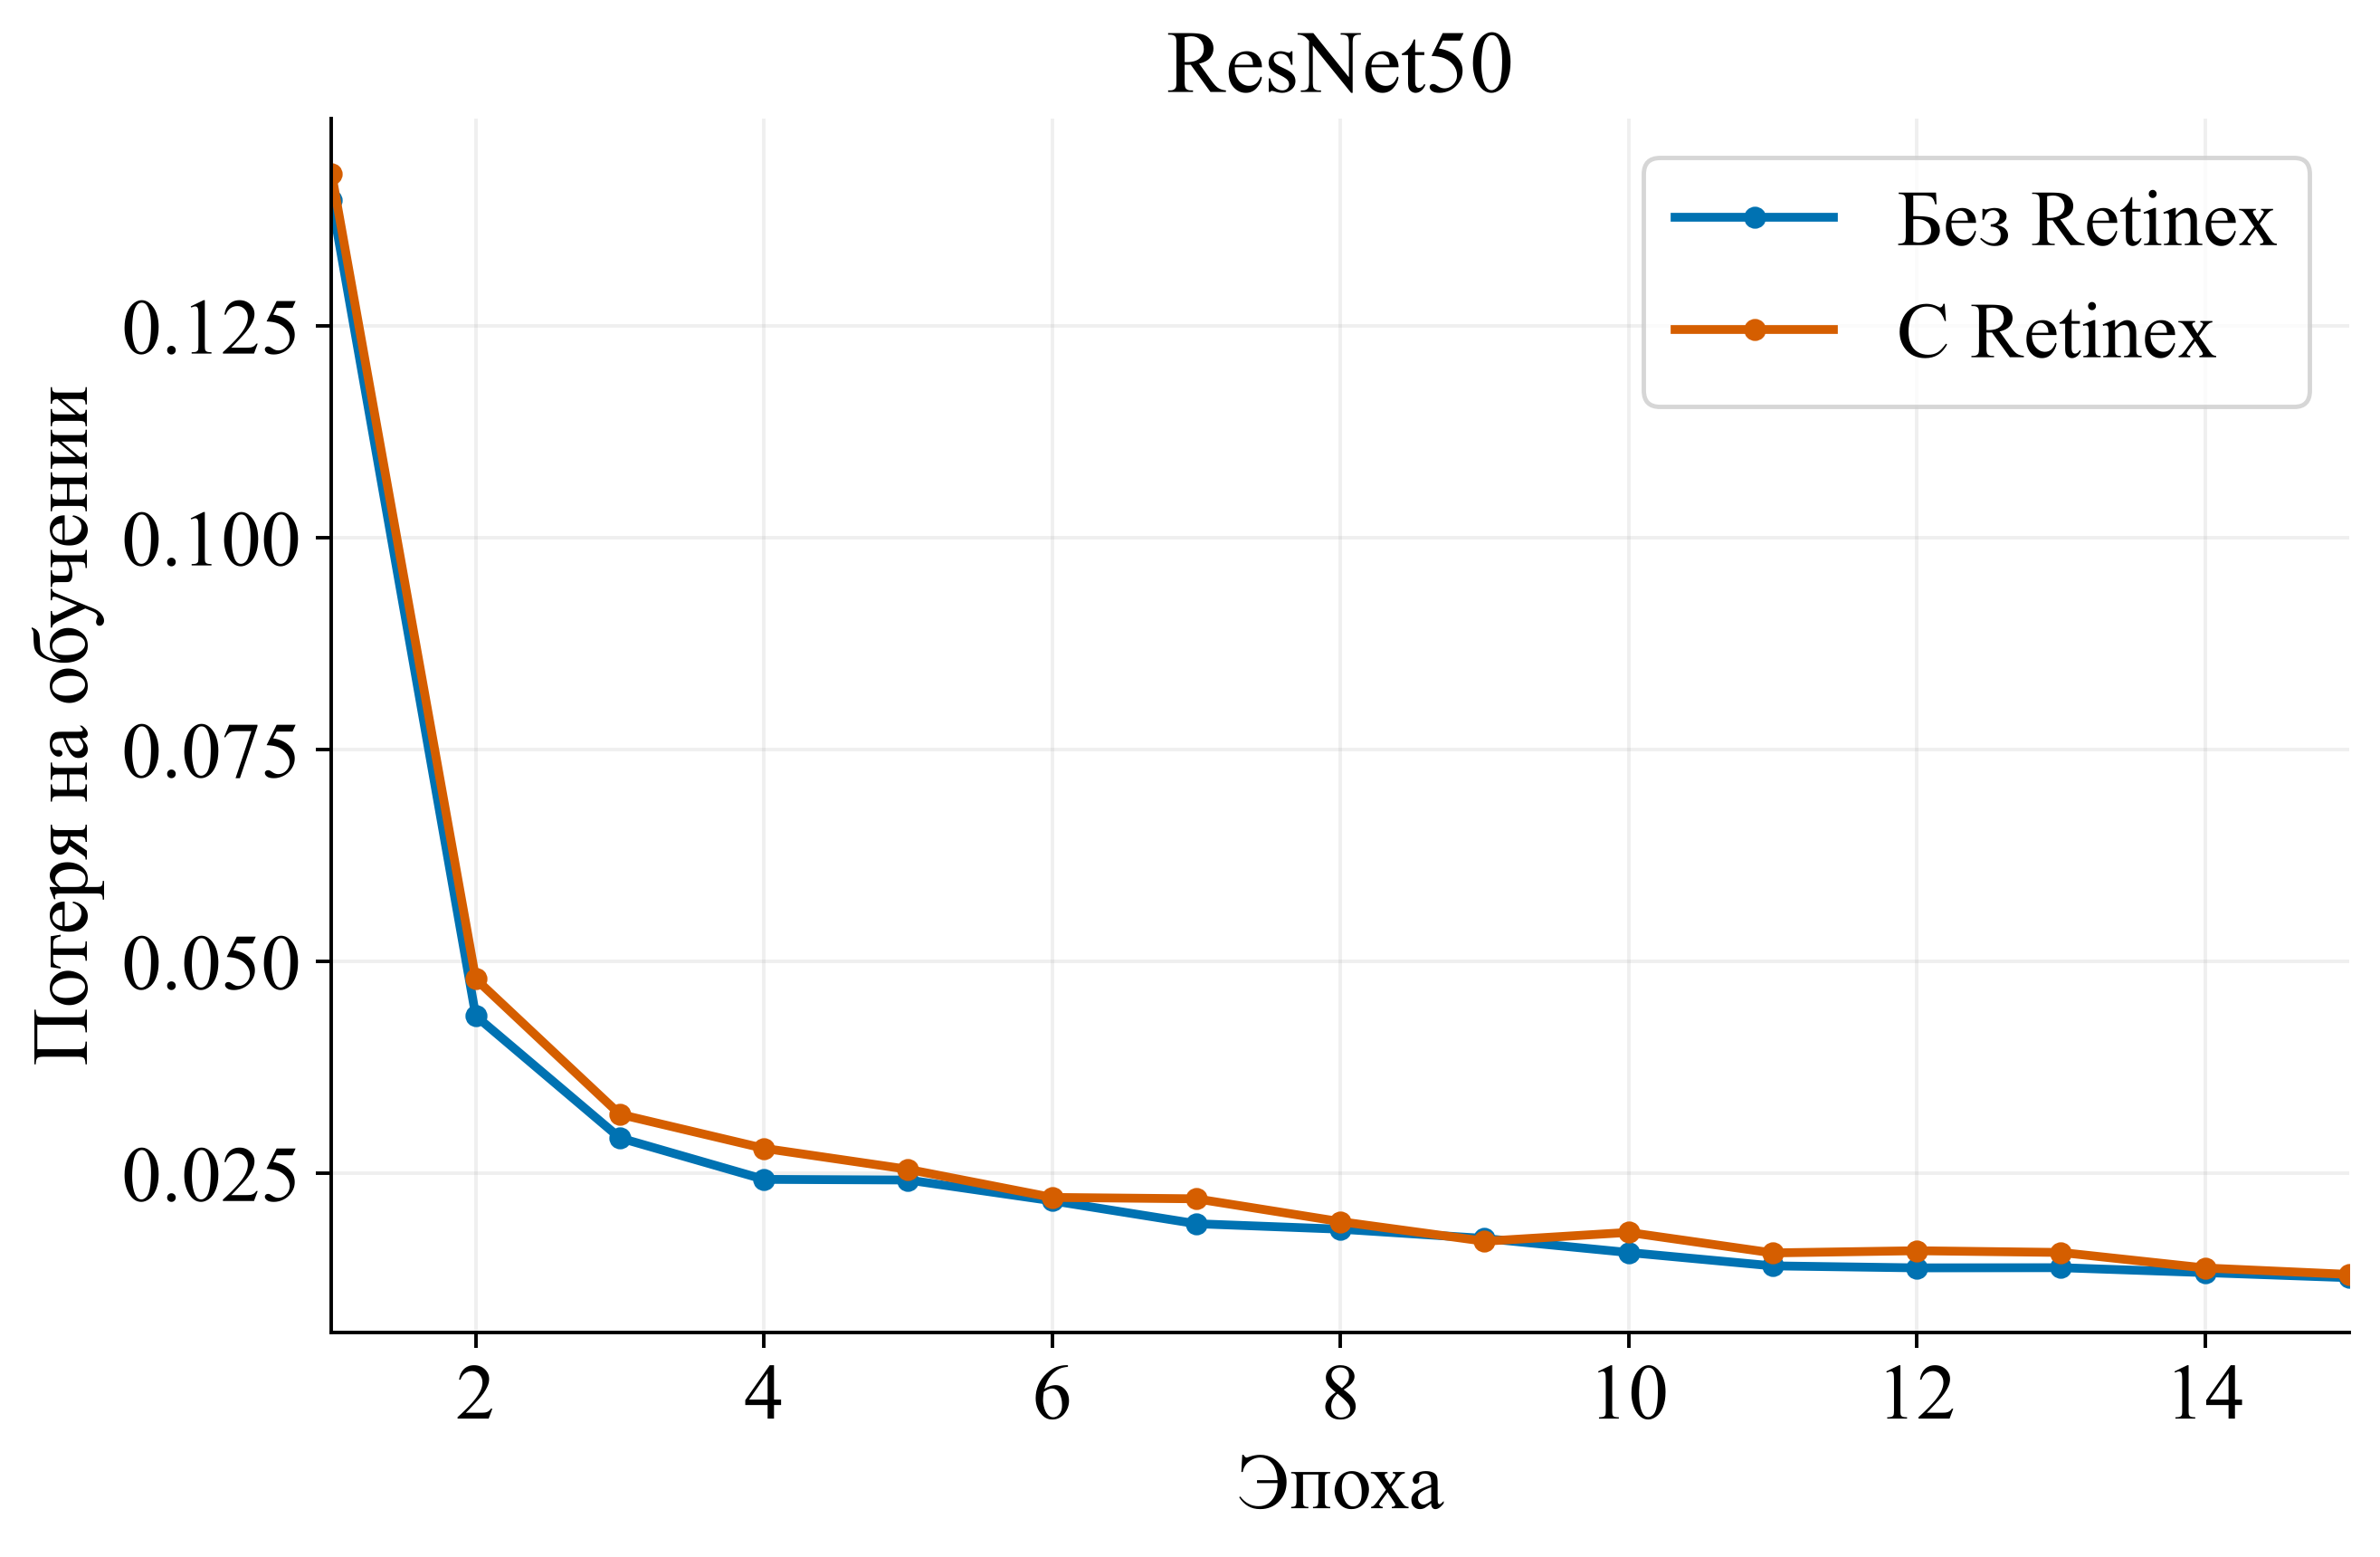

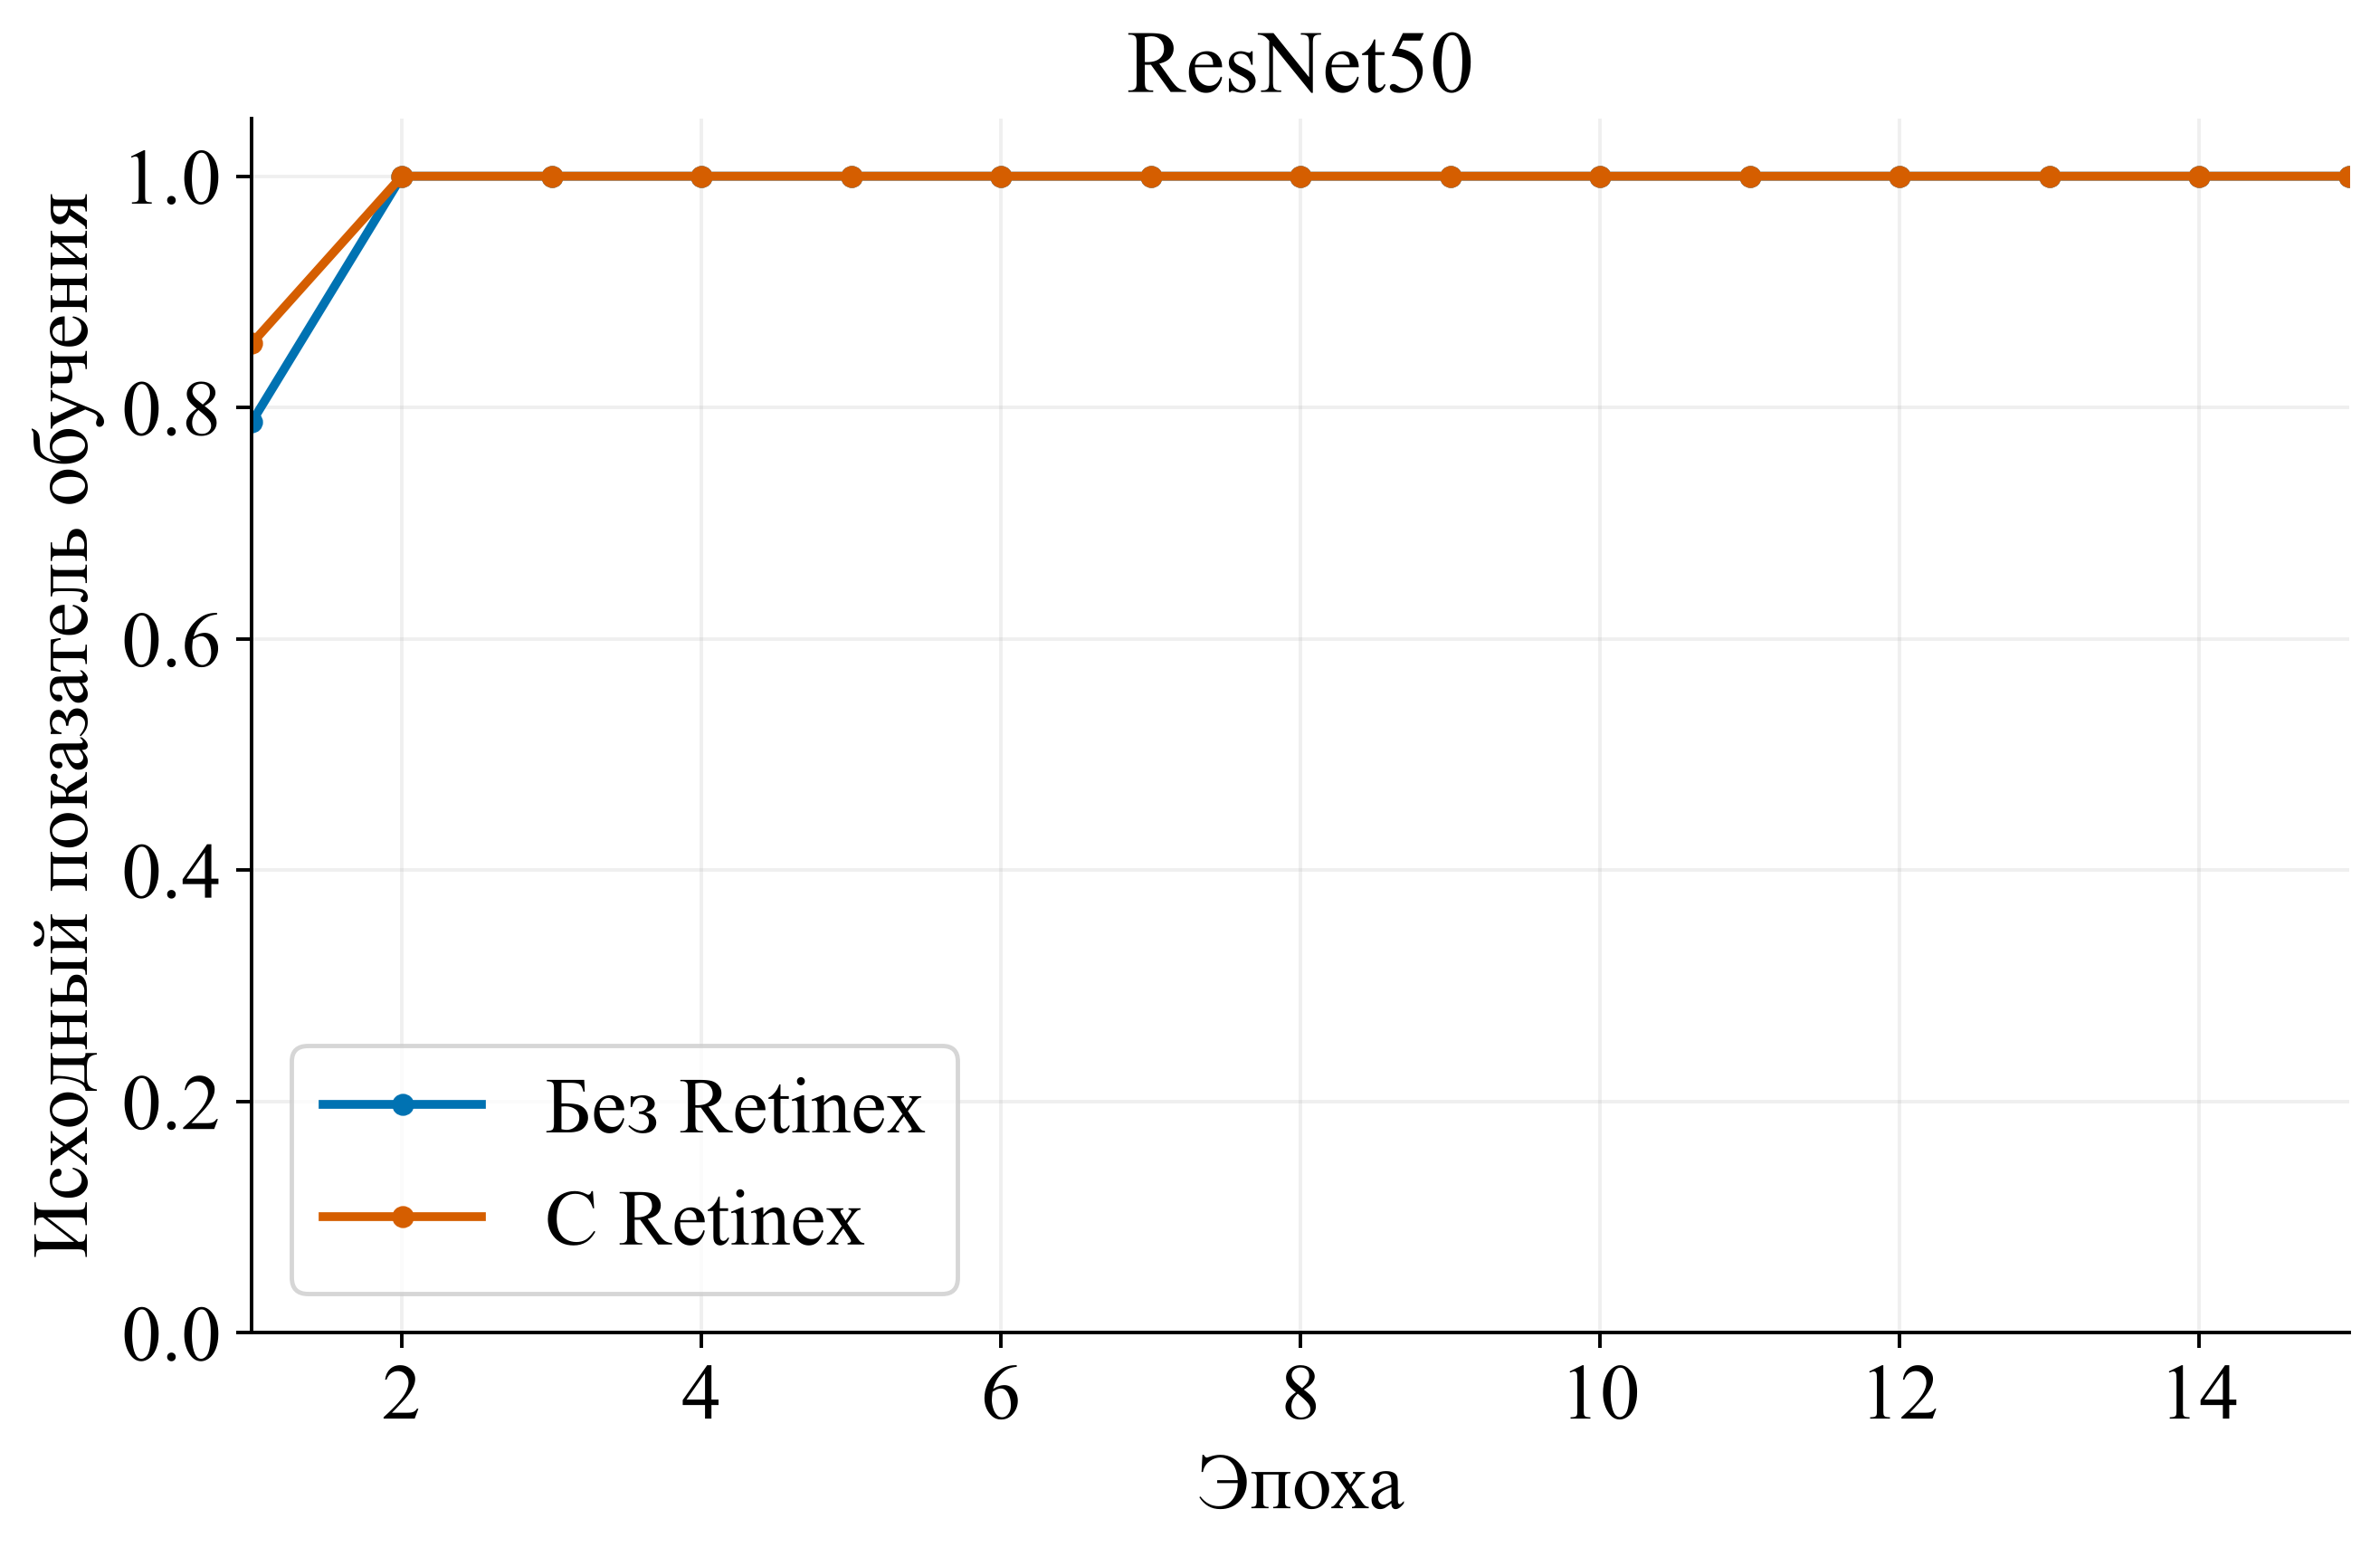

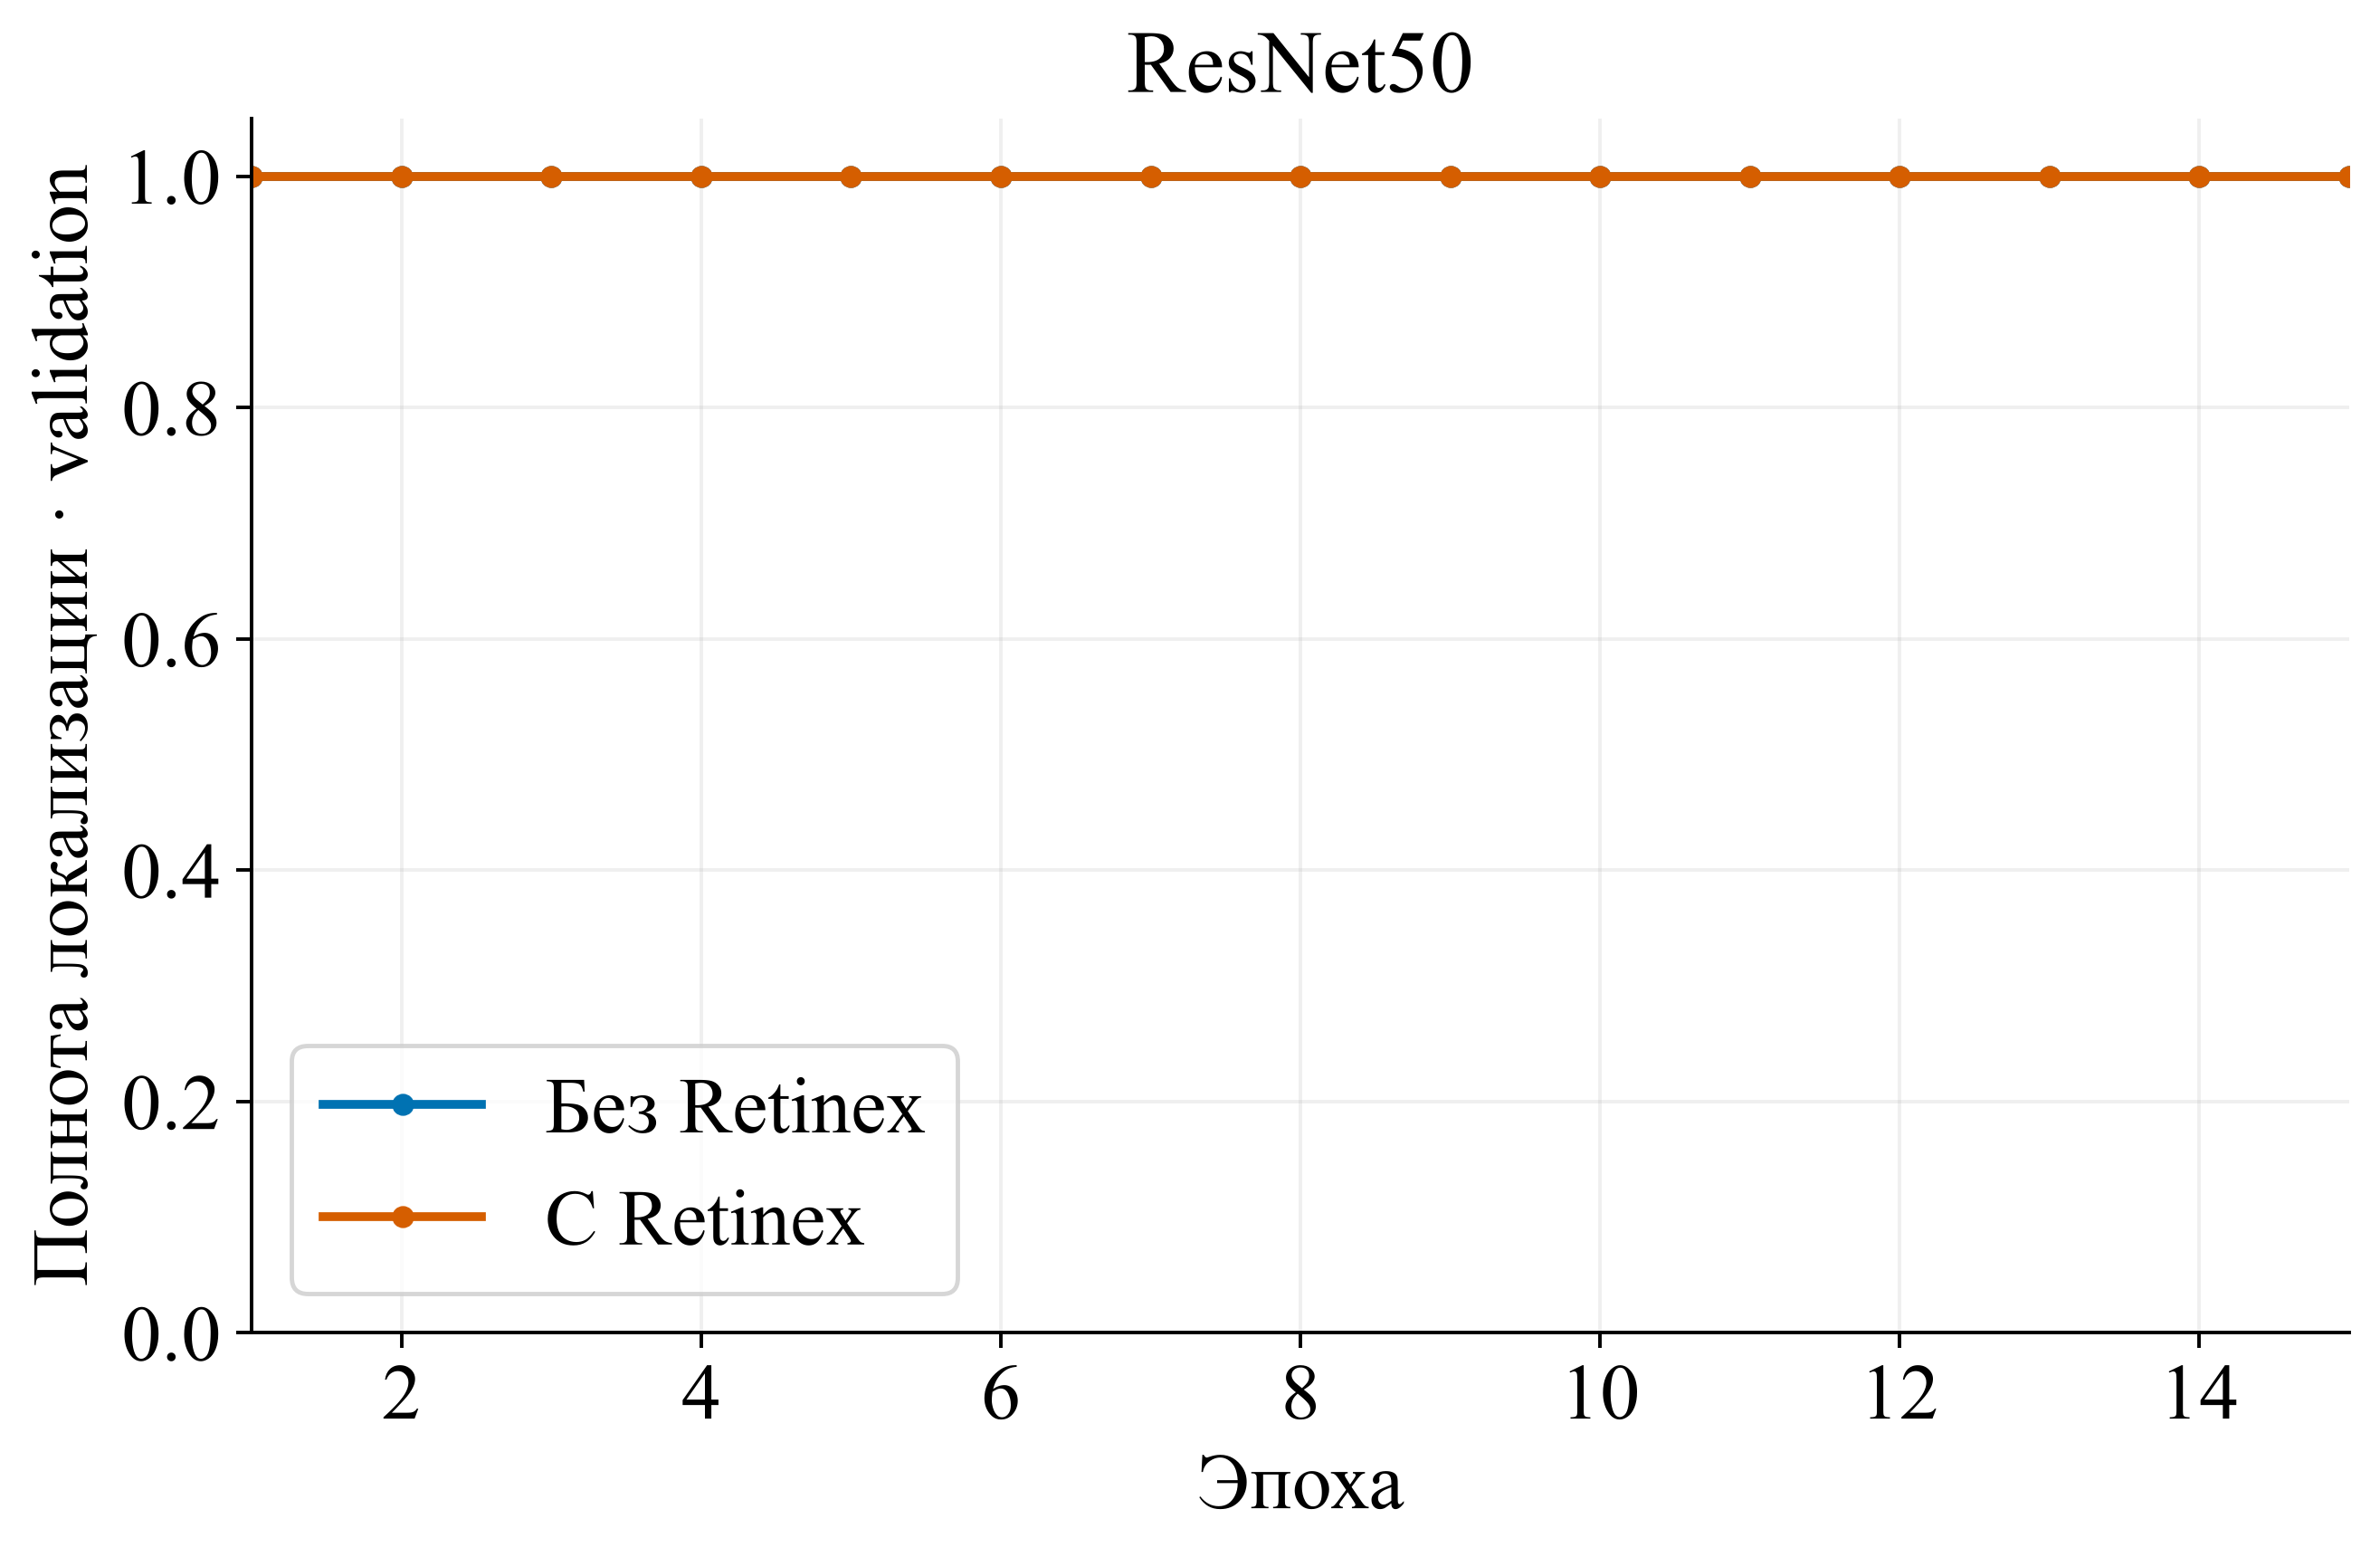

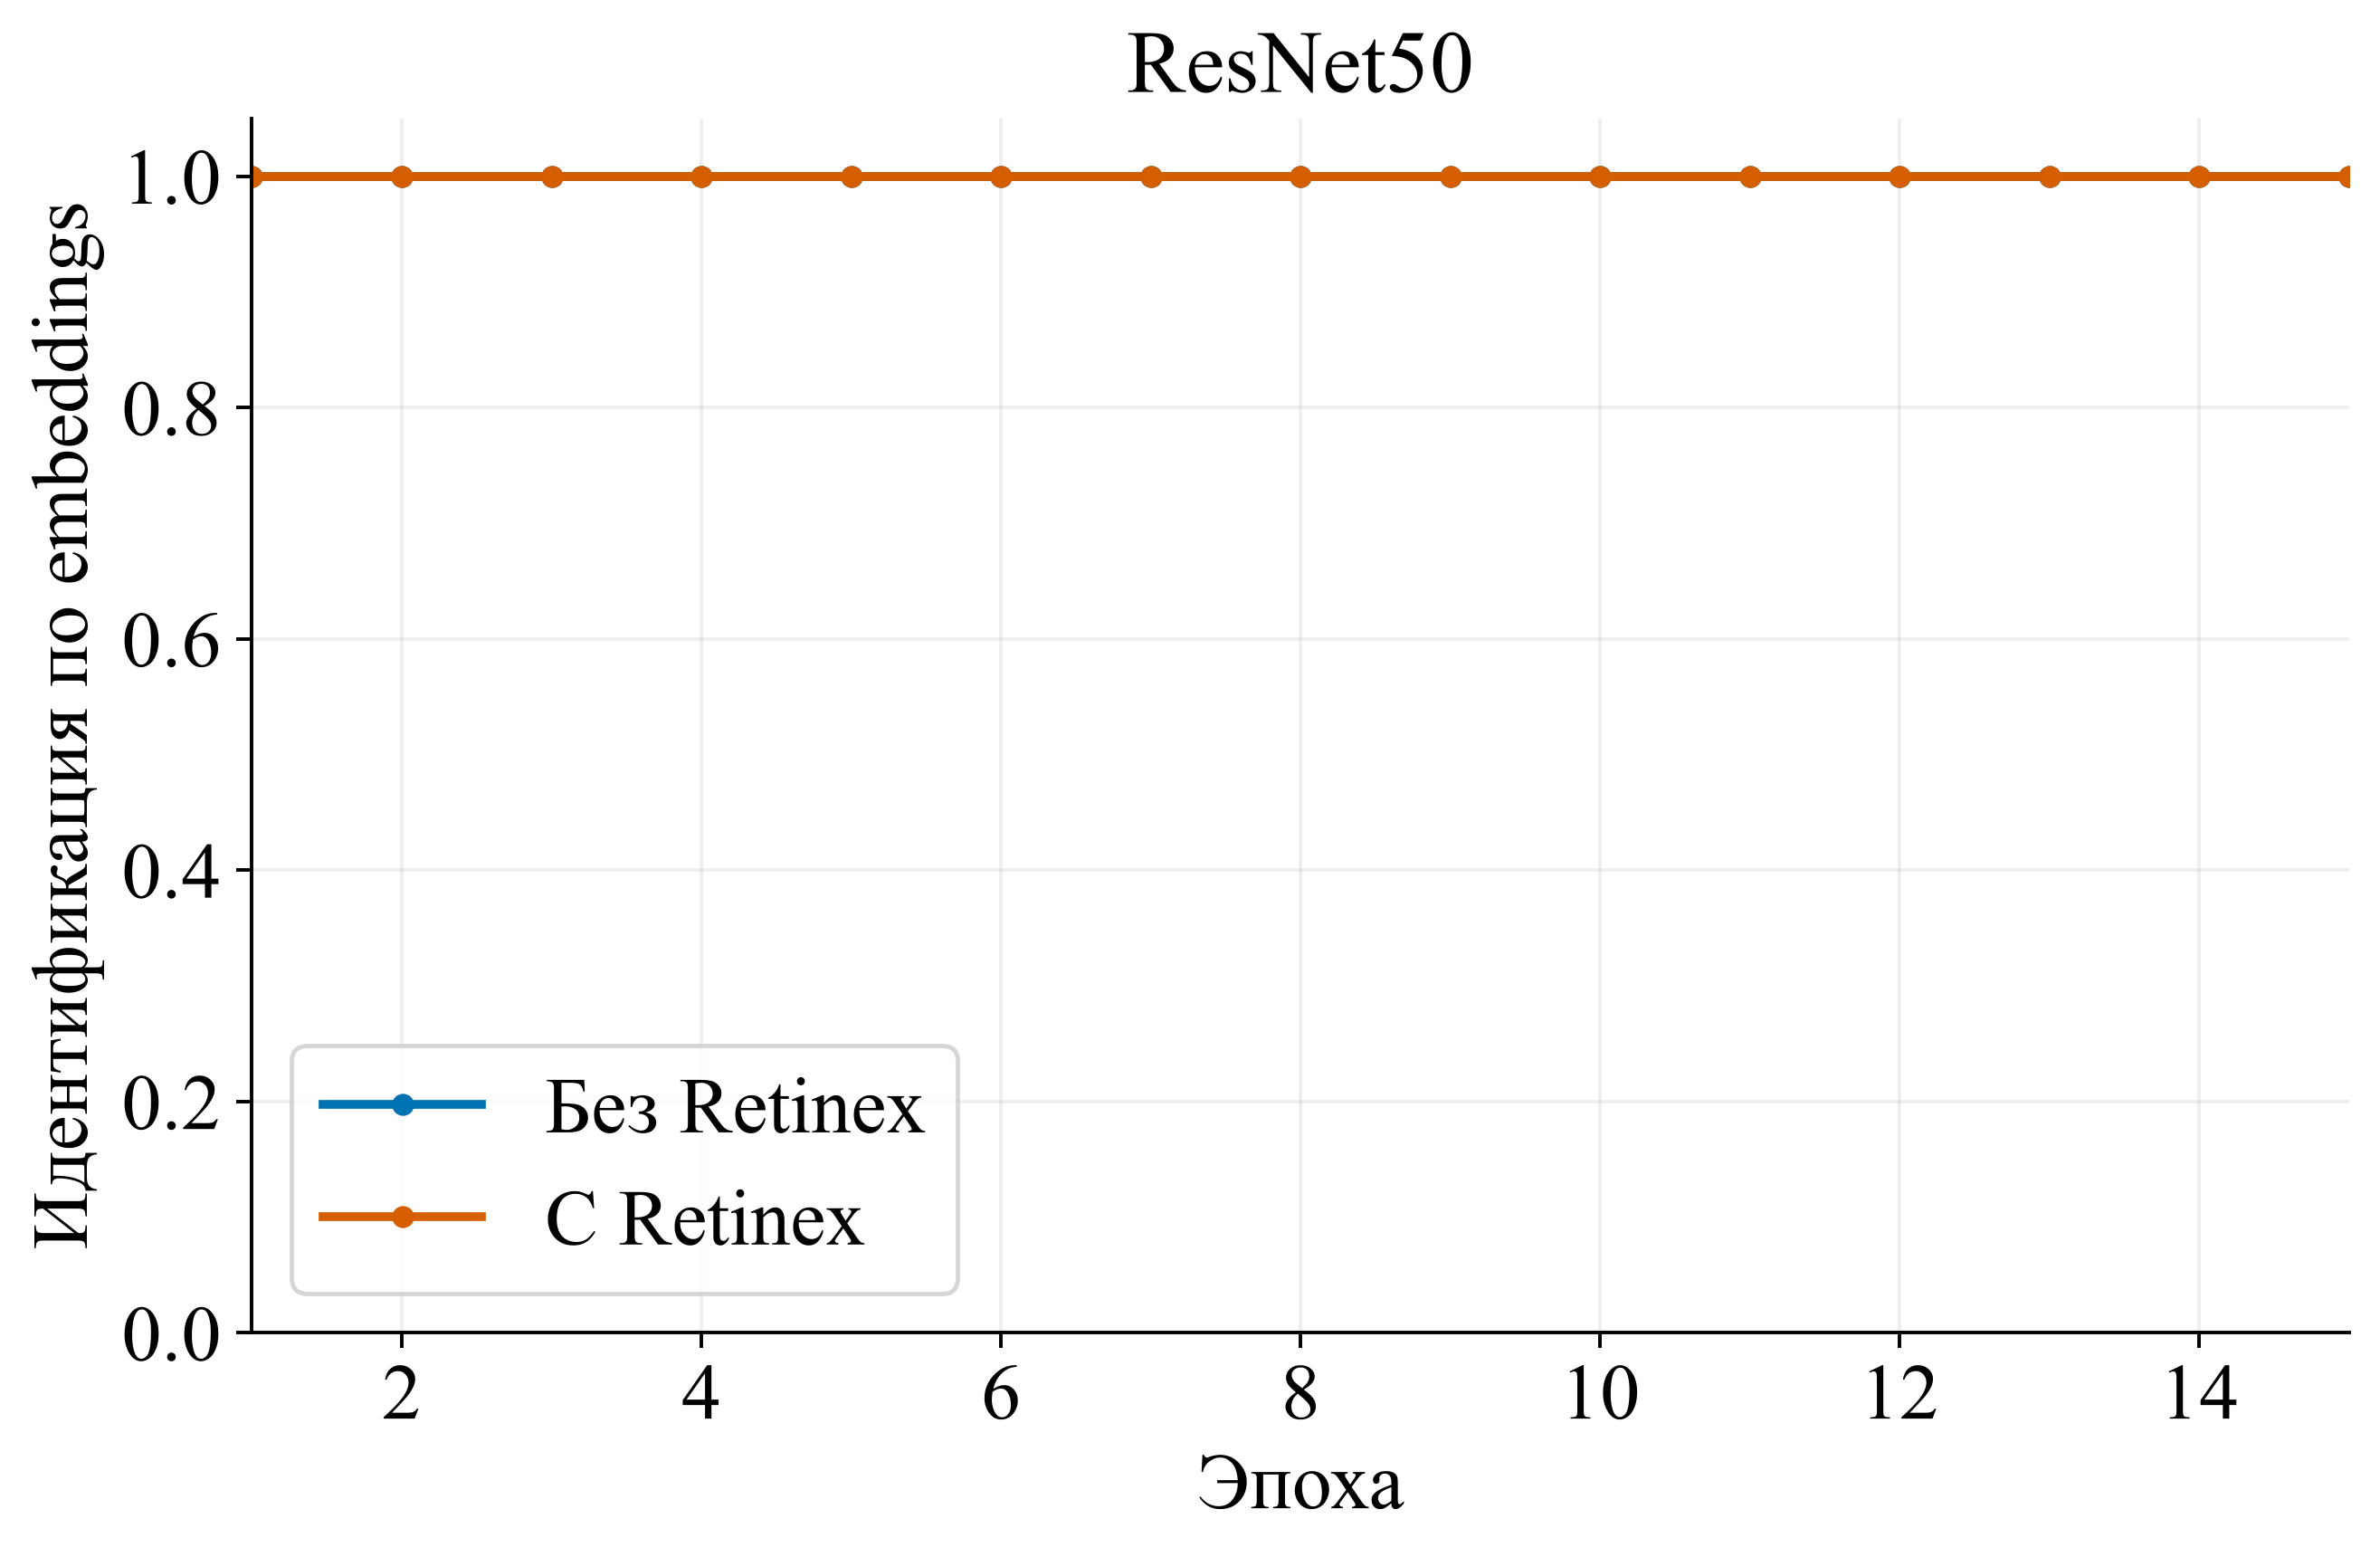

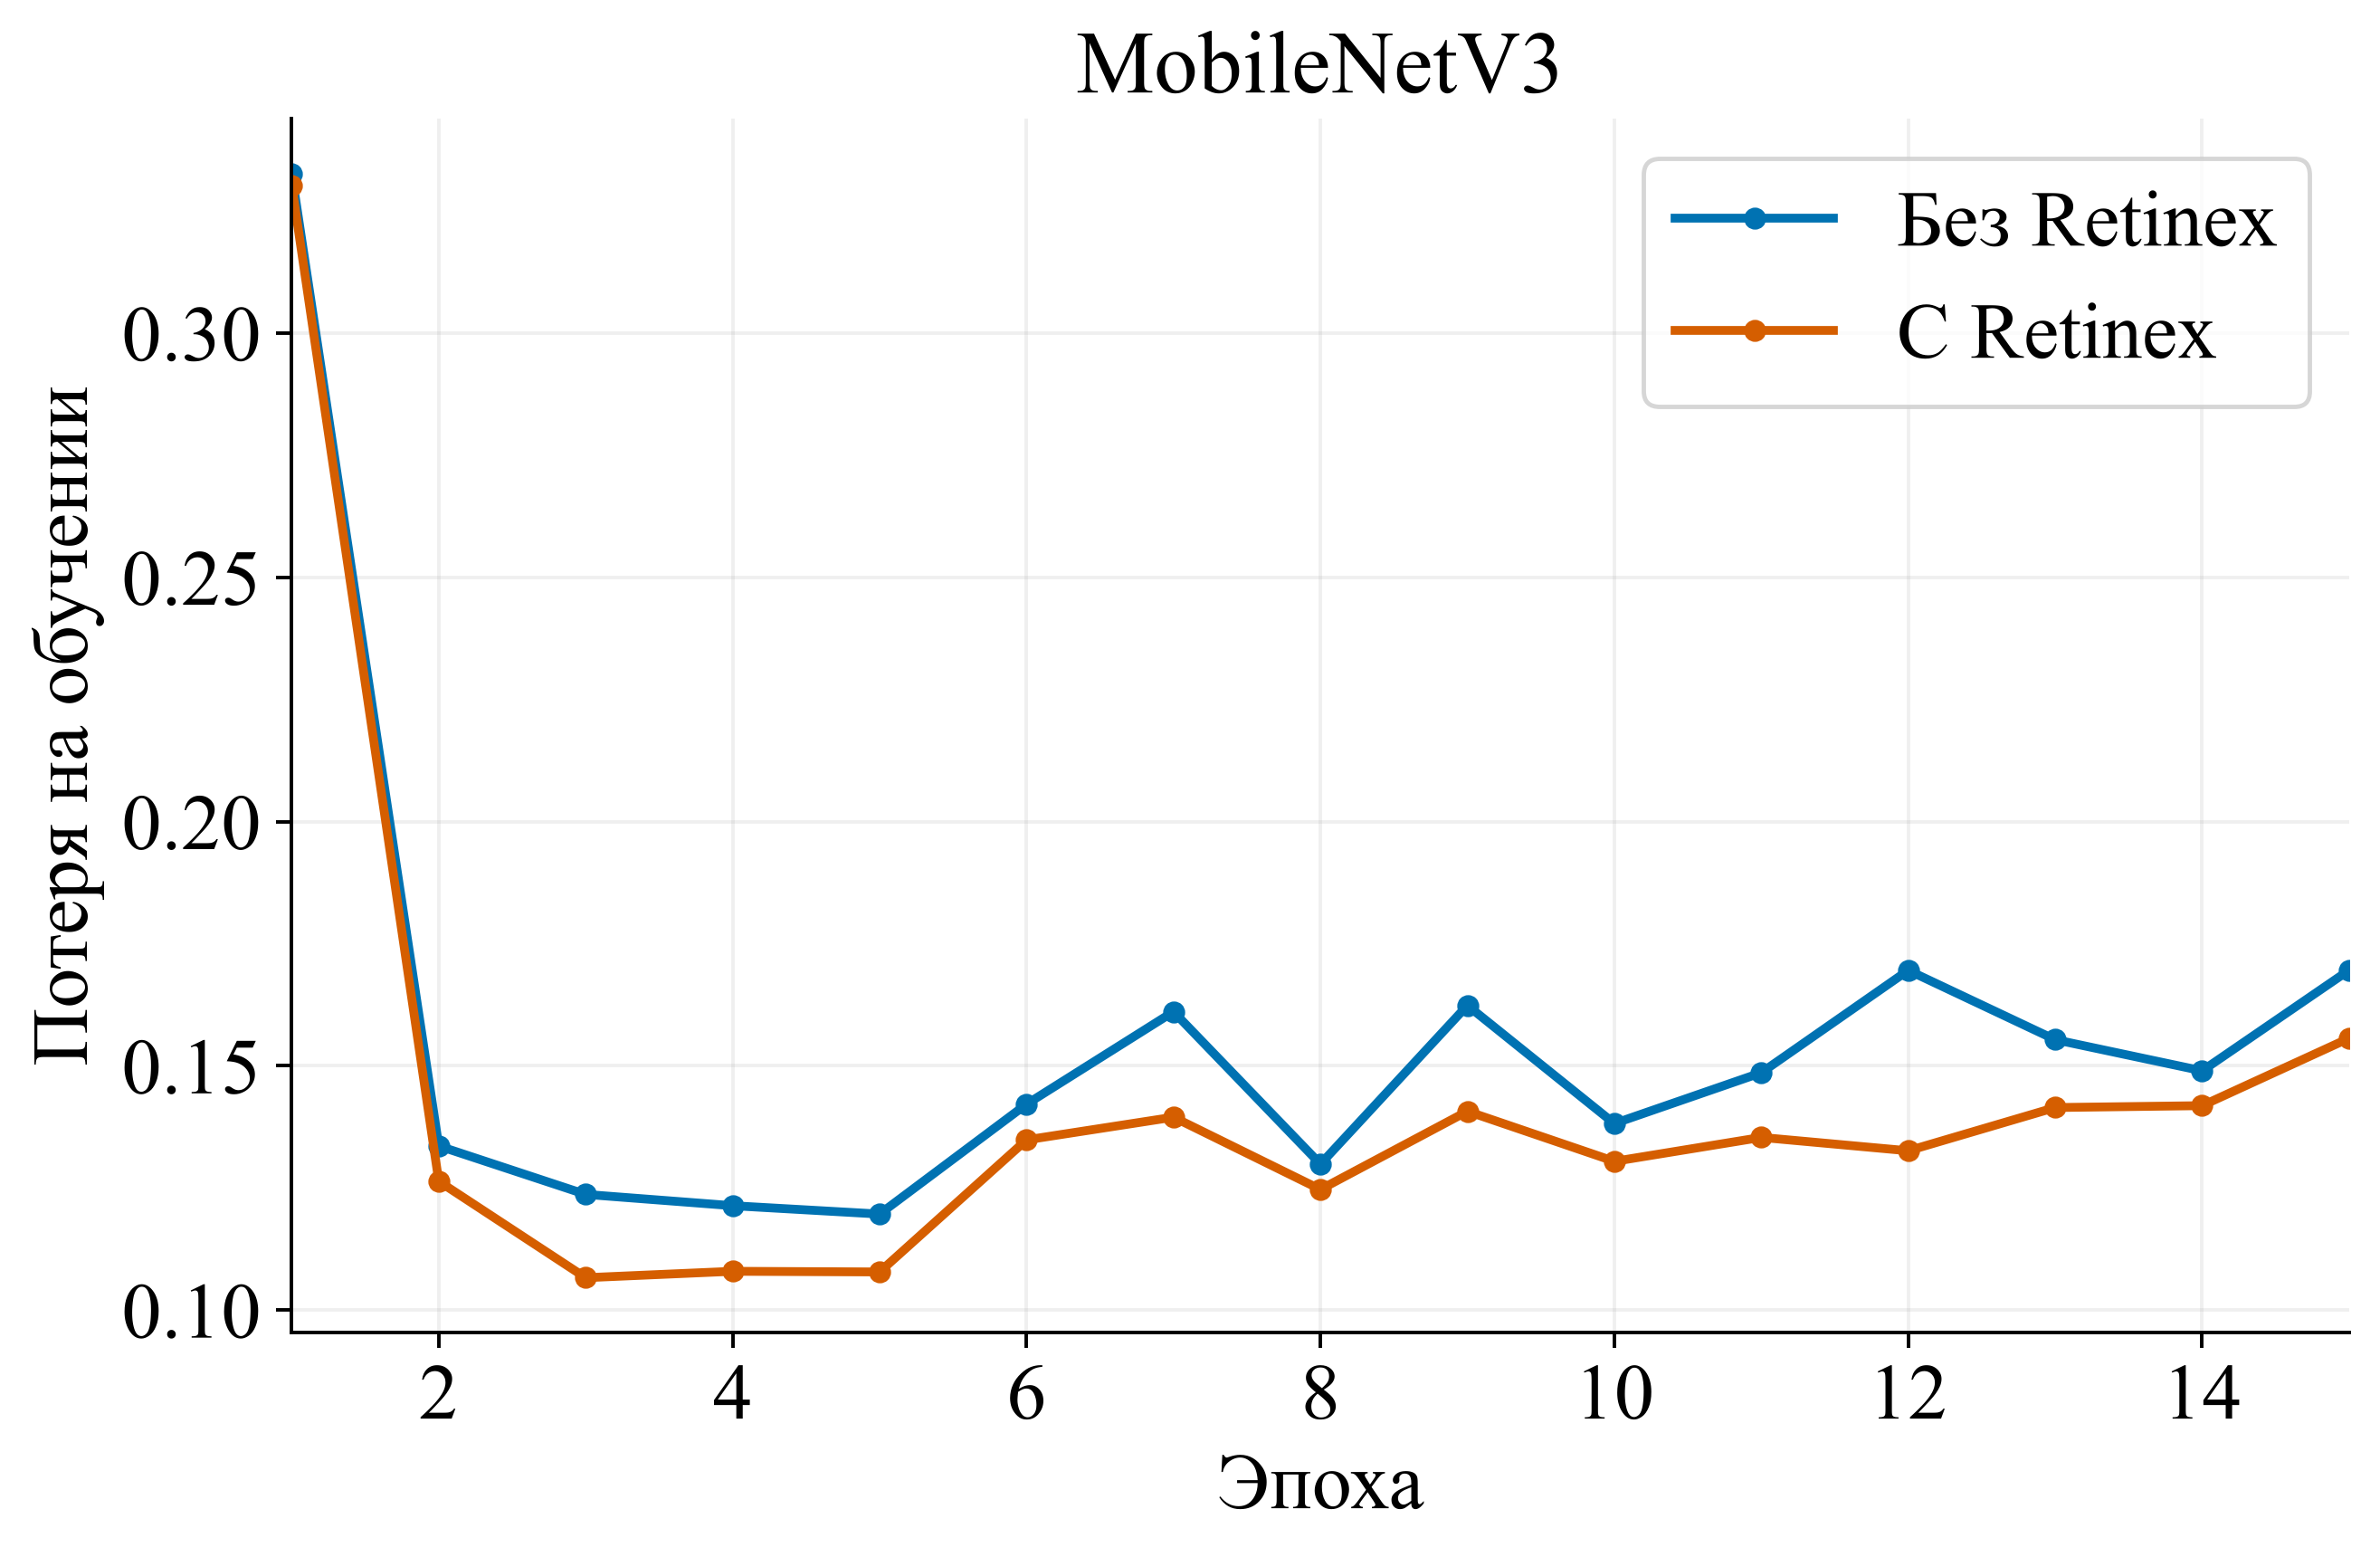

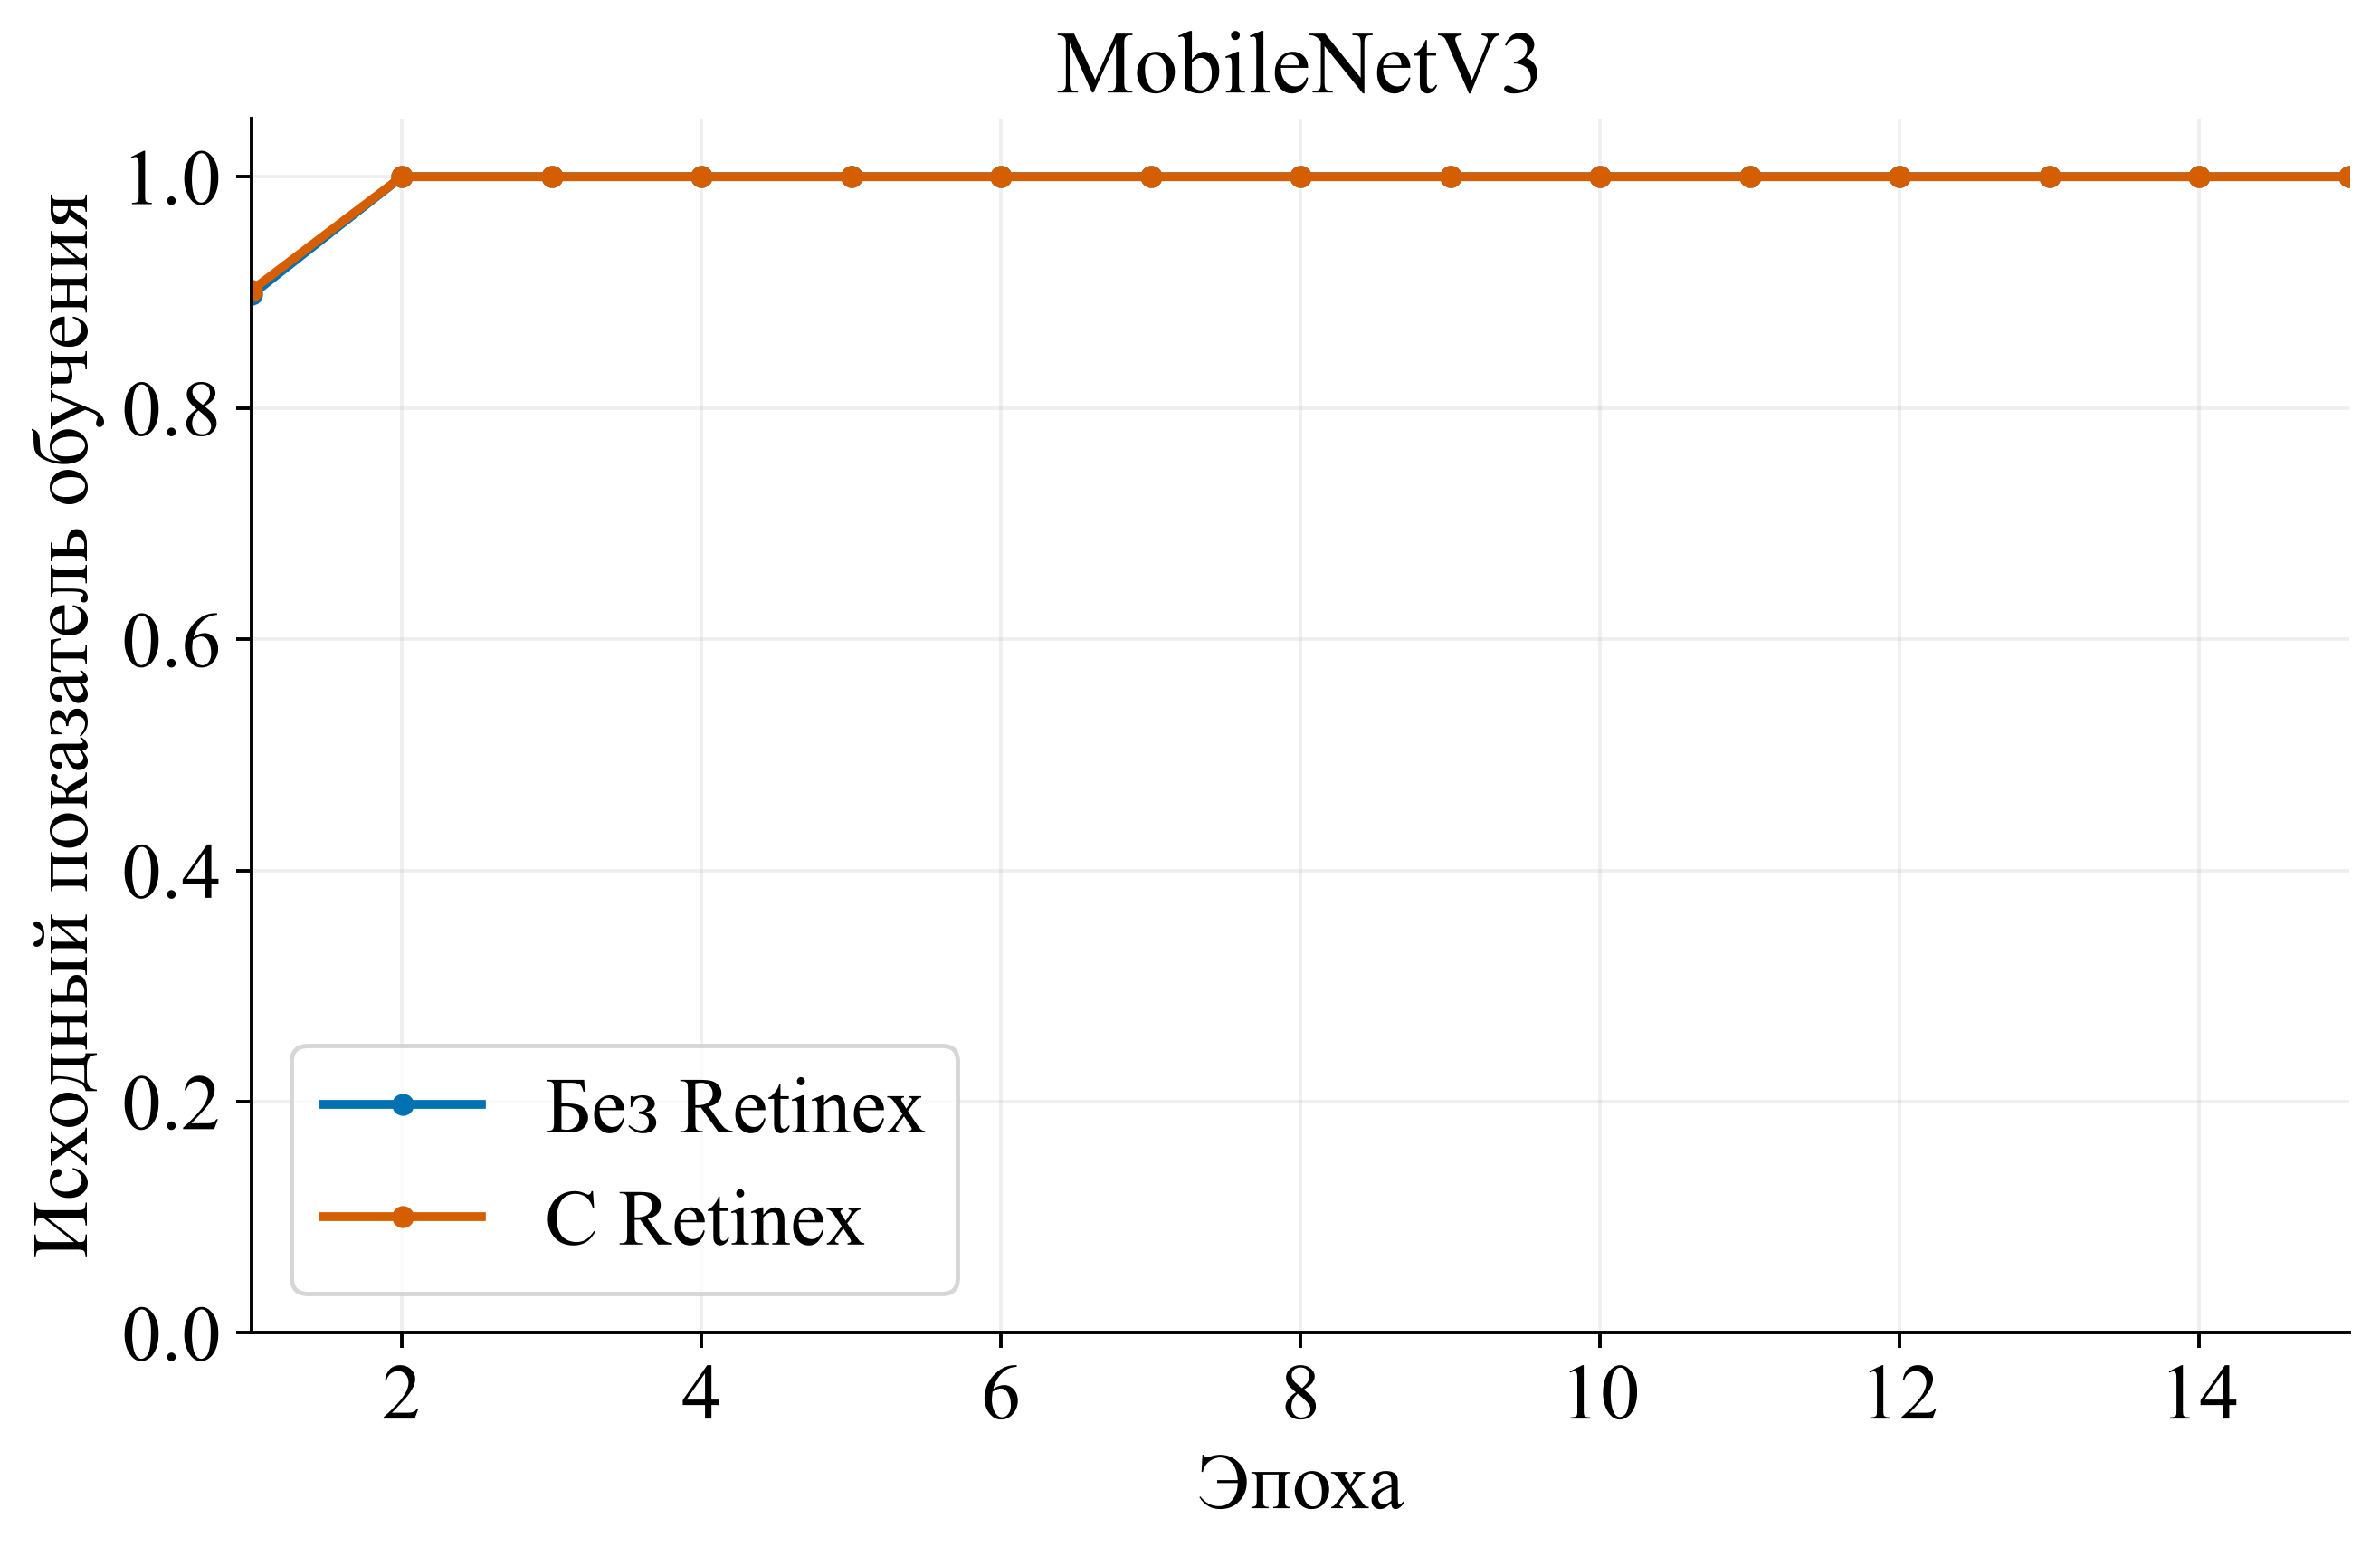

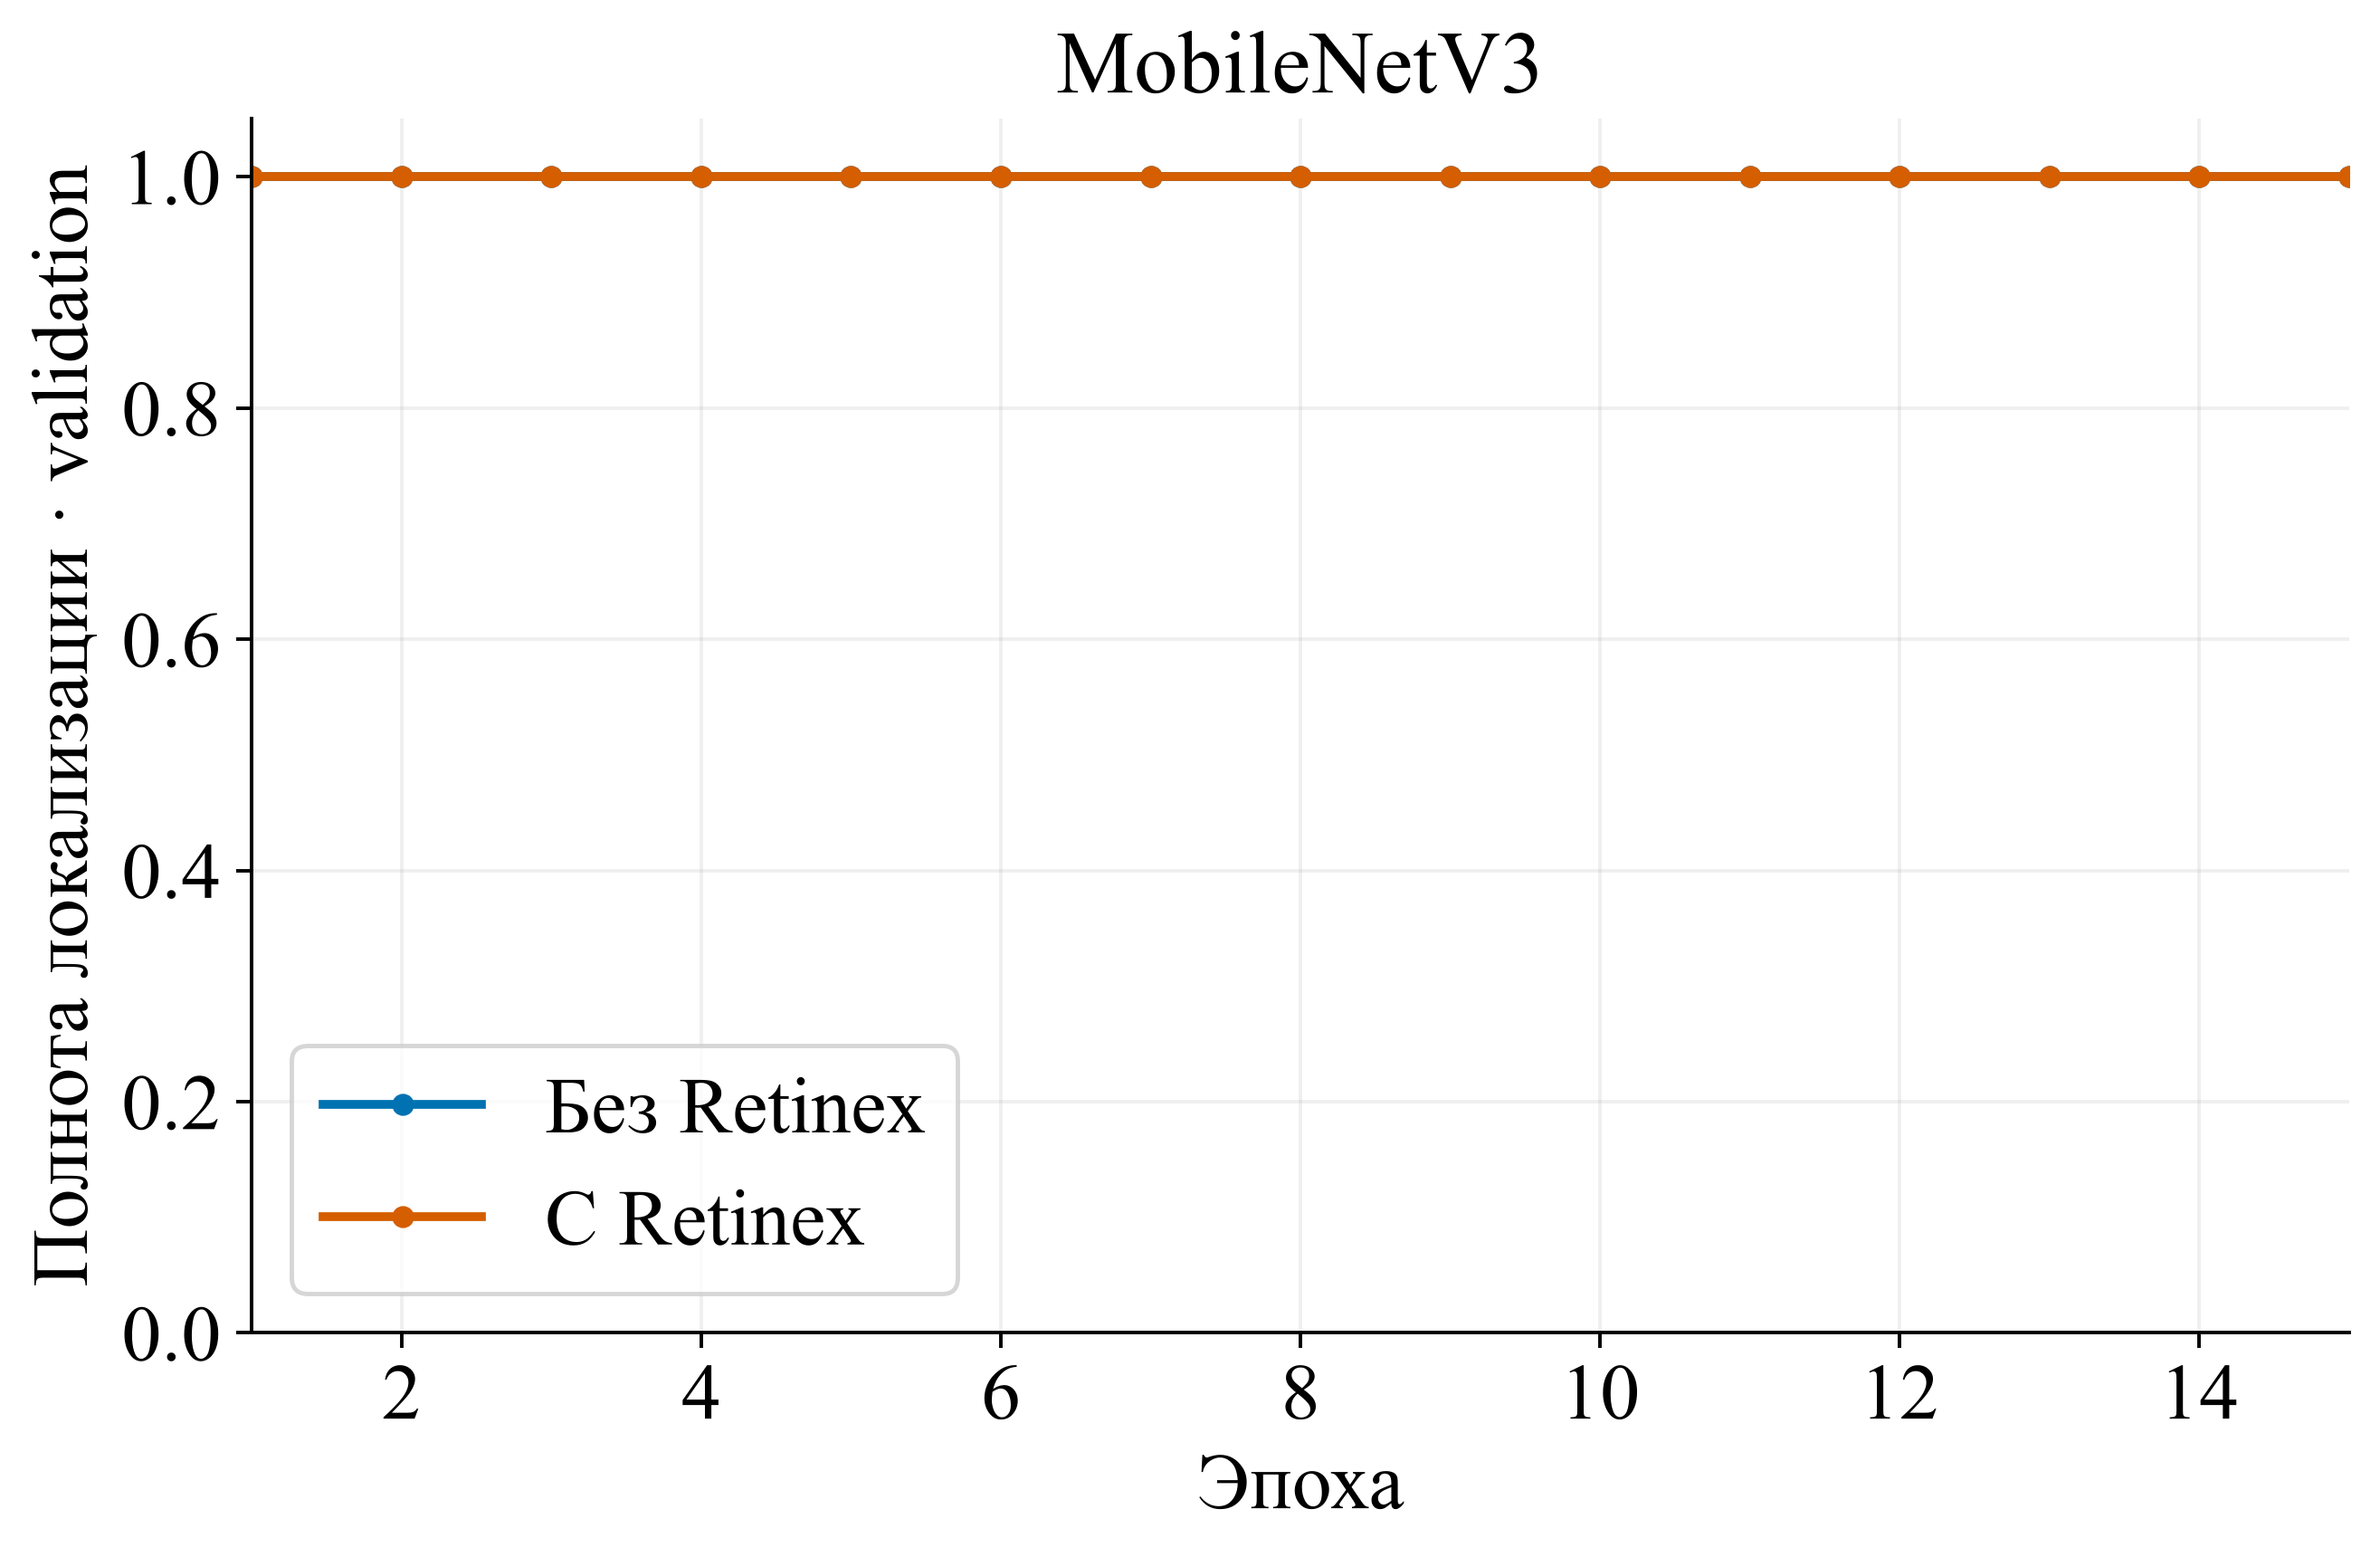

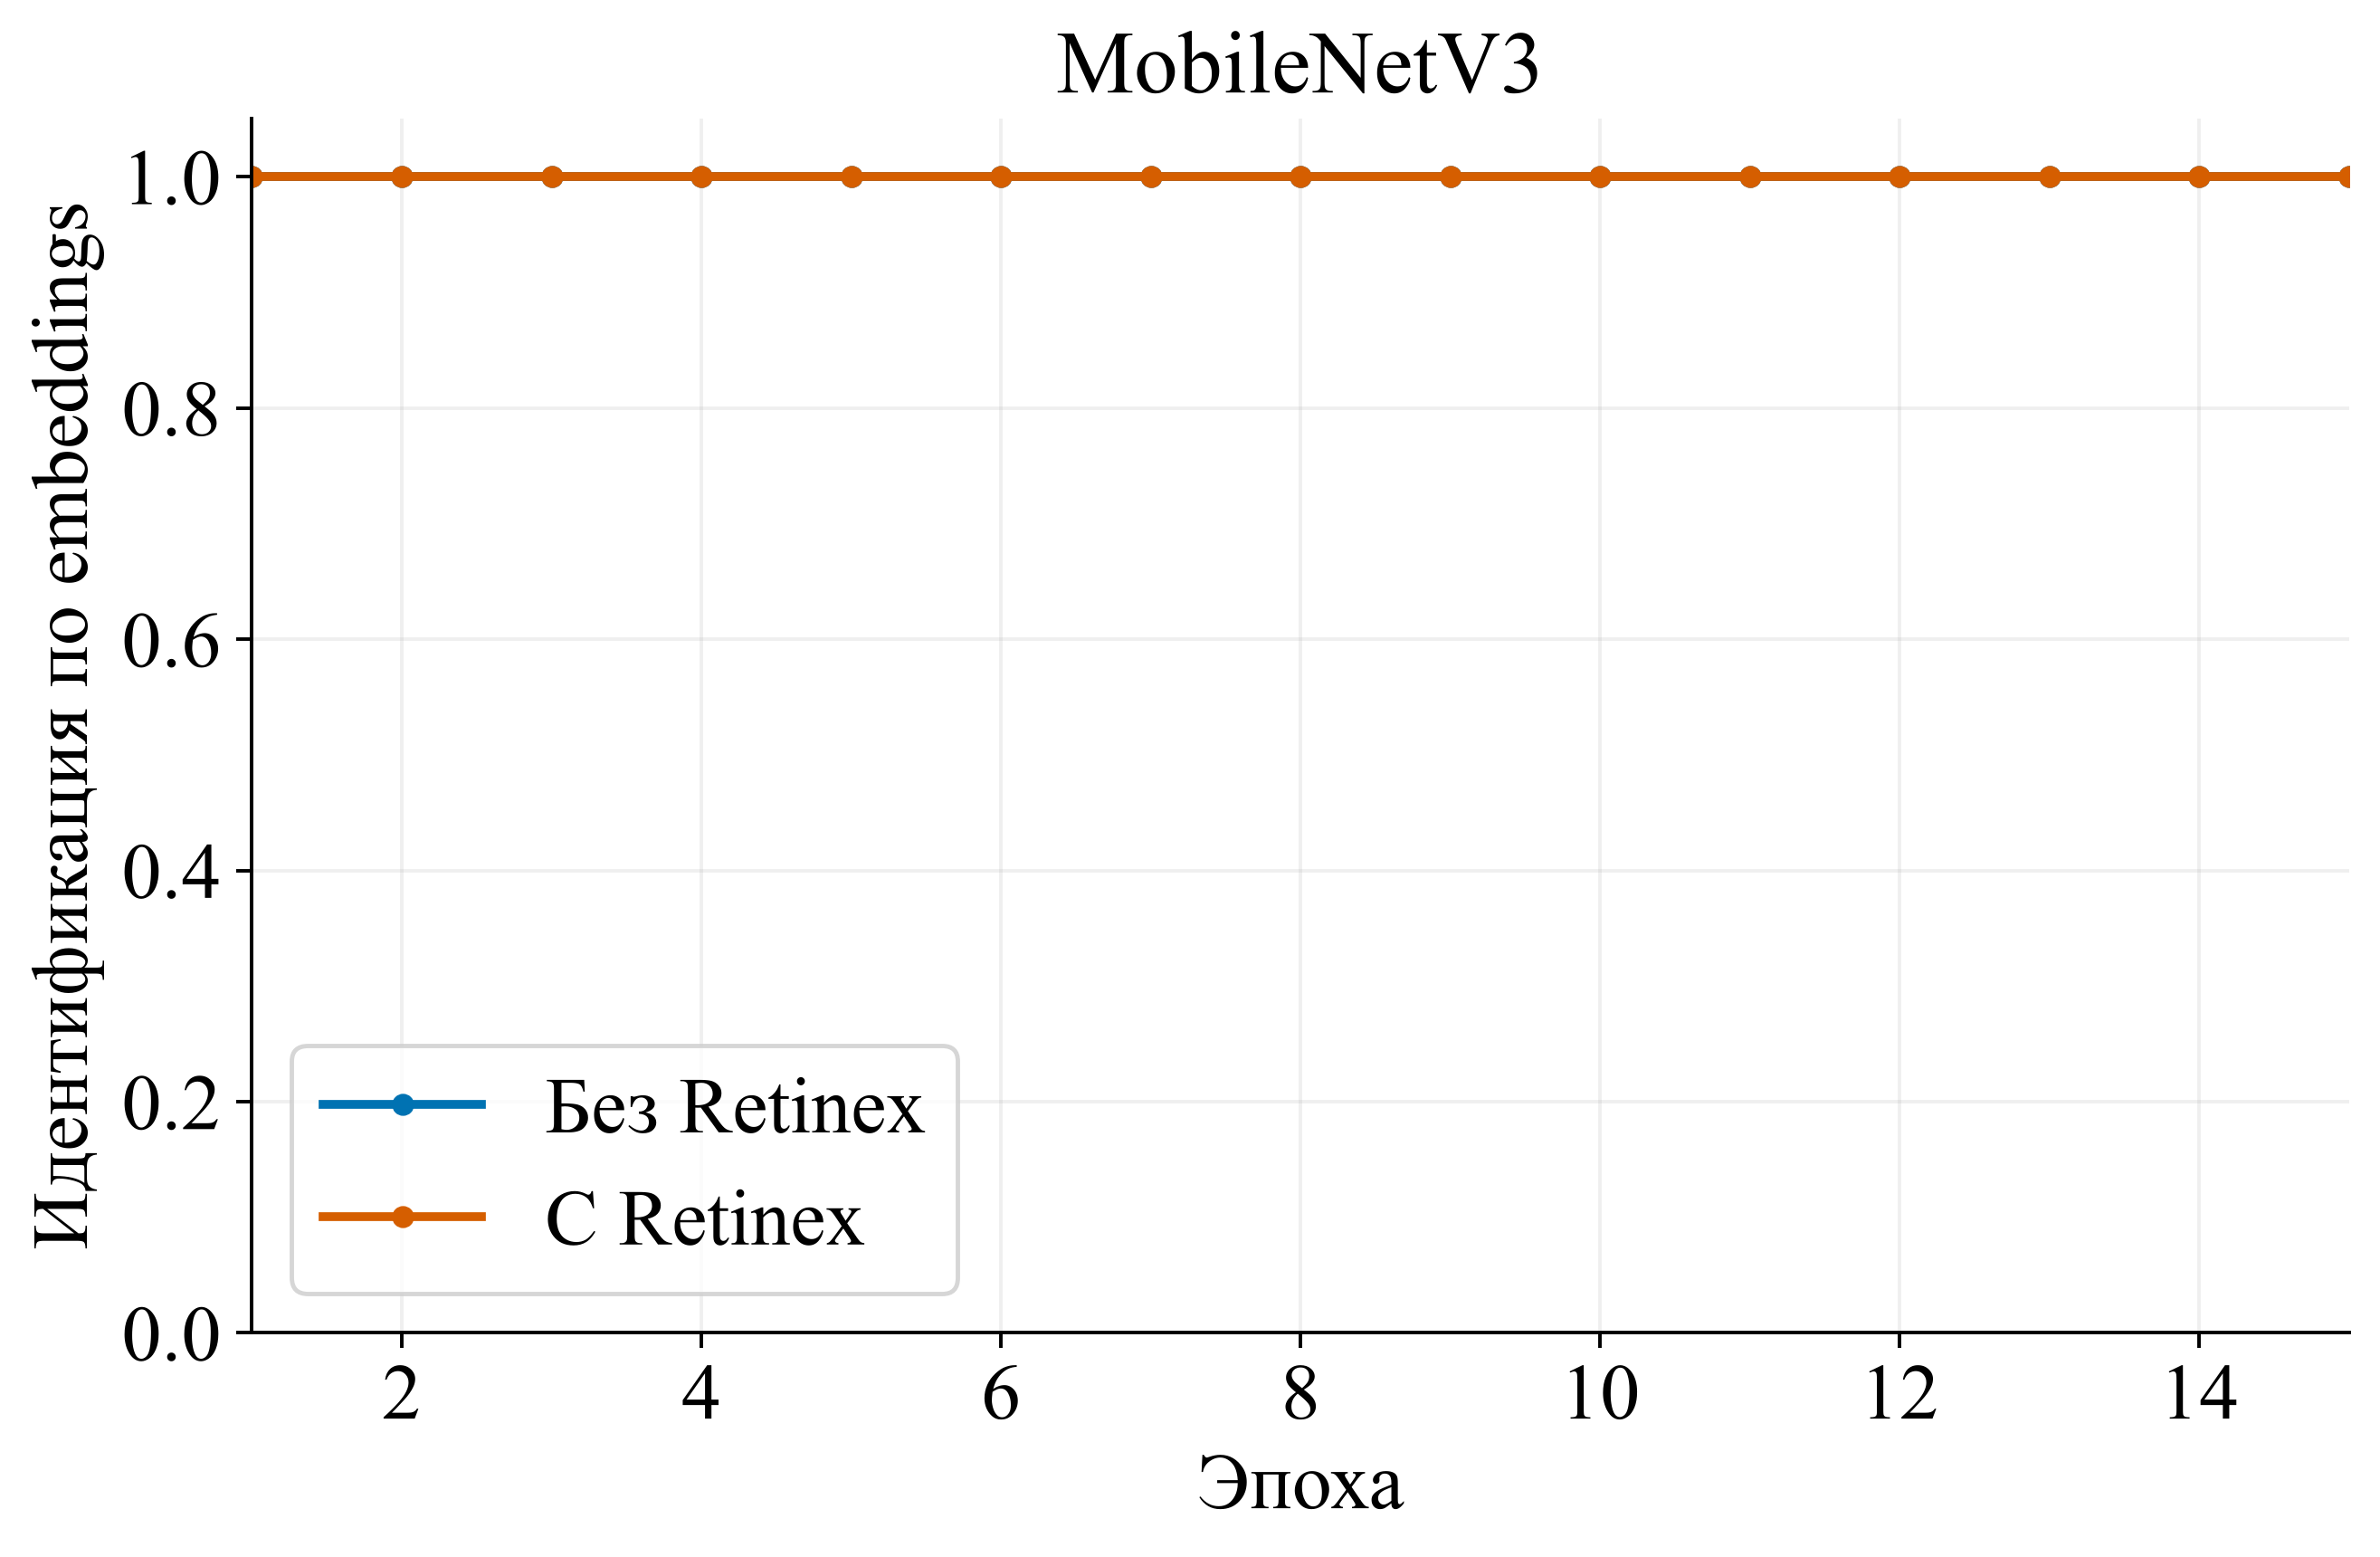

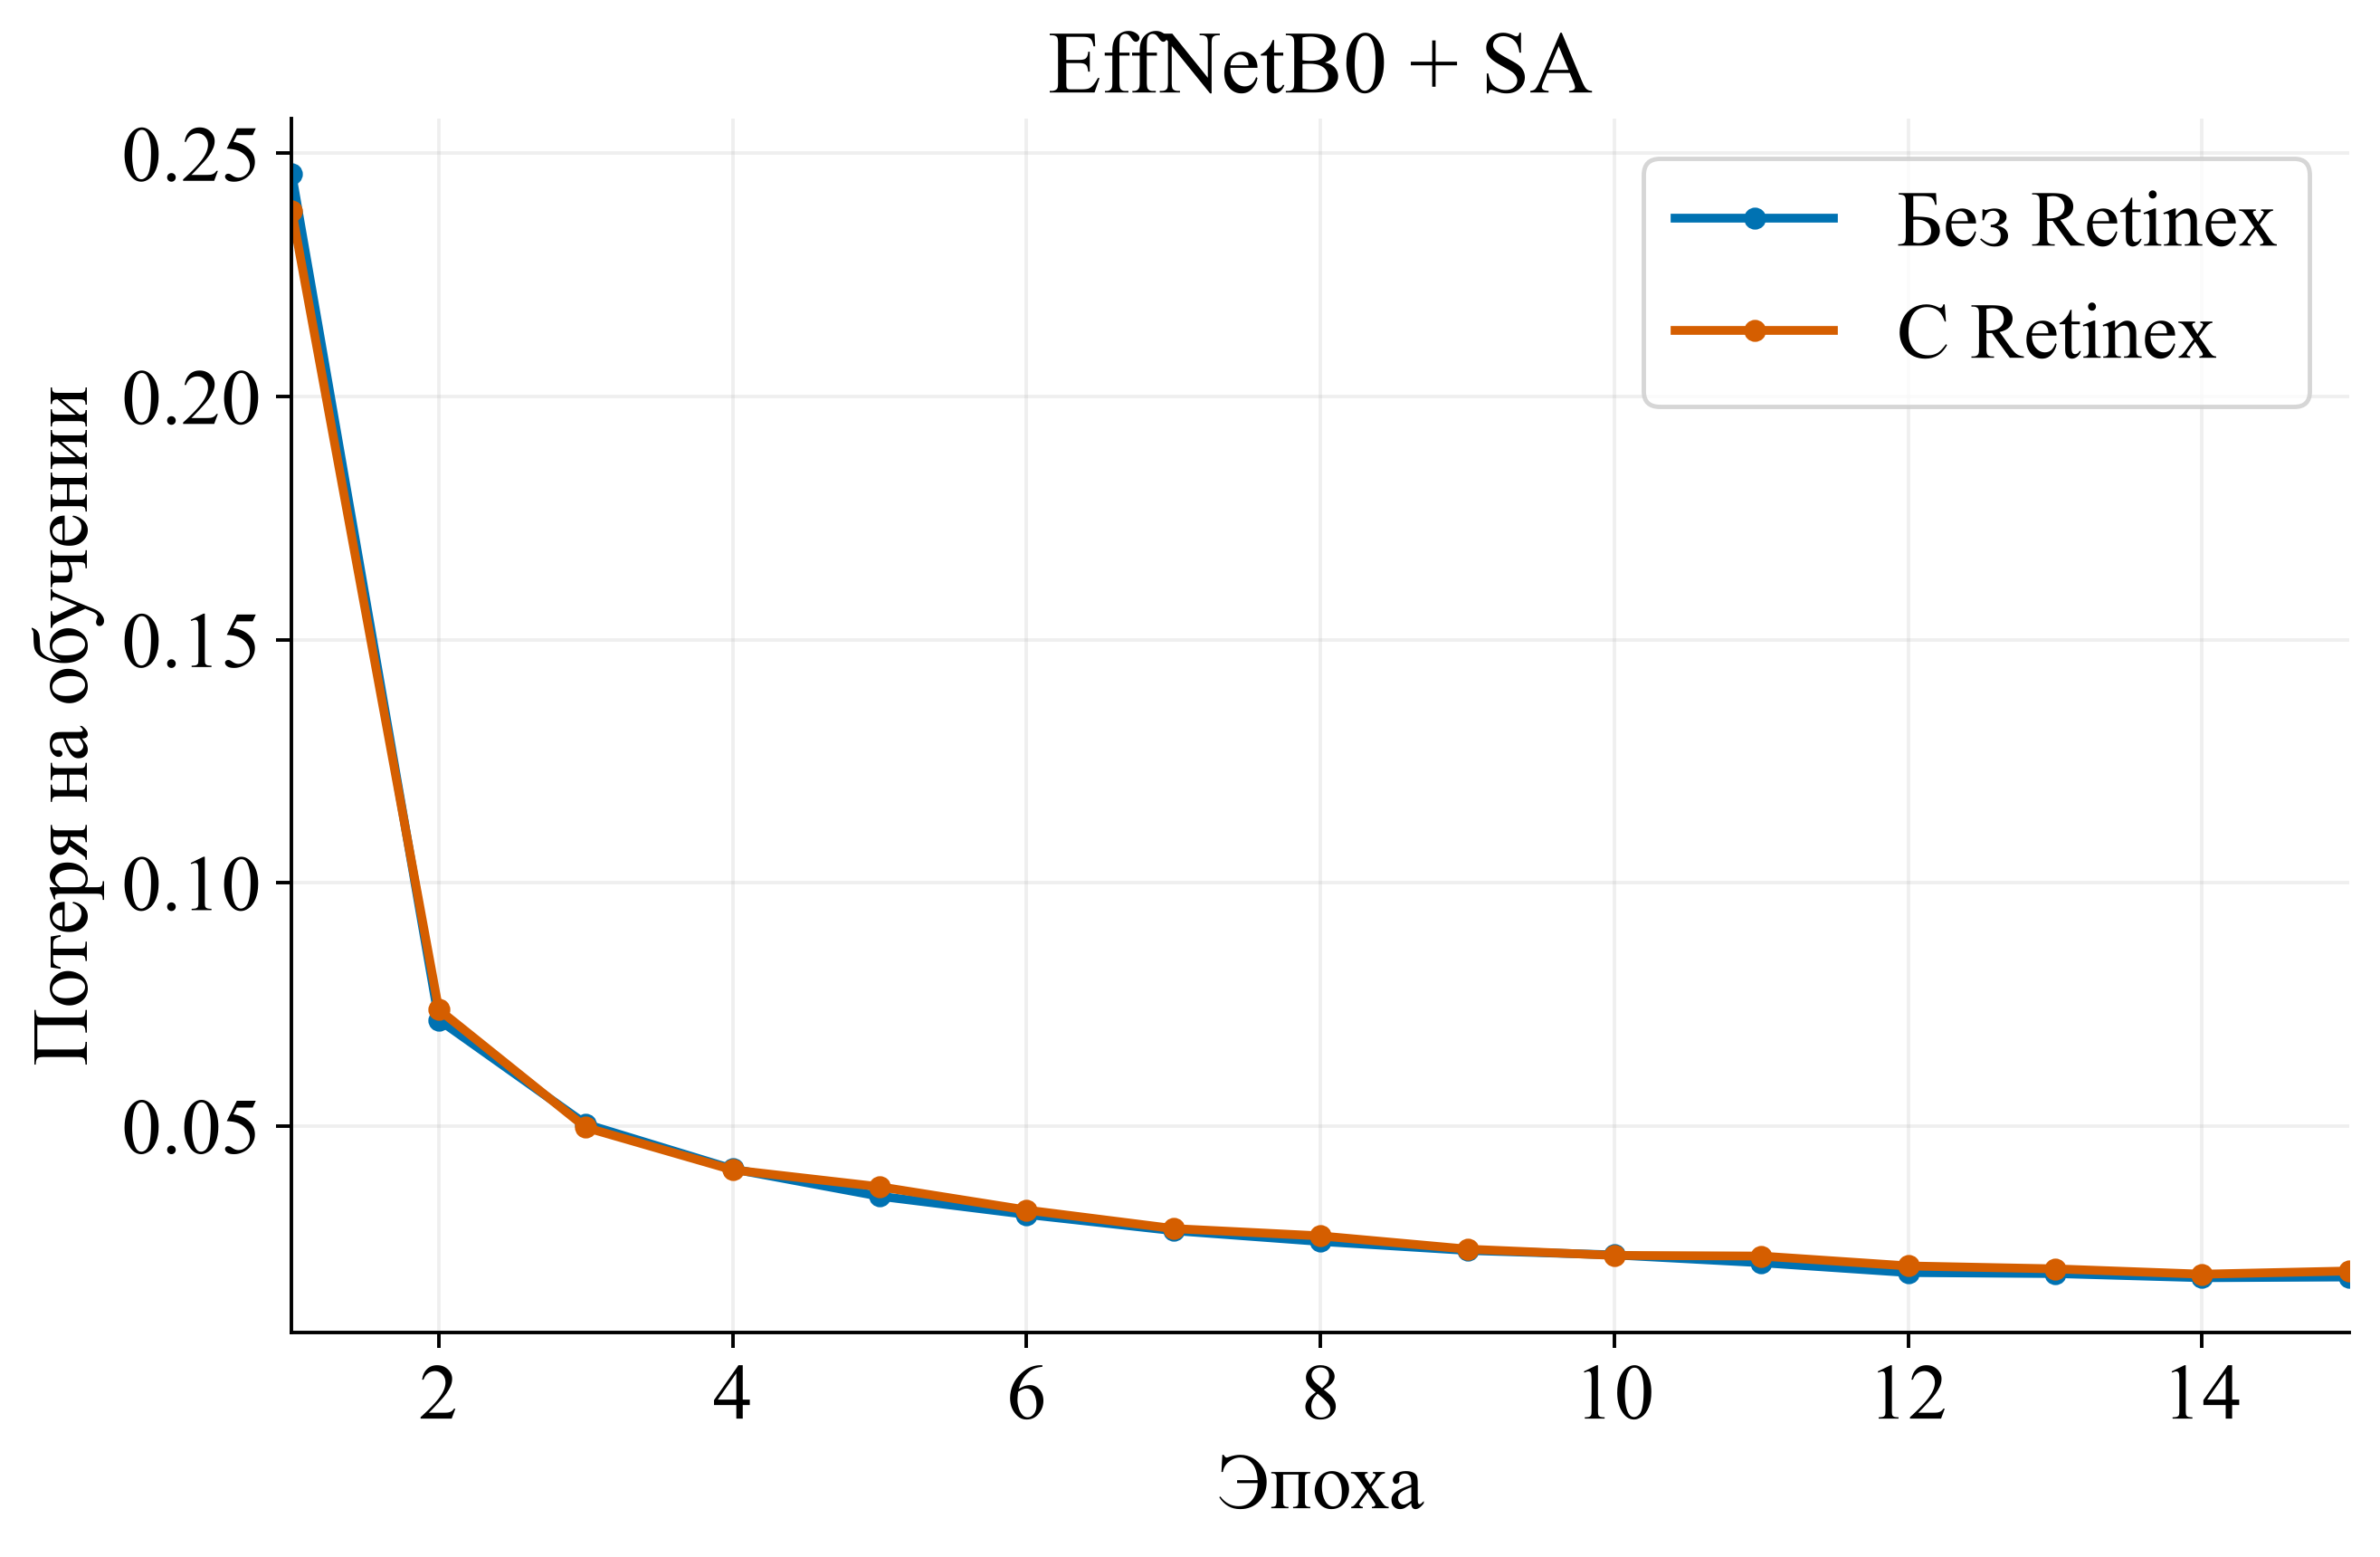

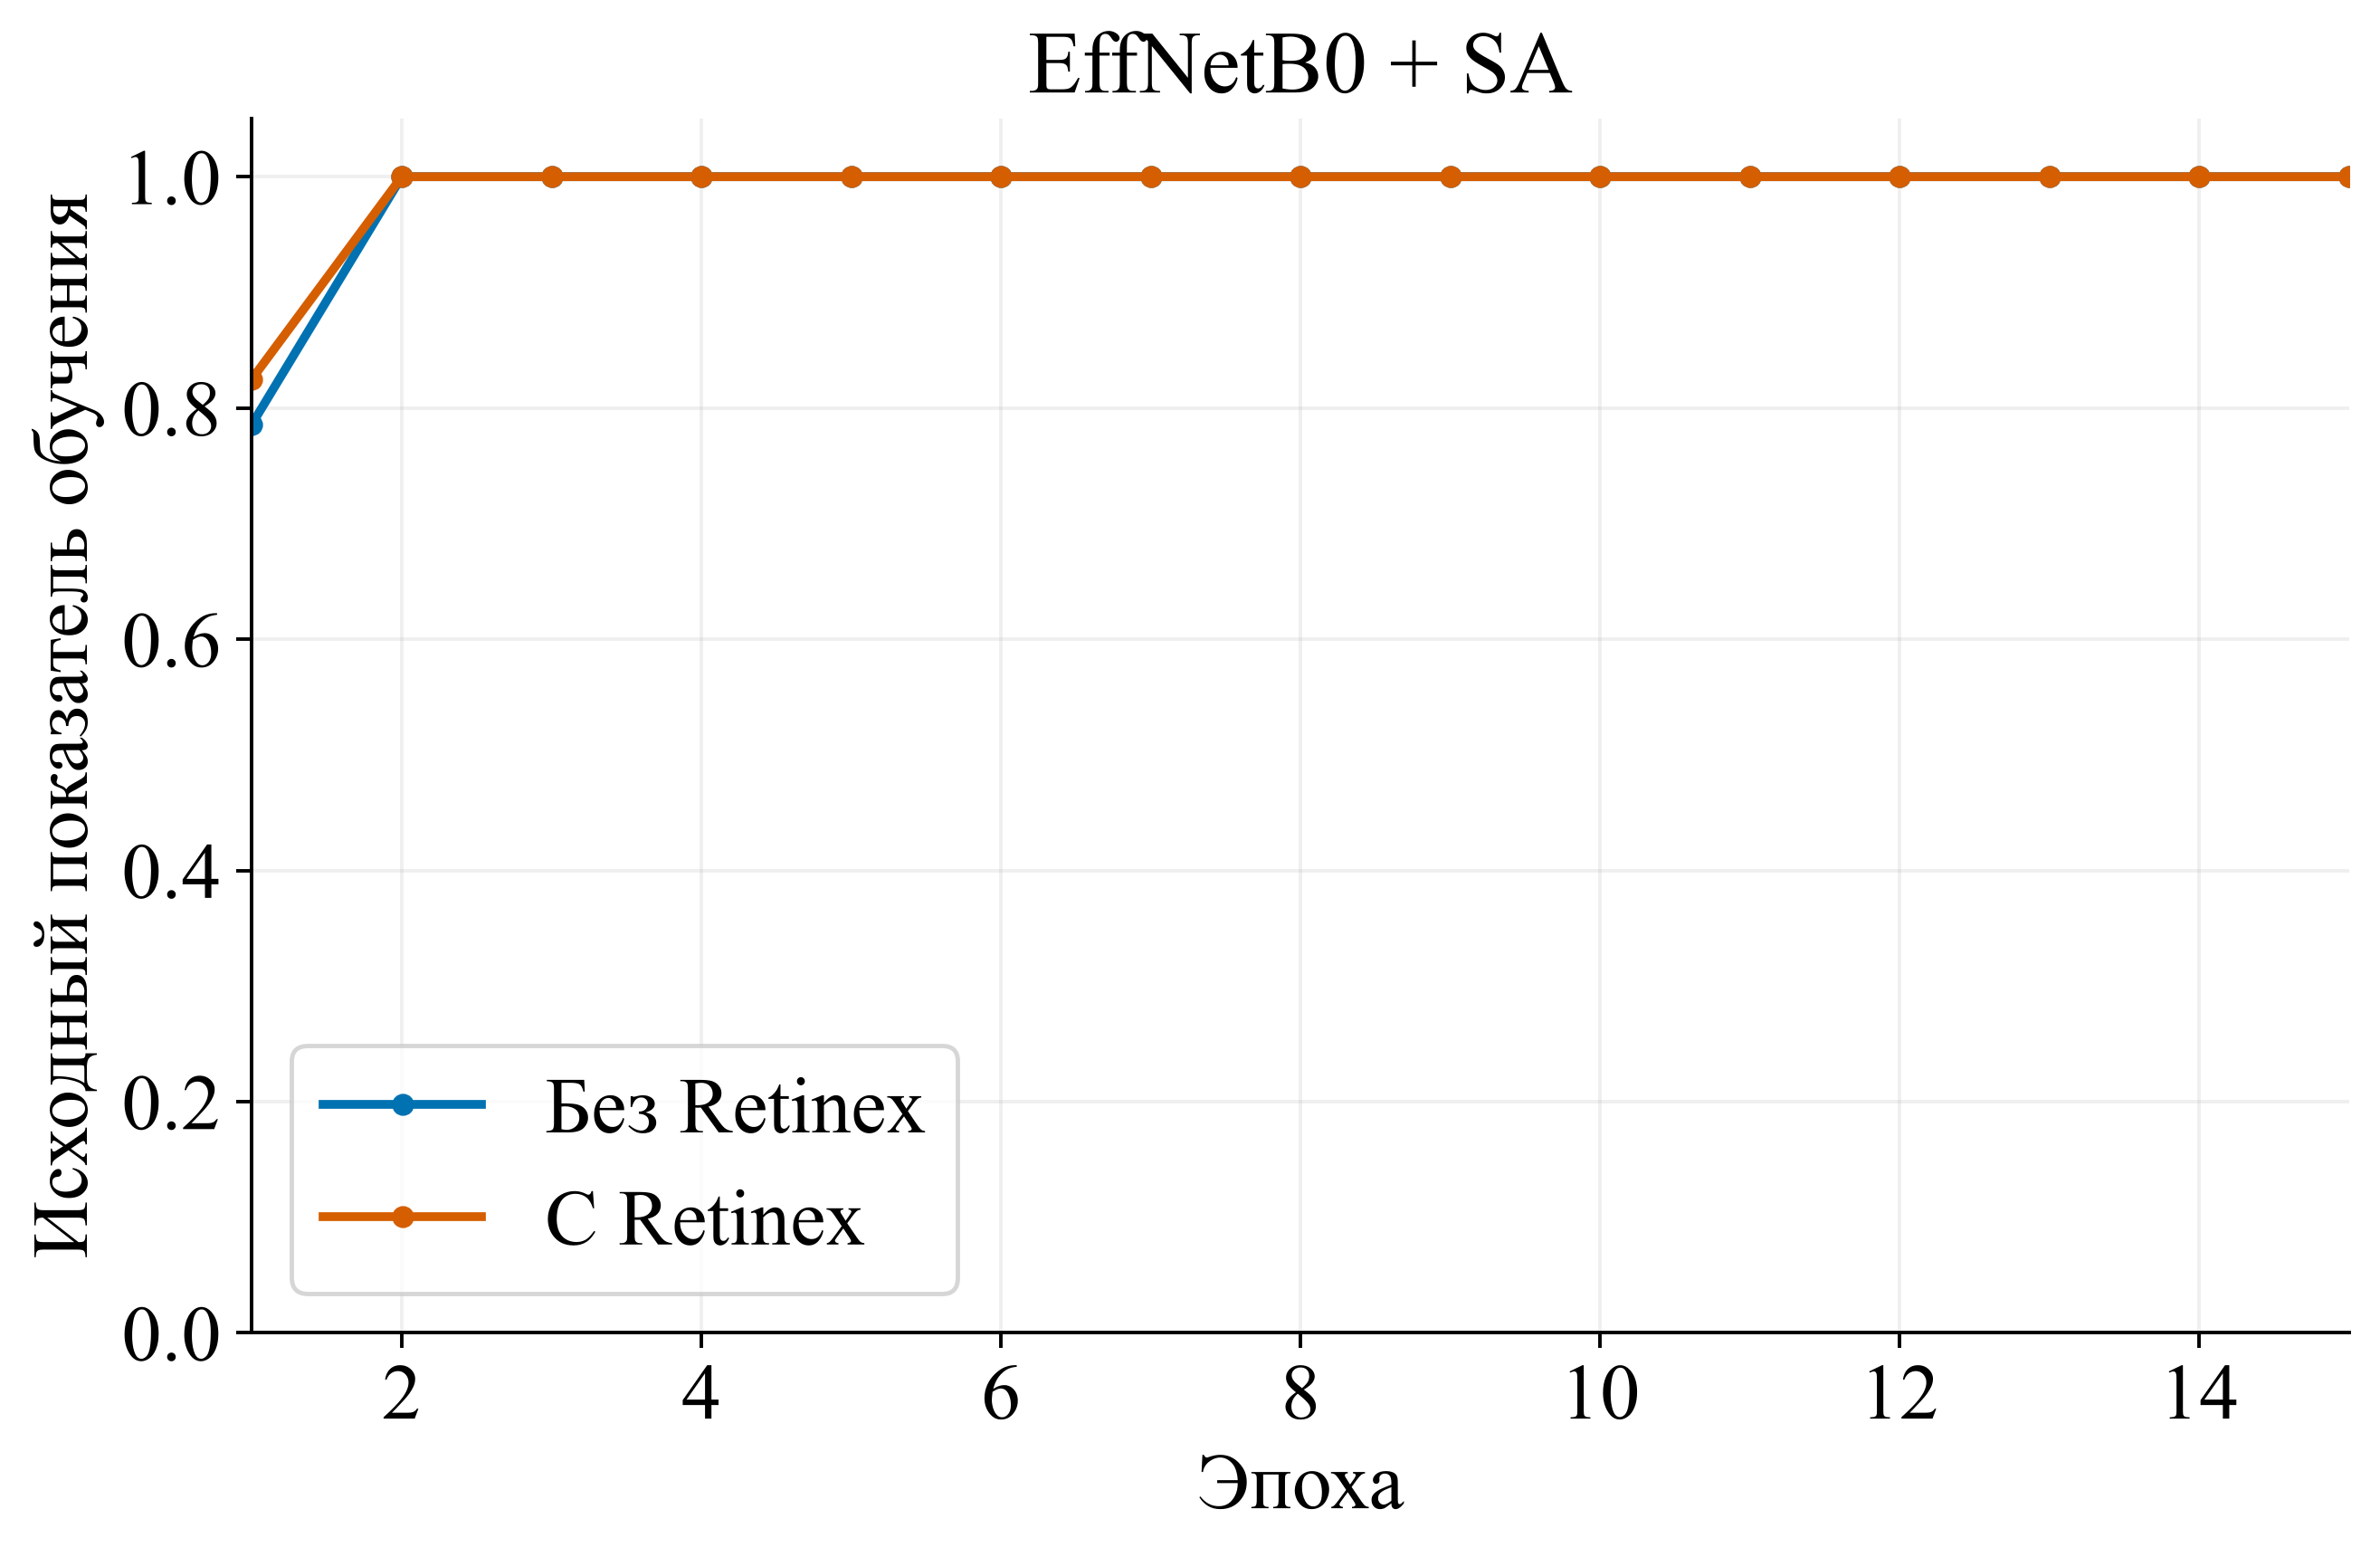

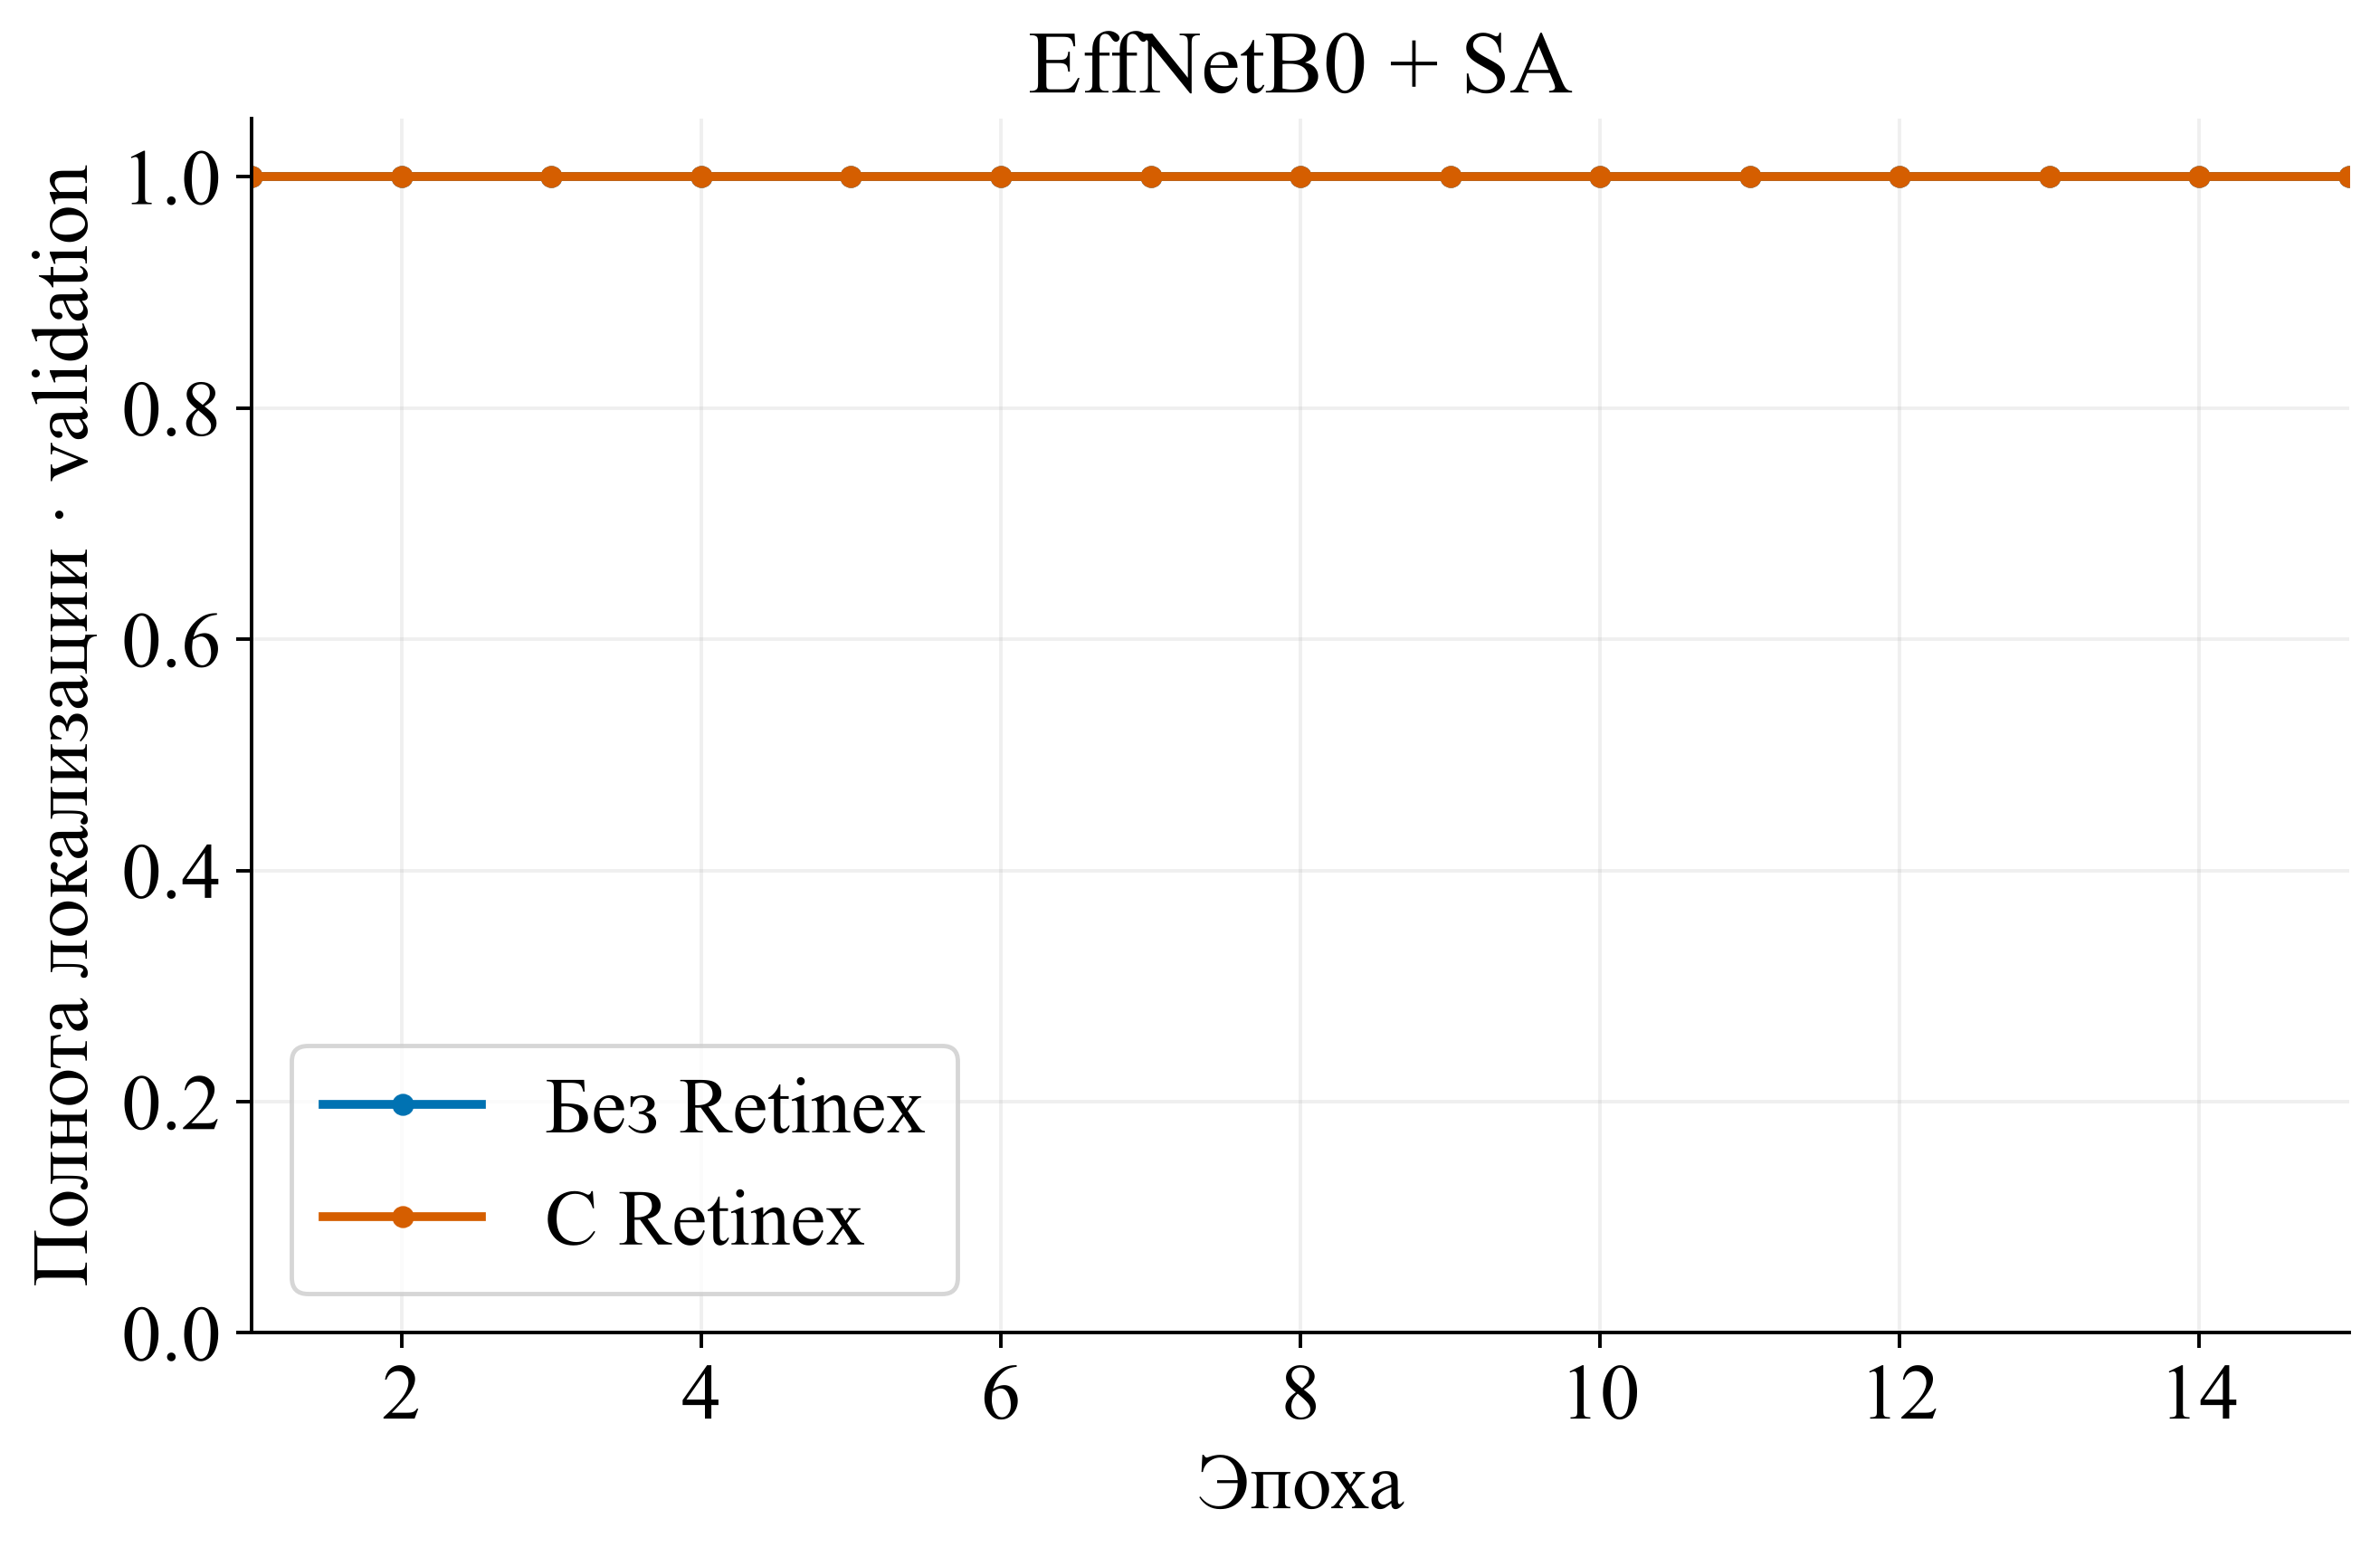

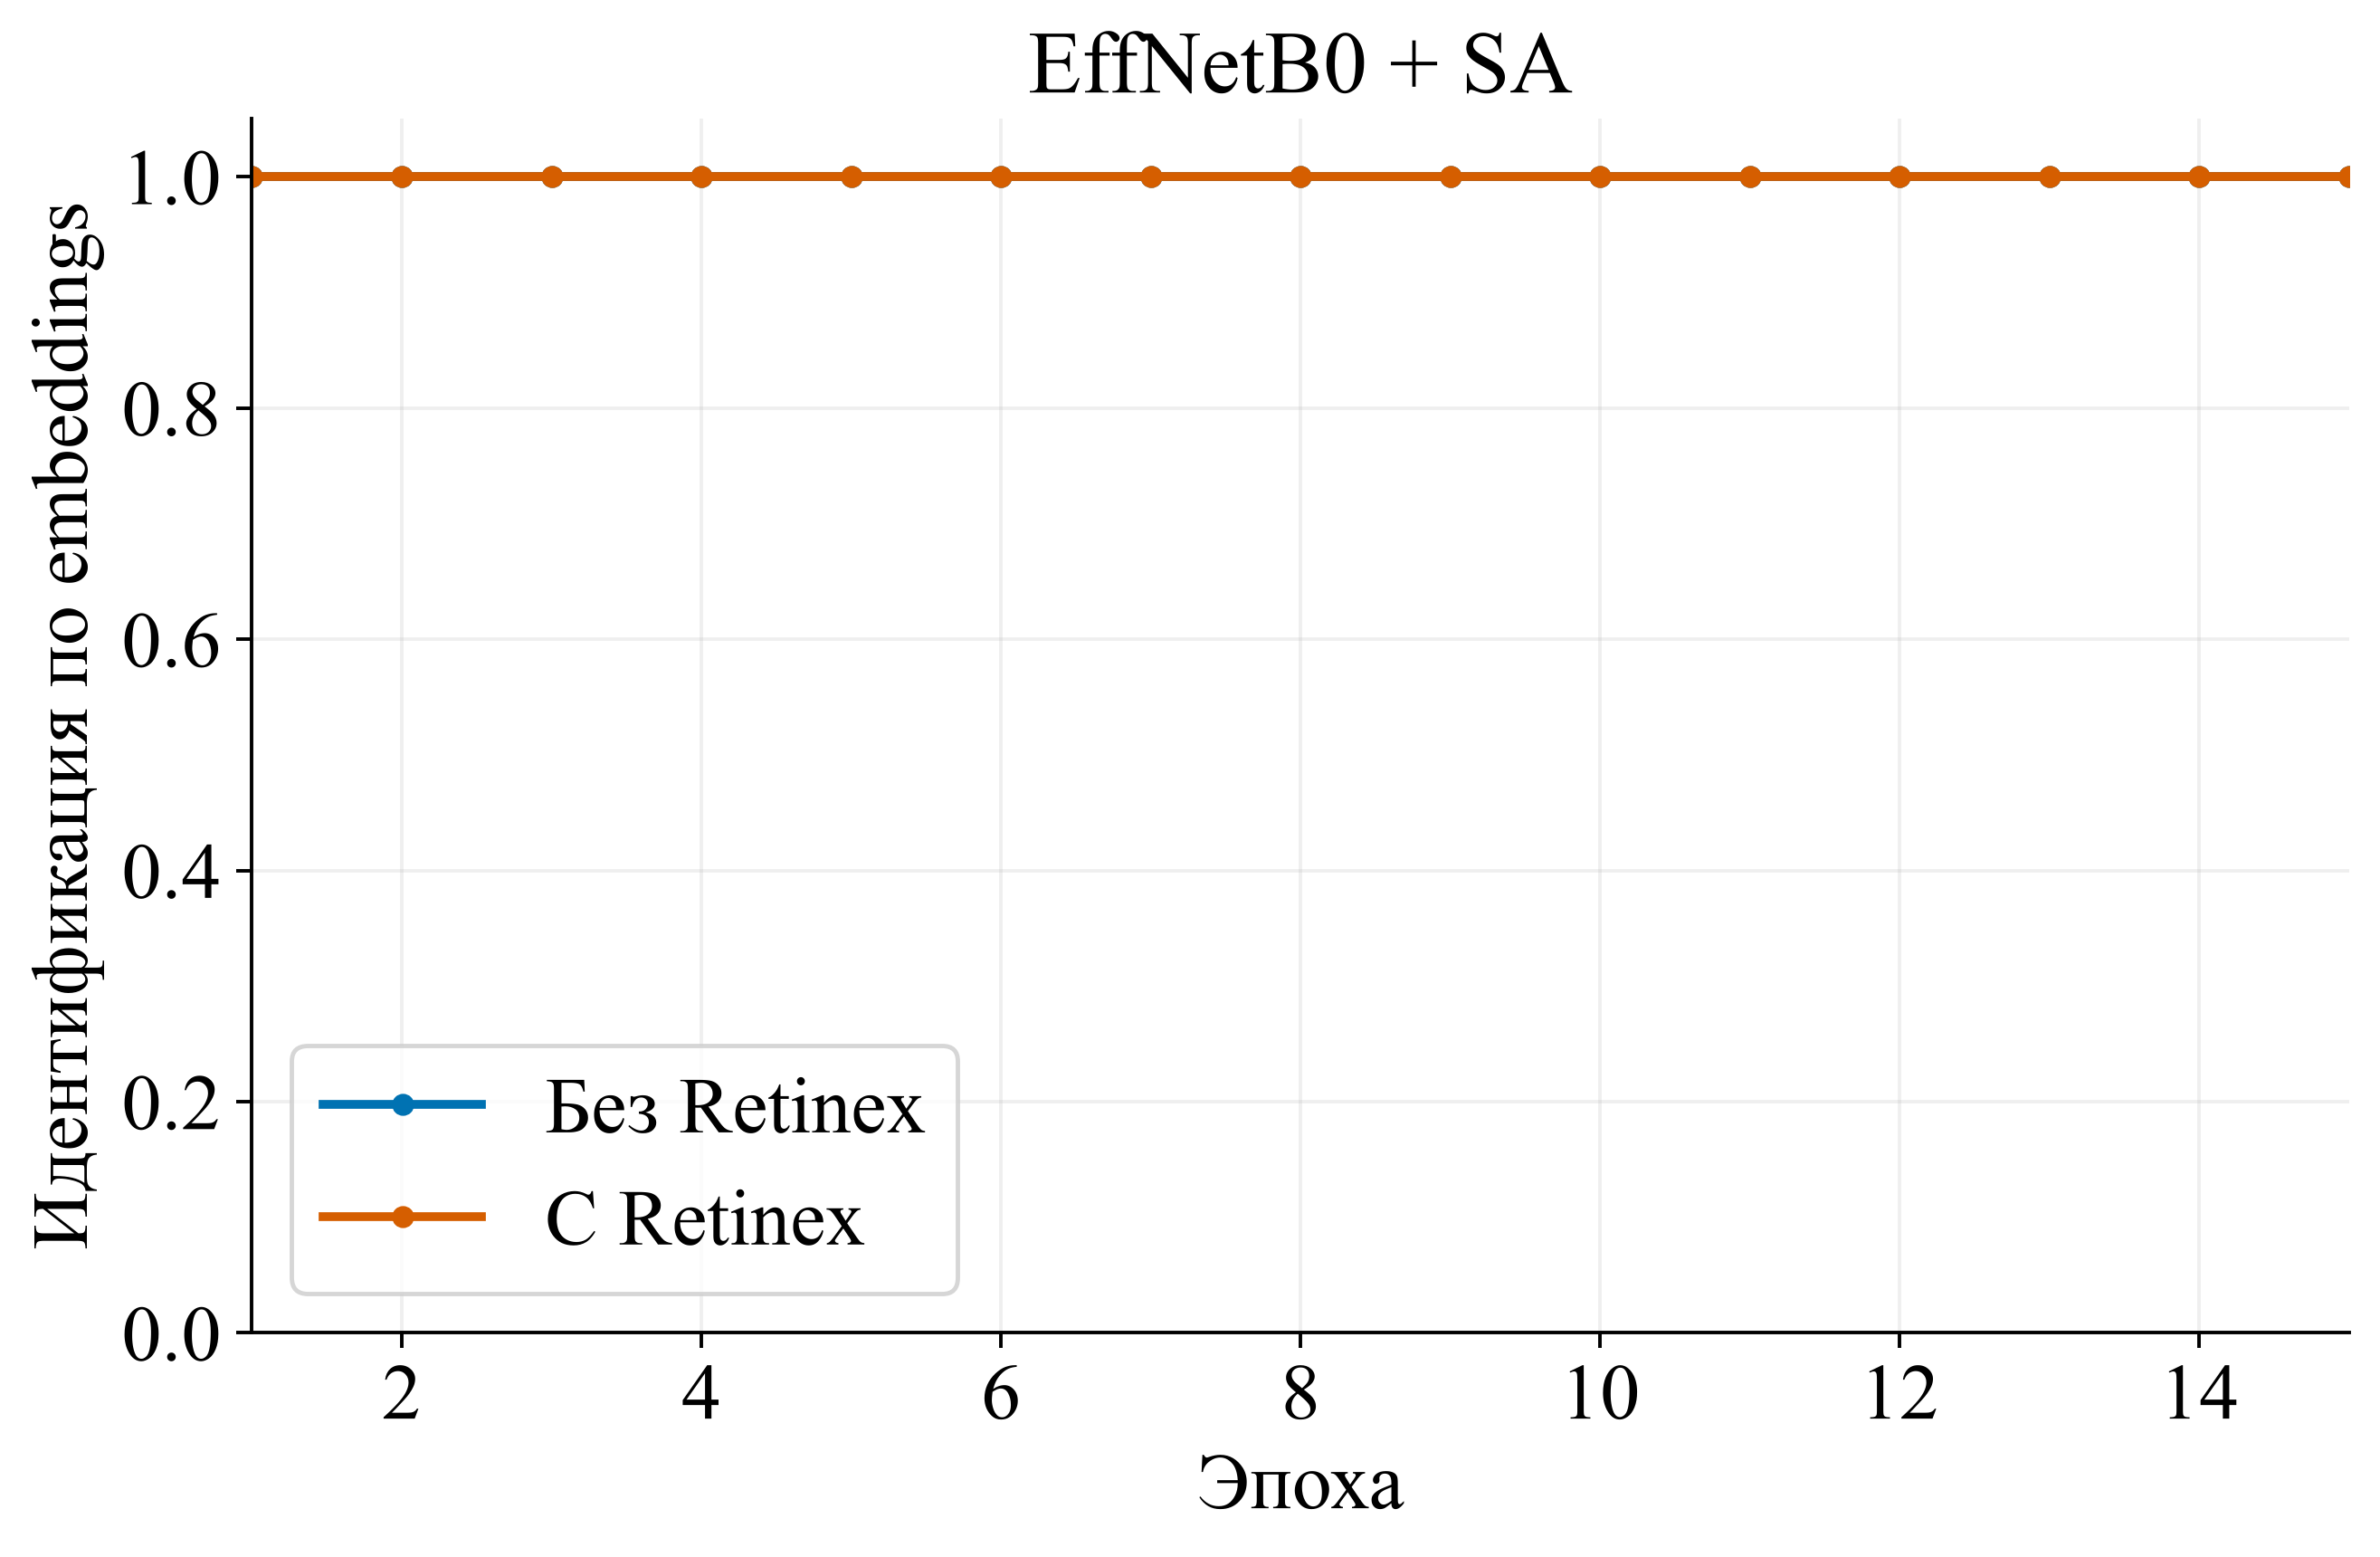

In [18]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
font_path = Path('/mnt/c/Windows/Fonts/times.ttf')
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
assert Path(font_manager.findfont('Times New Roman', fallback_to_default=False)).exists()
matplotlib.rcParams.update({
    'font.family': 'Times New Roman', 'font.size': 18, 'axes.labelsize': 18,
    'axes.titlesize': 20, 'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'legend.fontsize': 18, 'figure.dpi': 350, 'savefig.dpi': 350,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False})
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
colors = {'without_retinex': '#0072B2', 'with_retinex': '#D55E00'}
variant_labels = {'without_retinex': 'Без Retinex', 'with_retinex': 'С Retinex'}
for name in MODEL_NAMES:
    for metric, ylabel in [('train_loss', 'Потеря на обучении'),
                            ('train_accuracy', 'Исходный показатель обучения'),
                            ('val_recall', 'Полнота локализации · validation'),
                            ('val_embedding_rank1', 'Идентификация по embeddings')]:
        fig, ax = plt.subplots(figsize=(7.4, 4.8), layout='constrained')
        for variant in VARIANTS:
            history = pd.DataFrame(histories[(name, variant)])
            assert history.epoch.tolist() == list(range(1, 16))
            ax.plot(history.epoch, history[metric], label=variant_labels[variant],
                    color=colors[variant], linewidth=2, marker='o', markersize=4)
        ax.set(title=MODEL_LABELS[name], xlabel='Эпоха', ylabel=ylabel, xlim=(1, 15))
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))
        if metric != 'train_loss':
            ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.2)
        ax.legend()
        plt.show()
        plt.close(fig)


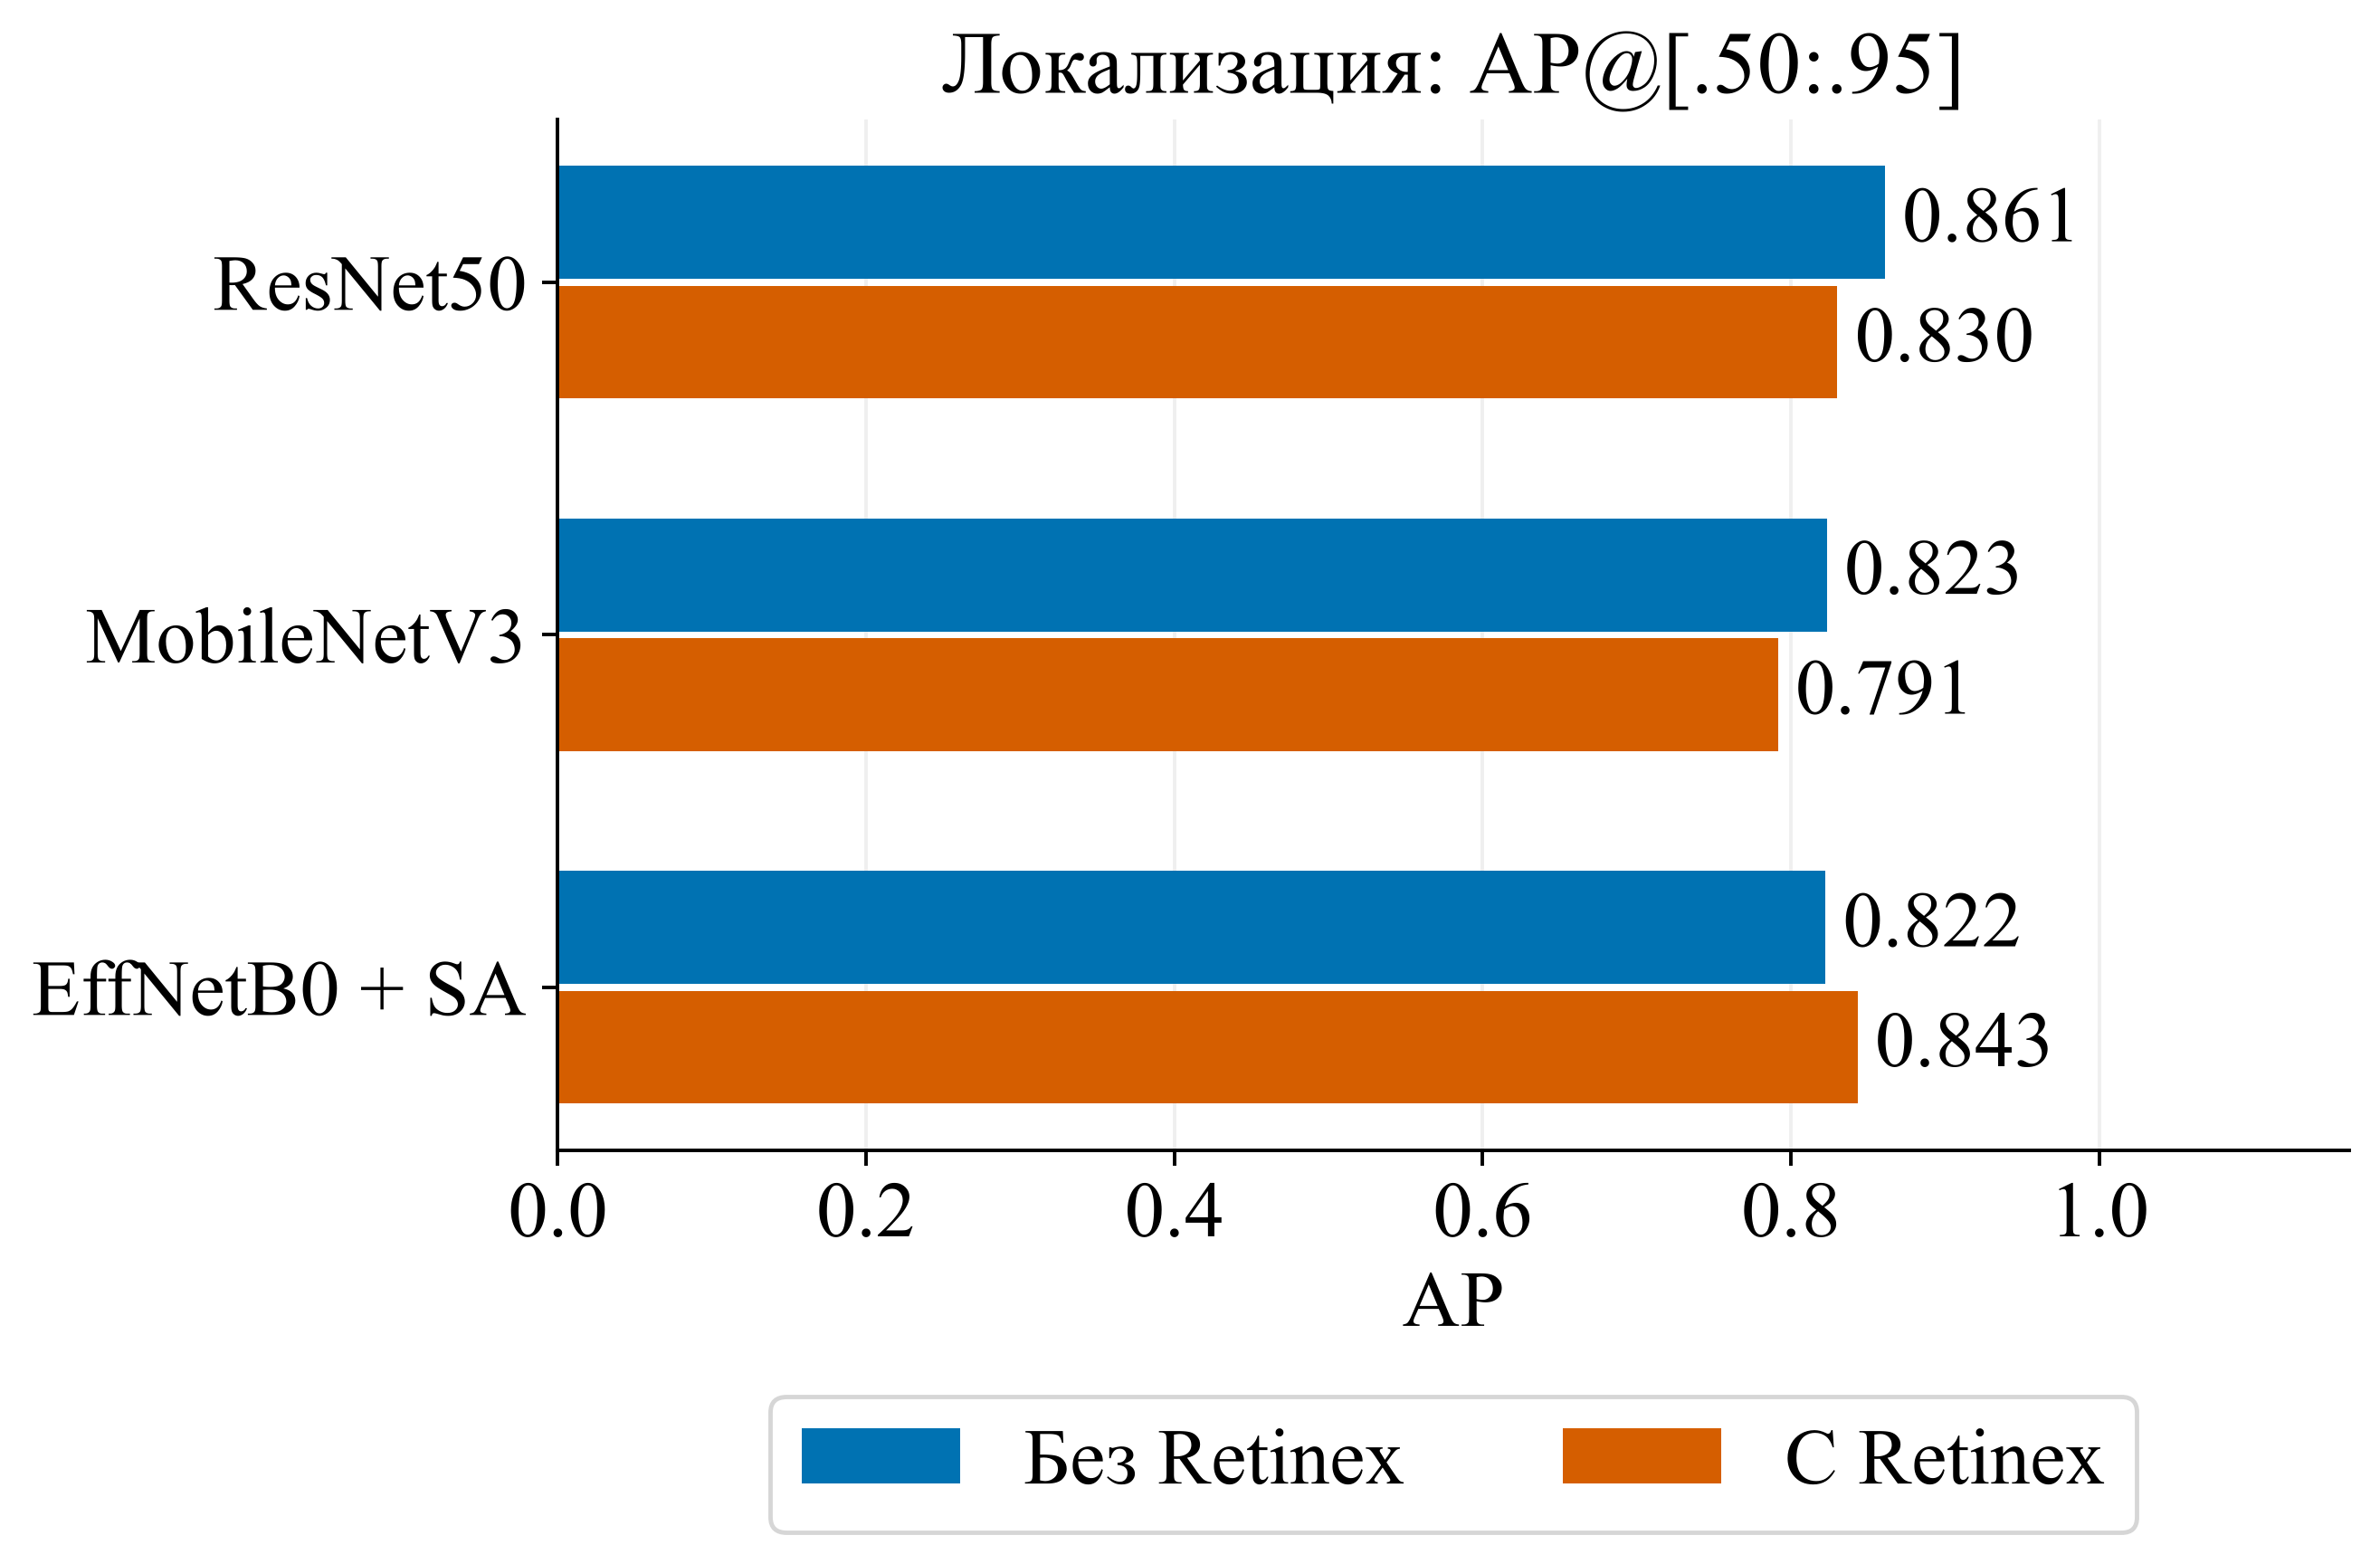

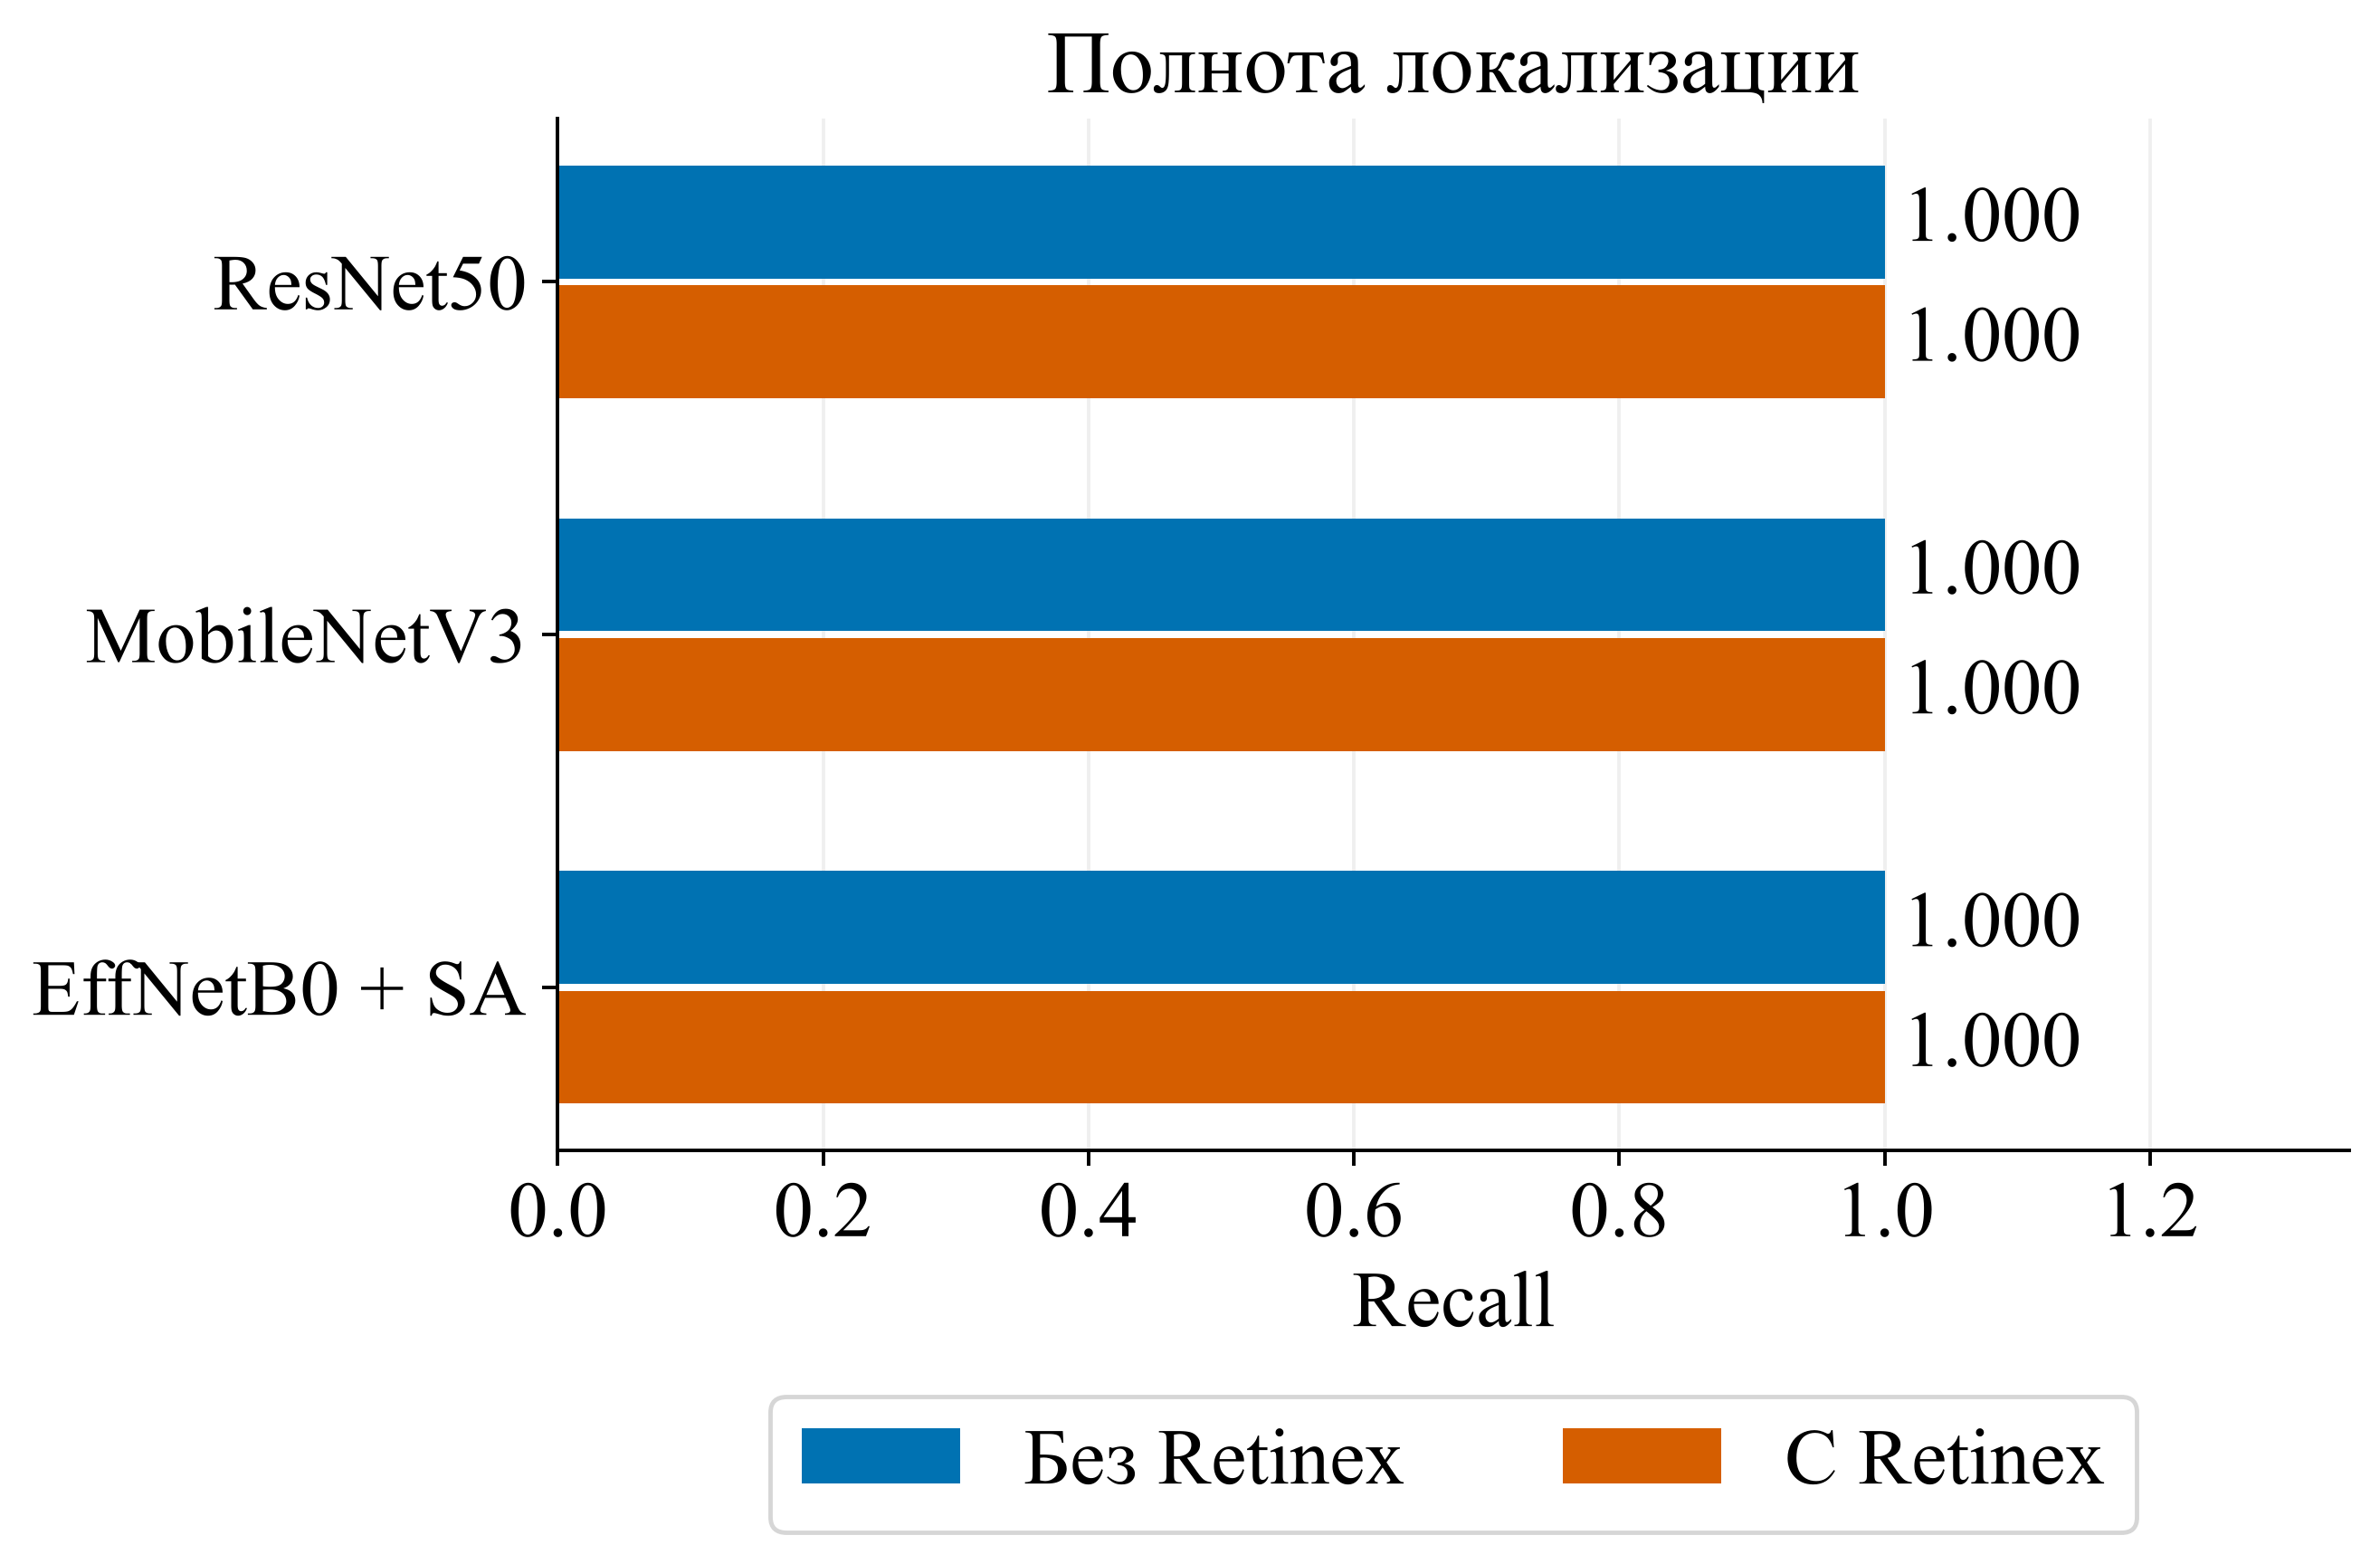

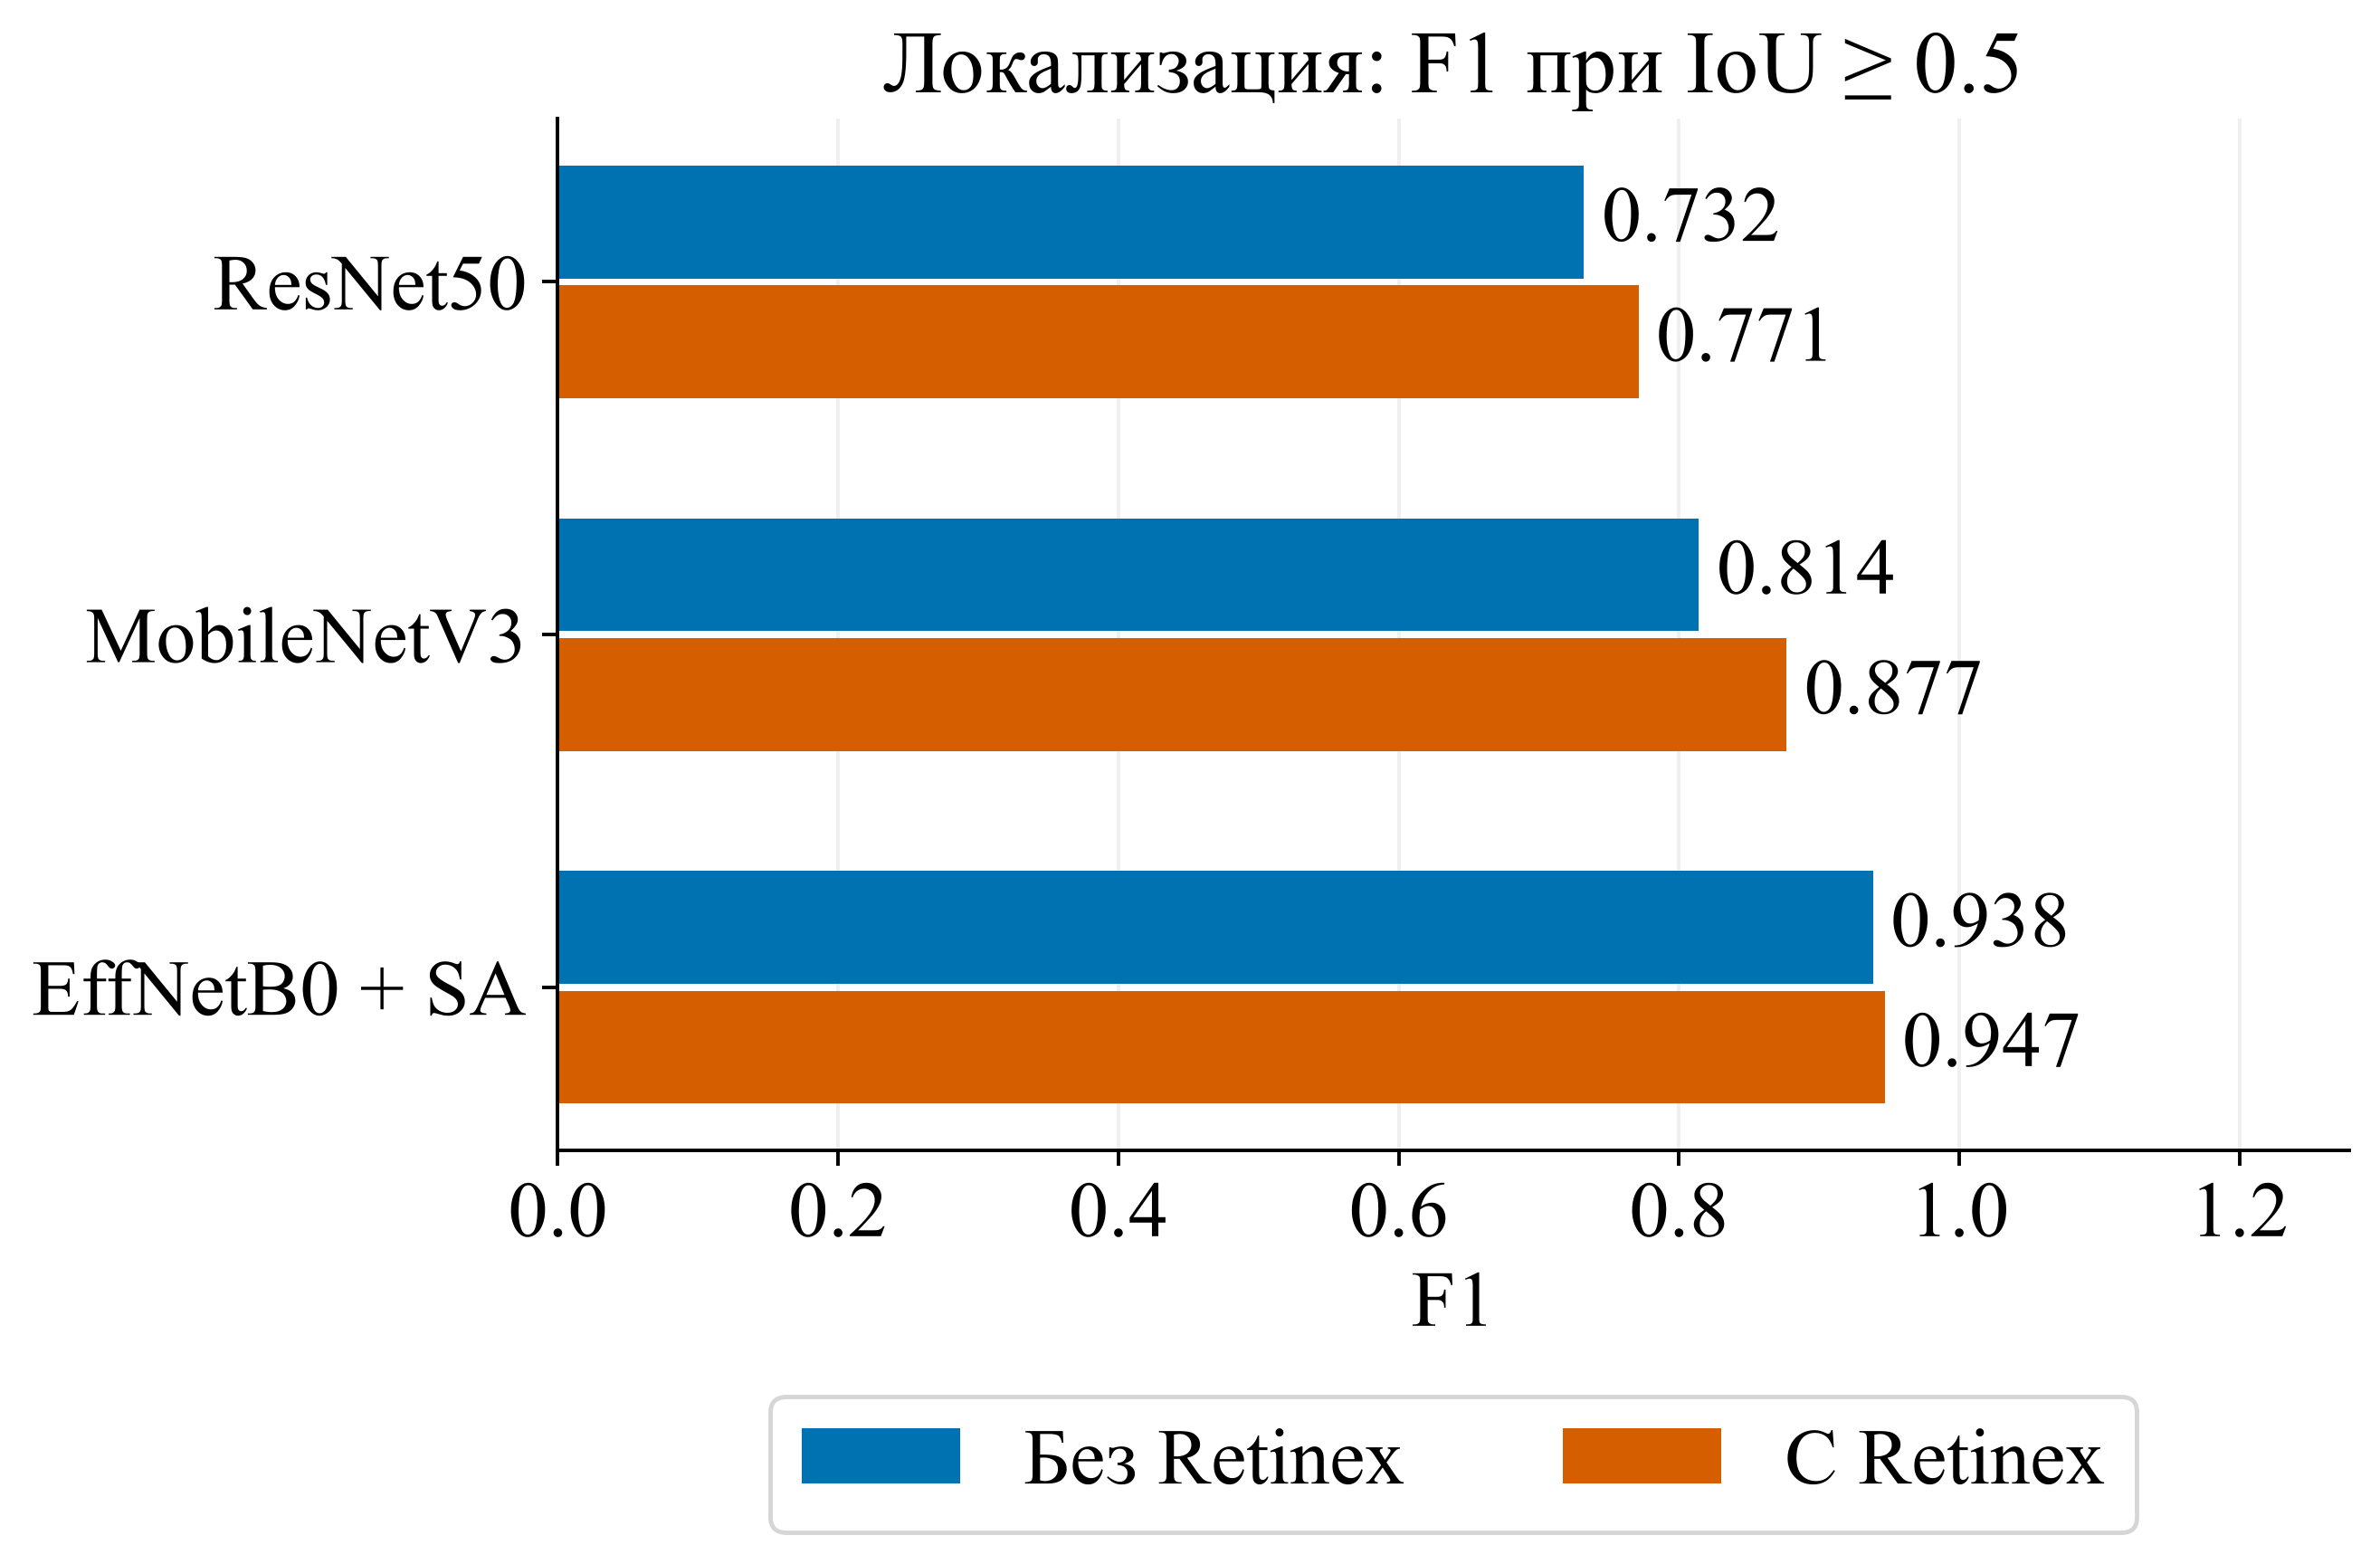

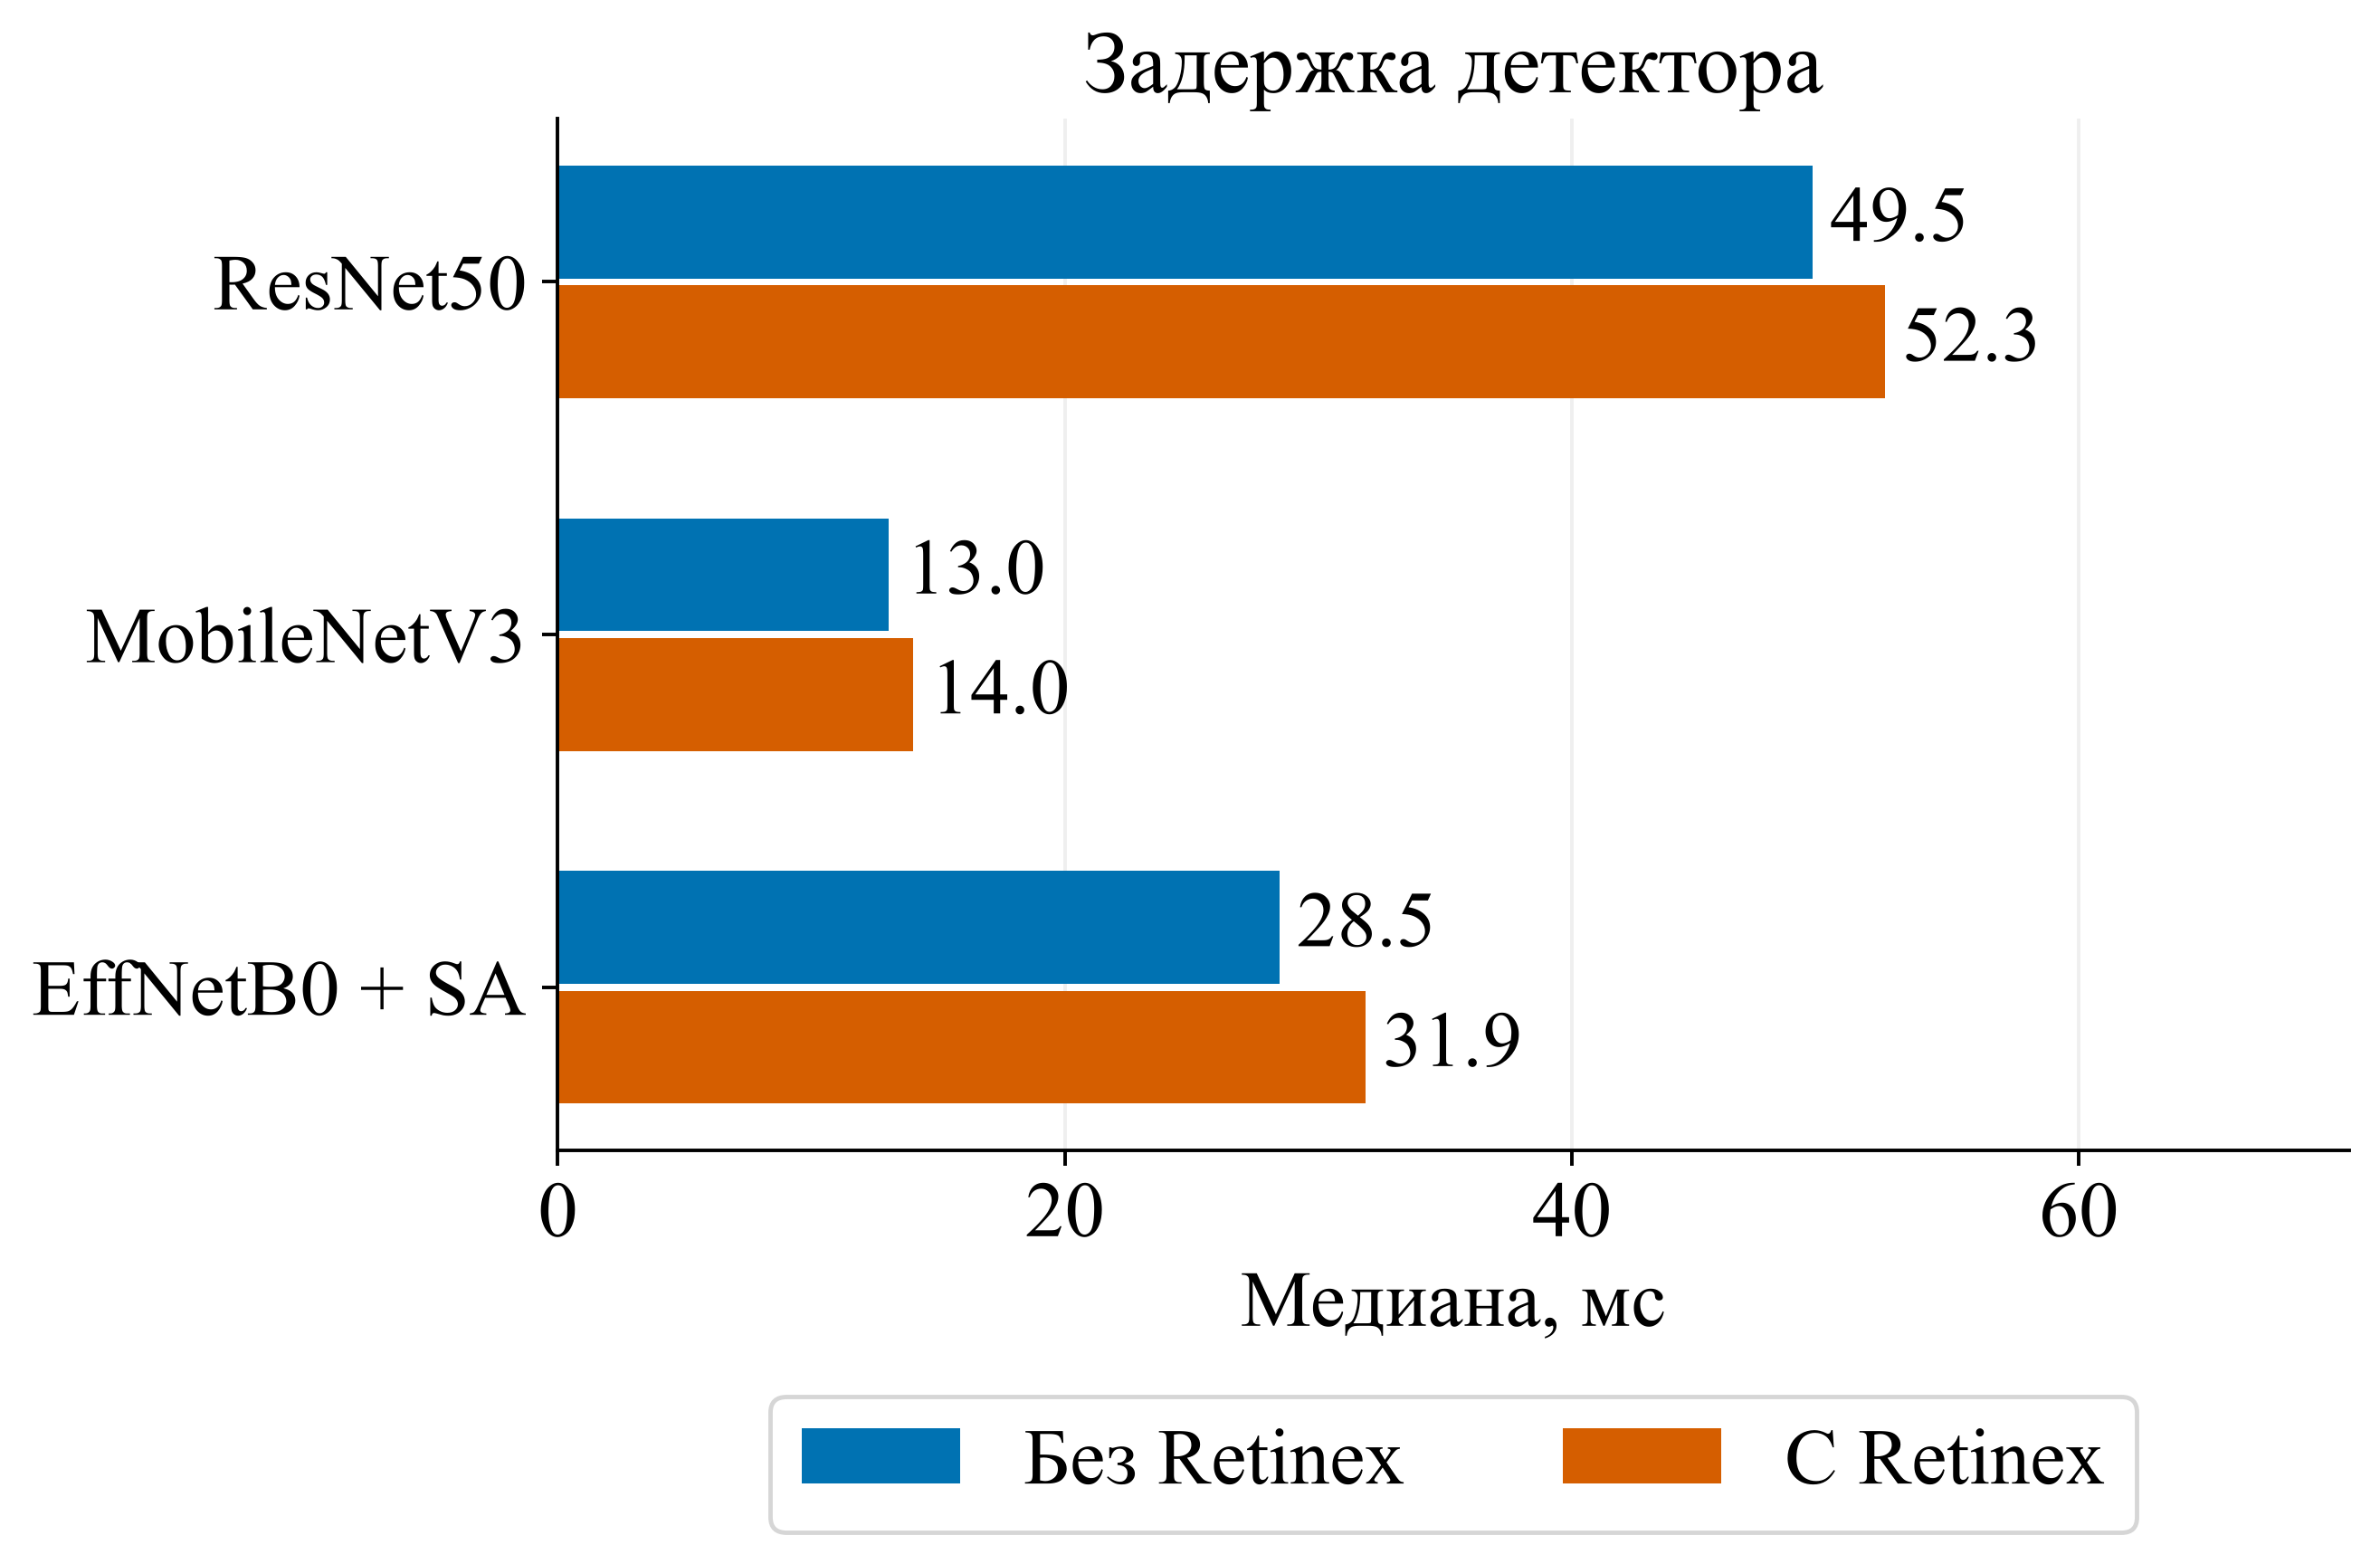

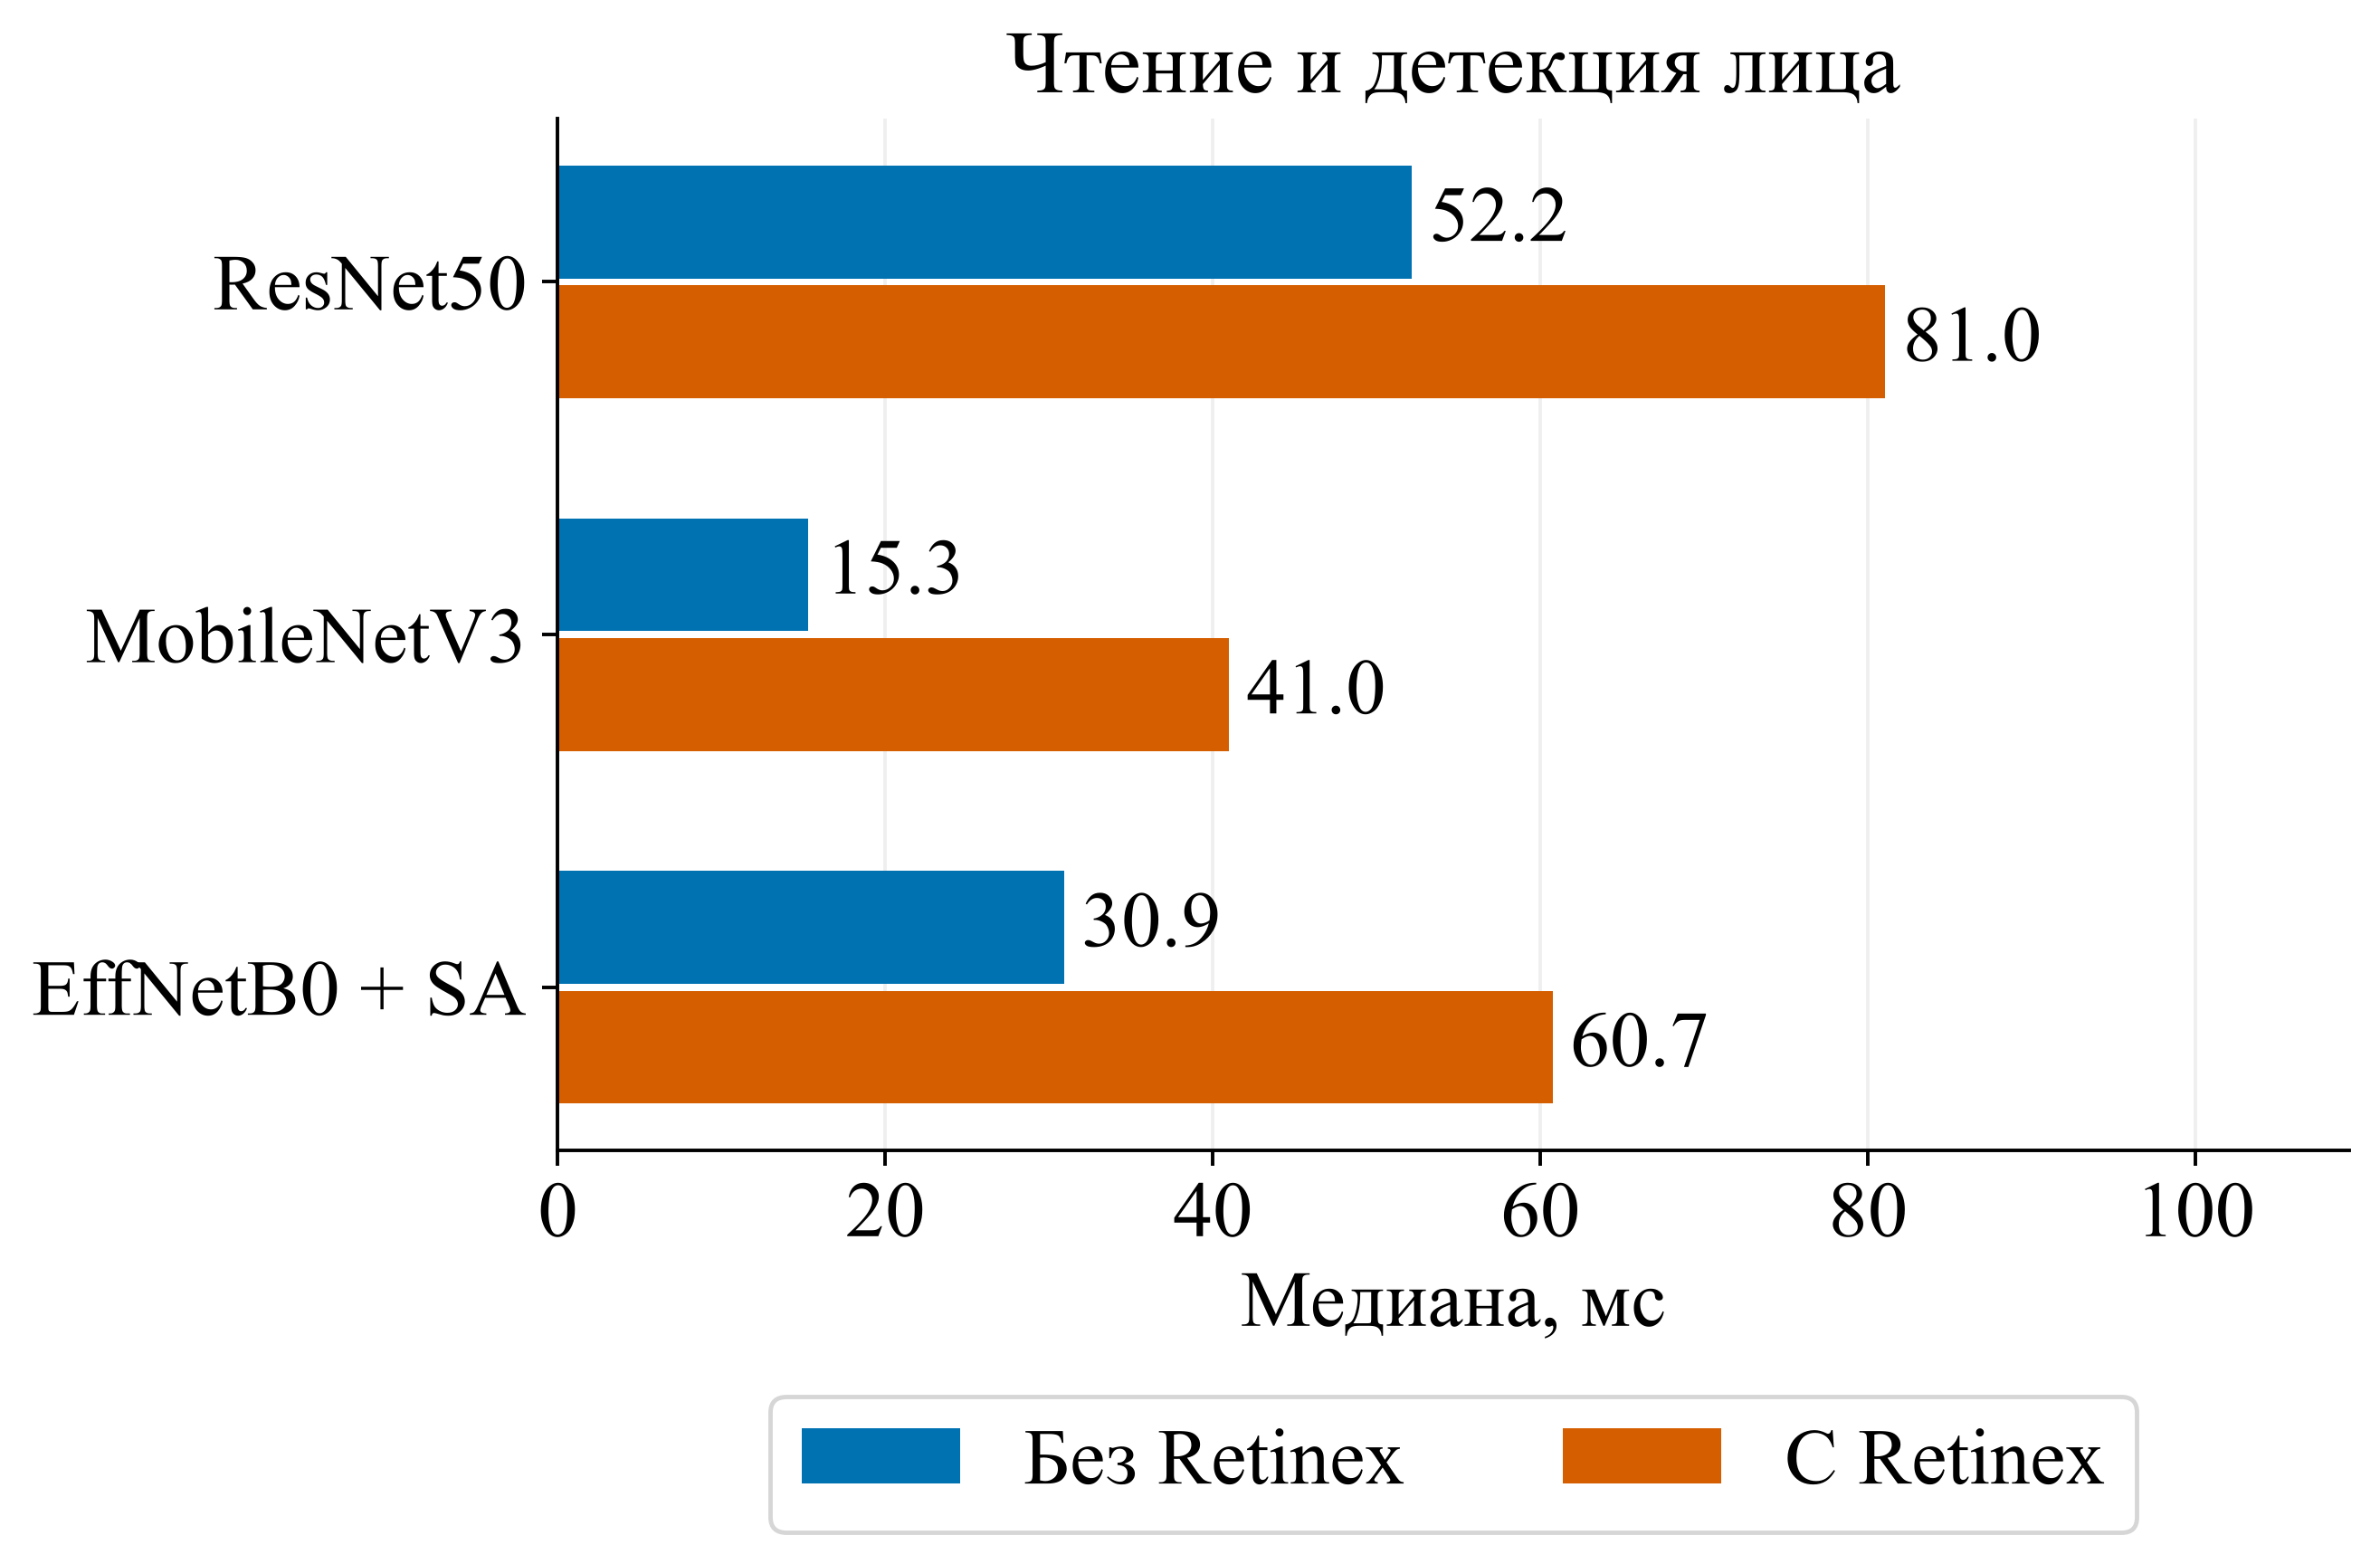

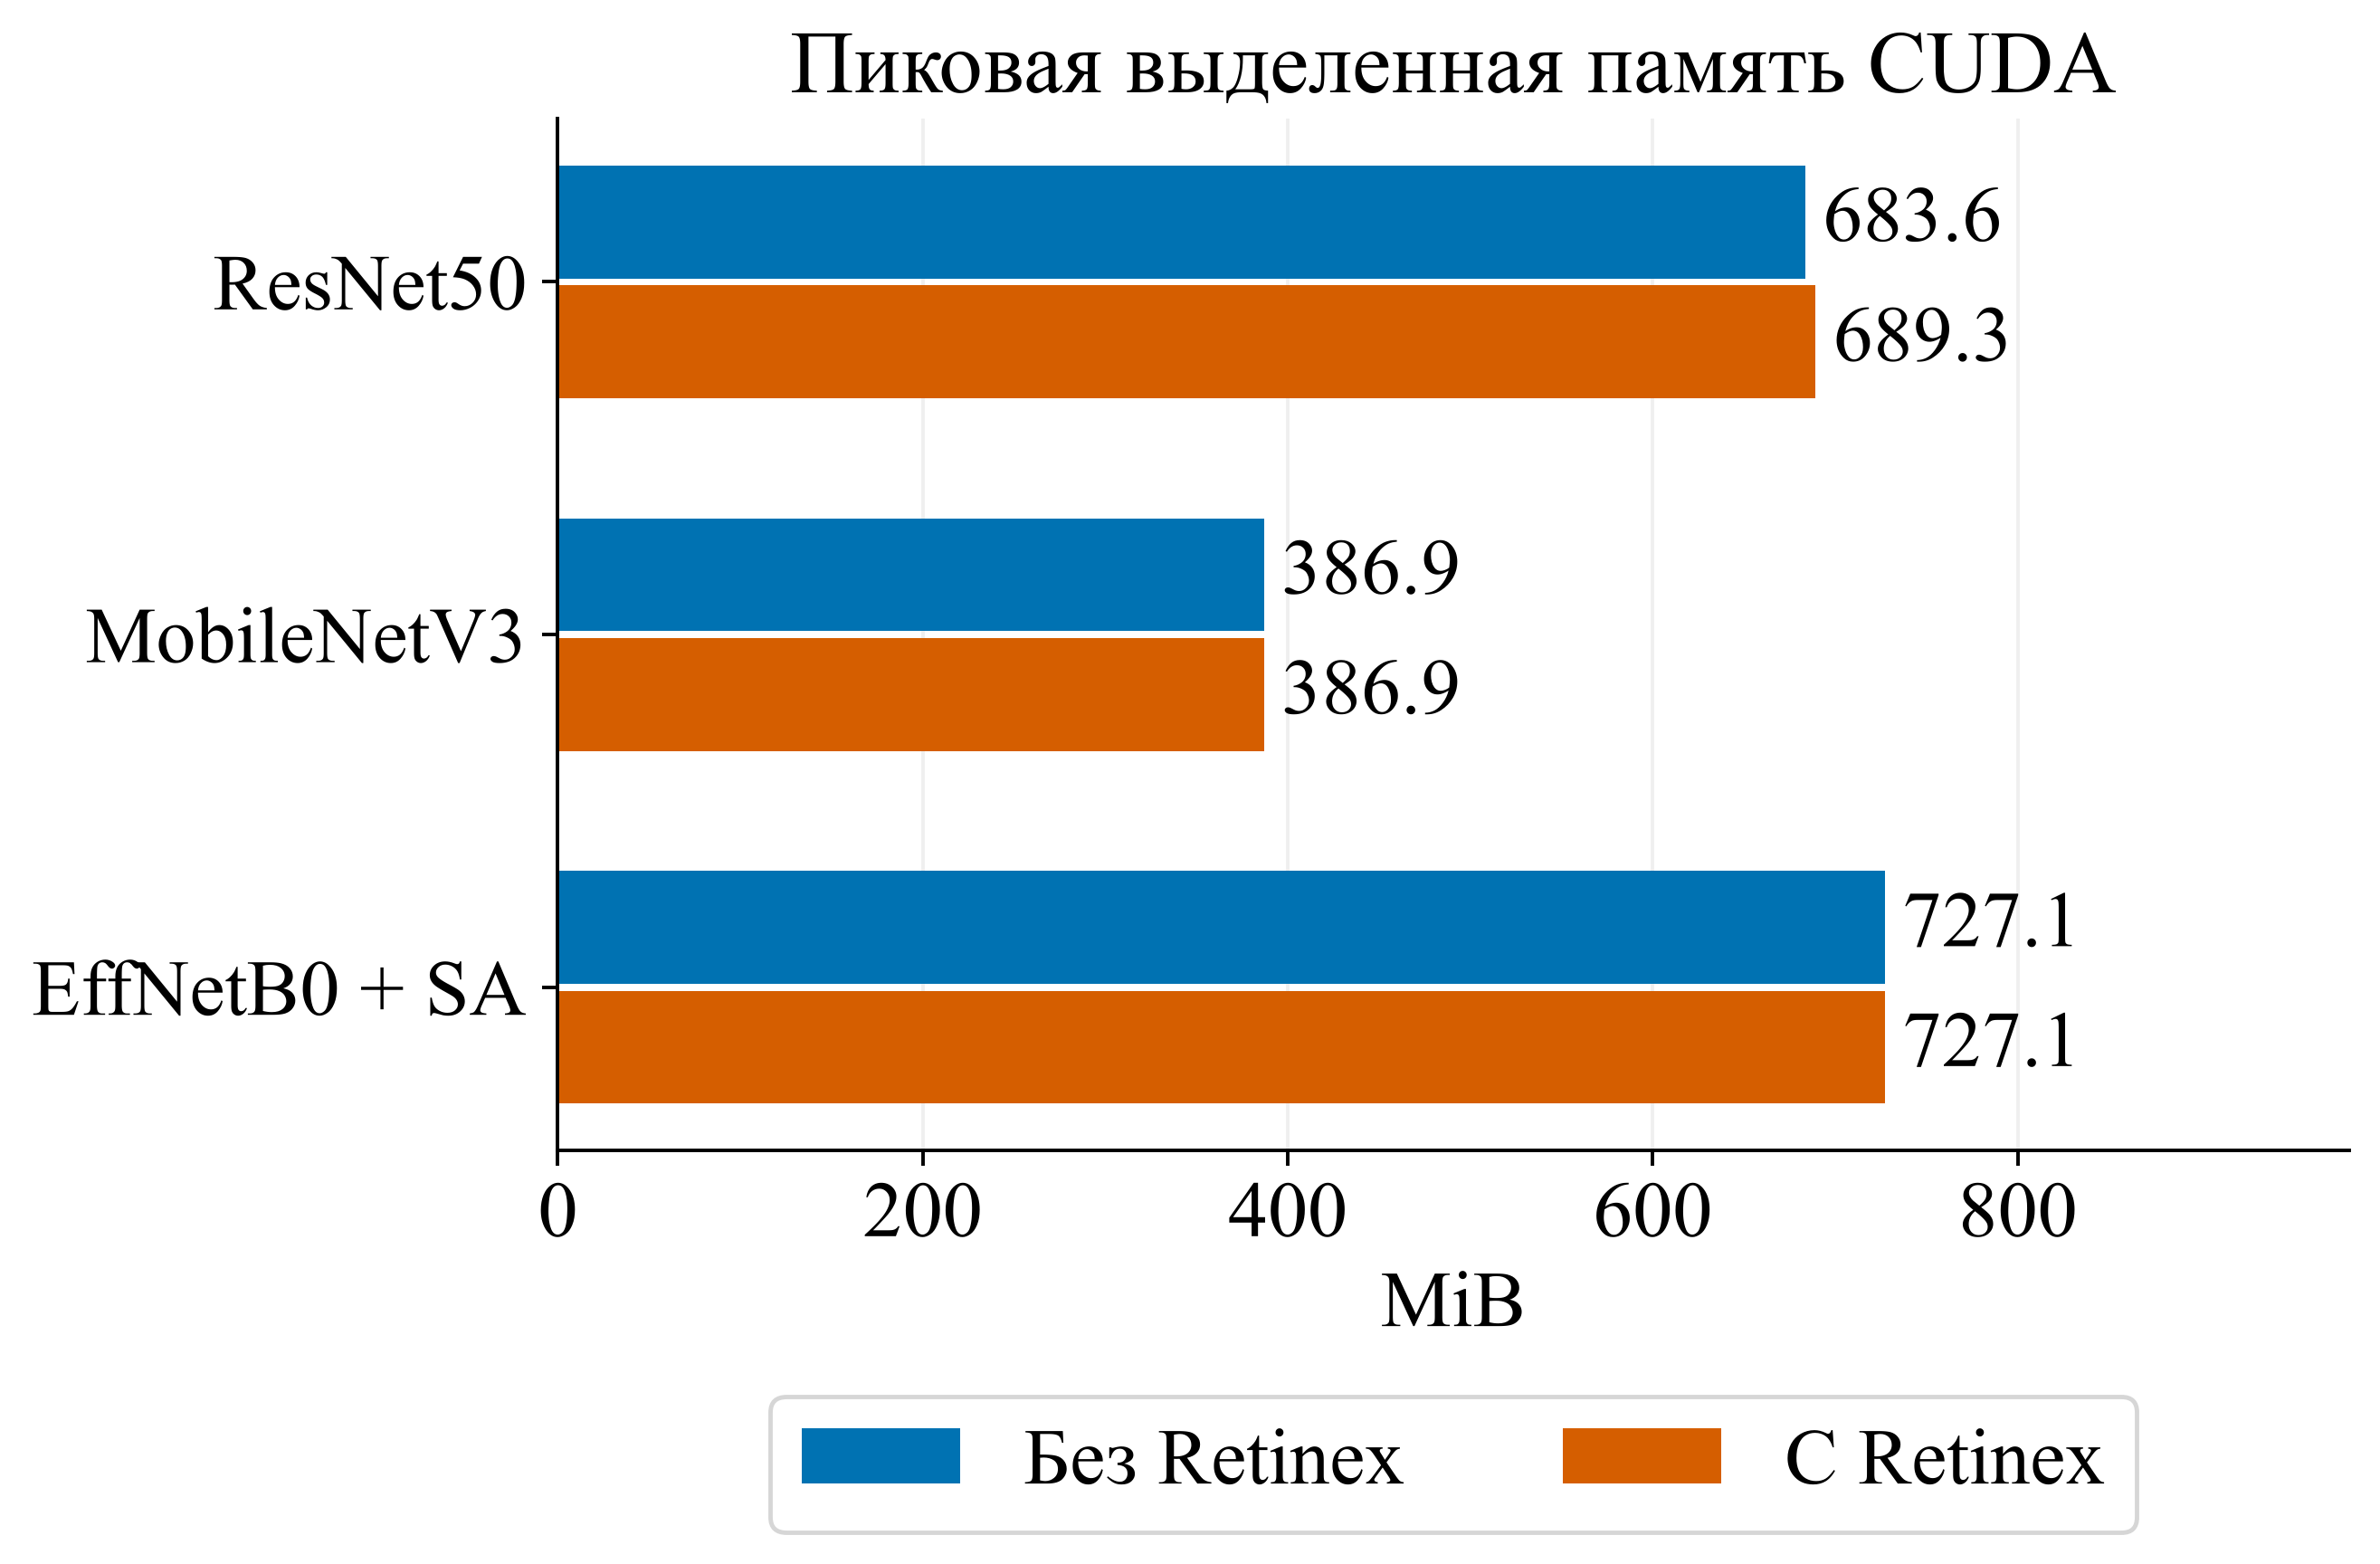

In [19]:
for metric, title, unit in [
    ('ap', 'Локализация: AP@[.50:.95]', 'AP'),
    ('recall', 'Полнота локализации', 'Recall'),
    ('f1', 'Локализация: F1 при IoU ≥ 0.5', 'F1'),
    ('detector_median_ms', 'Задержка детектора', 'Медиана, мс'),
    ('end_to_end_median_ms', 'Чтение и детекция лица', 'Медиана, мс'),
    ('peak_cuda_mib', 'Пиковая выделенная память CUDA', 'MiB')]:
    fig, ax = plt.subplots(figsize=(7.4, 4.8), layout='constrained')
    positions = np.arange(len(MODEL_NAMES))
    max_value = 0.0
    for index, variant in enumerate(VARIANTS):
        values = [float(results_table[(results_table.model == name) &
                  (results_table.variant == variant)].iloc[0][metric]) for name in MODEL_NAMES]
        bars = ax.barh(positions + (index - 0.5) * 0.34, values, height=0.32,
                       color=colors[variant], label=variant_labels[variant])
        ax.bar_label(bars, fmt='%.3f' if metric in ['ap', 'recall', 'f1'] else '%.1f',
                     padding=4, fontsize=18)
        max_value = max(max_value, max(values))
    ax.set_yticks(positions, [MODEL_LABELS[name] for name in MODEL_NAMES])
    ax.set(title=title, xlabel=unit, xlim=(0, max(0.1, max_value) * 1.35))
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.2)
    ax.set_axisbelow(True)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncols=2)
    plt.show()
    plt.close(fig)


In [20]:
def scientific_table(frame, title, precision=3):
    display(frame.style.format(precision=precision, na_rep='—')
        .set_caption(title)
        .set_properties(**{'font-family': 'Times New Roman', 'font-size': '18pt'})
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-family', 'Times New Roman'), ('font-size', '20pt')]},
            {'selector': 'th', 'props': [('font-family', 'Times New Roman'), ('font-size', '18pt')]}]))

for name in MODEL_NAMES:
    pair = results_table[results_table.model == name].set_index('variant')
    quality = pair[['ap', 'ap50', 'precision', 'recall', 'f1', 'identity_rate']].T
    quality.columns = [variant_labels[column] for column in quality.columns]
    quality.index = ['AP', 'AP50', 'Precision', 'Recall', 'F1', 'Идентификация головой']
    scientific_table(quality, MODEL_LABELS[name] + ' · качество на test')
    resources = pair[['parameters_million', 'training_minutes', 'detector_median_ms',
                      'detector_p95_ms', 'detector_fps', 'end_to_end_median_ms', 'peak_cuda_mib']].T
    resources.columns = [variant_labels[column] for column in resources.columns]
    resources.index = ['Параметры, млн', 'Обучение 15 эпох, мин', 'Детектор: медиана, мс',
                       'Детектор: P95, мс', 'Детектор: кадров/с', 'Чтение + детекция, мс', 'CUDA, MiB']
    scientific_table(resources, MODEL_LABELS[name] + ' · ресурсы', precision=2)

deltas = []
for name in MODEL_NAMES:
    pair = results_table[results_table.model == name].set_index('variant')
    deltas.append({'Модель': MODEL_LABELS[name],
        'Δ AP': pair.loc['with_retinex', 'ap'] - pair.loc['without_retinex', 'ap'],
        'Δ Recall, п.п.': 100 * (pair.loc['with_retinex', 'recall'] - pair.loc['without_retinex', 'recall']),
        'Δ F1': pair.loc['with_retinex', 'f1'] - pair.loc['without_retinex', 'f1']})
scientific_table(pd.DataFrame(deltas).set_index('Модель'), 'С Retinex минус без Retinex')
write_json(RUN / 'metrics/retinex_differences.json', deltas)
print('Положительная разность — преимущество Retinex в этом запуске; отрицательная — ухудшение.')
print('Один seed и автоматическая разметка не доказывают устойчивое превосходство.')
print('ResNet/MobileNet обучаются классам людей; EffNet — классу лица. Это разные исходные задачи.')
print('Нельзя приписывать всю разницу между системами только их backbone или Self-Attention.')



,Без Retinex,С Retinex
AP,0.861,0.830
AP50,1.000,1.000
Precision,0.578,0.627
Recall,1.000,1.000
F1,0.732,0.771
Идентификация головой,0.894,0.906


,Без Retinex,С Retinex
"Параметры, млн",41.31,41.31
"Обучение 15 эпох, мин",19.92,22.47
"Детектор: медиана, мс",49.48,52.34
"Детектор: P95, мс",51.37,60.47
Детектор: кадров/с,20.08,18.68
"Чтение + детекция, мс",52.15,81.03
"CUDA, MiB",683.60,689.26


,Без Retinex,С Retinex
AP,0.823,0.791
AP50,1.000,0.998
Precision,0.687,0.780
Recall,1.000,1.000
F1,0.814,0.877
Идентификация головой,1.000,0.969


,Без Retinex,С Retinex
"Параметры, млн",18.94,18.94
"Обучение 15 эпох, мин",5.02,8.30
"Детектор: медиана, мс",13.05,14.00
"Детектор: P95, мс",14.89,17.71
Детектор: кадров/с,75.11,68.07
"Чтение + детекция, мс",15.27,40.97
"CUDA, MiB",386.93,386.93


,Без Retinex,С Retinex
AP,0.822,0.843
AP50,1.000,1.000
Precision,0.884,0.899
Recall,1.000,1.000
F1,0.938,0.947
Идентификация головой,—,—


,Без Retinex,С Retinex
"Параметры, млн",87.47,87.47
"Обучение 15 эпох, мин",16.67,19.59
"Детектор: медиана, мс",28.46,31.85
"Детектор: P95, мс",30.28,37.46
Детектор: кадров/с,34.84,30.66
"Чтение + детекция, мс",30.91,60.74
"CUDA, MiB",727.12,727.12


,Δ AP,"Δ Recall, п.п.",Δ F1
Модель,,,
ResNet50,-0.031,0.000,0.039
MobileNetV3,-0.032,0.000,0.062
EffNetB0 + SA,0.021,0.000,0.008


Положительная разность — преимущество Retinex в этом запуске; отрицательная — ухудшение.
Один seed и автоматическая разметка не доказывают устойчивое превосходство.
ResNet/MobileNet обучаются классам людей; EffNet — классу лица. Это разные исходные задачи.
Нельзя приписывать всю разницу между системами только их backbone или Self-Attention.


## Итоговая идентификация и освещённость

Основной результат: доля **всех** запросов с верной личностью и IoU ≥ 0.5.
Rank-1 не применяет порог; DIR дополнительно требует расстояние ≤ порога.
Пропуски детектора учитываются как ошибки. Голова EffNet имеет класс «лицо»,
но идентификацию человека во всех трёх системах выполняет один и тот же FaceNet.

Порог каждой комбинации train/inference выбирается по ближайшим **чужим** эталонам
для запросов validation с найденным лицом: эмпирическая доля ложных совпадений ≤1%.
Это оценка сравнений с неверными эталонами известных людей, **не проверка на независимых
неизвестных людях и не гарантия FAR=1% в эксплуатации**. При отсутствии валидных
запросов порог отсутствует и все запросы отклоняются.

Полный test используется в плане 2×2 Retinex. Дополнительные испытания освещённости
проводятся на всех тестовых кадрах обучаемых лиц:
яркость ×0.5, gamma=1.6 и односторонняя тень. Это искусственные изменения освещения,
не новые съёмки. Пороги и галерея остаются теми же. Улучшения не предполагаются заранее.


In [21]:
LIGHTING = ['original', 'brightness_0.5', 'gamma_1.6', 'side_shadow']

def change_lighting(rgb, condition):
    x = rgb.astype(np.float32) / 255.0
    if condition == 'brightness_0.5':
        x *= 0.5
    elif condition == 'gamma_1.6':
        x = x ** 1.6
    elif condition == 'side_shadow':
        x *= np.linspace(0.25, 1.0, x.shape[1], dtype=np.float32)[None, :, None]
    elif condition != 'original':
        raise ValueError(condition)
    return np.rint(np.clip(x * 255, 0, 255)).astype(np.uint8)

@torch.inference_mode()
def identification_queries(model, query_rows, retinex, condition='original'):
    model.eval()
    records = []
    for row in tqdm(query_rows, desc=f'Embeddings · Retinex={retinex} · {condition}', mininterval=30):
        with Image.open(ROOT / row['path']) as image:
            rgb = change_lighting(np.asarray(image.convert('RGB')), condition)
        if retinex:
            rgb = apply_retinex(rgb)
        tensor = TF.to_tensor(rgb).to(DEVICE)
        prediction = model([tensor])[0]
        available = len(prediction['boxes']) > 0
        record = {'image_id': row['image_id'], 'label': row['label'], 'detected': available,
                  'localized': False, 'predicted_label': -1, 'distance': 2.0,
                  'genuine_distance': 2.0, 'impostor_distance': 2.0, 'embedding_available': False}
        if available:
            box = prediction['boxes'][0]
            iou = float(torchvision.ops.box_iou(box[None], torch.tensor([row['bbox']], device=DEVICE))[0, 0])
            record['localized'] = iou >= 0.5
            record.update(embedding_match(tensor, box, row['label'], retinex))
        records.append(record)
    return records

def calibrate_threshold(validation):
    distances = np.array([row['impostor_distance'] for row in validation if row['embedding_available']])
    if not len(distances):
        return {'threshold': None, 'validation_queries': 0, 'validation_wrong_match_rate': None}
    threshold = float(np.quantile(distances, 0.01, method='lower') - 1e-6)
    return {'threshold': threshold, 'validation_queries': len(distances),
            'validation_wrong_match_rate': float(np.mean(distances <= threshold))}

def identity_metrics(records, threshold):
    frame = pd.DataFrame(records)
    correct = frame.localized & (frame.predicted_label == frame.label)
    accepted = frame.embedding_available & (frame.distance <= threshold) if threshold is not None else np.zeros(len(frame), dtype=bool)
    per_identity = frame.assign(correct=correct, accepted_correct=correct & accepted).groupby('label')
    return {'images': len(frame), 'rank1': float(correct.mean()),
            'dir': float((correct & accepted).mean()),
            'macro_rank1': float(per_identity.correct.mean().mean()),
            'wrong_acceptance': float((accepted & ~correct).mean()),
            'rejection_rate': float((~accepted).mean()),
            'detection_coverage': float(frame.detected.mean()),
            'localization_rate': float(frame.localized.mean()),
            'conditional_rank1': float(correct.sum() / frame.localized.sum()) if frame.localized.sum() else None}

# Fixed test subset; membership depends on hashes, never on model outcomes.
if len(profiles) <= 3:
    stress_rows = list(split_rows['test'])
else:
    candidates = sorted(split_rows['test'], key=lambda row: hashlib.sha256((str(SEED) + row['sha256']).encode()).hexdigest())
    stress_rows, selected_profiles = [], set()
    for row in candidates:
        if row['folder_id'] not in selected_profiles:
            stress_rows.append(row)
            selected_profiles.add(row['folder_id'])
        if len(stress_rows) == 256:
            break
write_json(RUN / 'data/lighting_test_protocol.json',
           {'conditions': LIGHTING, 'image_ids': [row['image_id'] for row in stress_rows],
            'tuning': 'none; validation-original thresholds stay frozen'})

@torch.inference_mode()
def identification_speed(model, retinex):
    timings, detected = [], 0
    query_rows = split_rows['val'][:min(64, len(split_rows['val']))]
    model.eval()
    def one(row):
        with Image.open(ROOT / row['path']) as image:
            rgb = np.asarray(image.convert('RGB'))
        if retinex:
            rgb = apply_retinex(rgb)
        tensor = TF.to_tensor(rgb).to(DEVICE)
        output = model([tensor])[0]
        if len(output['boxes']):
            embedding_match(tensor, output['boxes'][0], row['label'], retinex)
            return 1
        return 0
    for row in query_rows[:10]:
        one(row)
    torch.cuda.synchronize()
    for row in query_rows:
        torch.cuda.synchronize()
        start = time.perf_counter()
        found = one(row)
        torch.cuda.synchronize()
        timings.append((time.perf_counter() - start) * 1000)
        detected += found
    return {'identification_median_ms': float(np.median(timings)),
            'identification_p95_ms': float(np.percentile(timings, 95)),
            'identification_fps': 1000 / float(np.mean(timings)),
            'benchmark_detection_coverage': detected / len(query_rows),
            'benchmark_images': len(query_rows)}


In [22]:
identity_results, lighting_results = [], []
for name in MODEL_NAMES:
    for train_variant, train_retinex in VARIANTS.items():
        directory = RUN / 'checkpoints' / name / train_variant
        checkpoint = torch.load(directory / 'epoch15.pt', map_location='cpu', weights_only=False)
        assert checkpoint['epoch'] == EPOCHS and checkpoint['protocol_hash'] == PROTOCOL_HASH
        model = make_detector(name)
        model.load_state_dict(checkpoint['model'])
        del checkpoint
        for infer_retinex in (False, True):
            tag = f'{name}_{train_variant}_infer_{infer_retinex}'
            write_json(RUN / 'work_status.json', {'stage': 'identification', 'combination': tag})
            validation = identification_queries(model, split_rows['val'], infer_retinex)
            calibration = calibrate_threshold(validation)
            write_json(RUN / 'metrics' / f'{tag}_calibration.json', calibration)
            test = identification_queries(model, split_rows['test'], infer_retinex)
            write_json(RUN / 'metrics' / f'{tag}_identity_predictions.json', test)
            record = {'model': name, 'train_retinex': train_retinex, 'infer_retinex': infer_retinex,
                      **calibration, **identity_metrics(test, calibration['threshold'])}
            if infer_retinex == train_retinex:
                record.update(identification_speed(model, infer_retinex))
            identity_results.append(record)
            write_json(RUN / 'metrics/identity_results.json', identity_results)
            if infer_retinex == train_retinex:
                subset_ids = {row['image_id'] for row in stress_rows}
                for condition in LIGHTING:
                    if condition == 'original':
                        predictions = [row for row in test if row['image_id'] in subset_ids]
                    else:
                        predictions = identification_queries(model, stress_rows, infer_retinex, condition)
                    stress = {'model': name, 'retinex': infer_retinex, 'condition': condition,
                              **identity_metrics(predictions, calibration['threshold'])}
                    lighting_results.append(stress)
                    write_json(RUN / 'metrics' / f'{tag}_{condition}_predictions.json', predictions)
                    write_json(RUN / 'metrics/lighting_results.json', lighting_results)
            display(pd.DataFrame([record]))
        del model
        gc.collect()
        torch.cuda.empty_cache()
identity_table = pd.DataFrame(identity_results)
lighting_table = pd.DataFrame(lighting_results)
assert len(identity_table) == 12 and len(lighting_table) == 24


/home/azyqan/venvs/ml-torch/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/azyqan/venvs/ml-torch/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Embeddings · Retinex=False · side_shadow: 100%|██████████| 160/160 [00:10<00:00, 14.98it/s]


,model,train_retinex,infer_retinex,threshold,validation_queries,validation_wrong_match_rate,images,rank1,dir,macro_rank1,wrong_acceptance,rejection_rate,detection_coverage,localization_rate,conditional_rank1,identification_median_ms,identification_p95_ms,identification_fps,benchmark_detection_coverage,benchmark_images
0,resnet50_fpn,False,False,0.948224,144,0.006944,160,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,64.476104,76.230422,15.118104,1.0,64


Embeddings · Retinex=True · original: 100%|██████████| 160/160 [00:14<00:00, 11.15it/s]


,model,train_retinex,infer_retinex,threshold,validation_queries,validation_wrong_match_rate,images,rank1,dir,macro_rank1,wrong_acceptance,rejection_rate,detection_coverage,localization_rate,conditional_rank1
0,resnet50_fpn,False,True,0.953802,144,0.006944,160,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0


/home/azyqan/venvs/ml-torch/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/azyqan/venvs/ml-torch/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Embeddings · Retinex=False · original: 100%|██████████| 160/160 [00:10<00:00, 14.96it/s]


...

Loaded pretrained weights for efficientnet-b0


Embeddings · Retinex=False · original: 100%|██████████| 160/160 [00:07<00:00, 21.49it/s]


,model,train_retinex,infer_retinex,threshold,validation_queries,validation_wrong_match_rate,images,rank1,dir,macro_rank1,wrong_acceptance,rejection_rate,detection_coverage,localization_rate,conditional_rank1
0,efficientnet_b0_attention,True,False,0.9497,144,0.006944,160,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0


Embeddings · Retinex=True · side_shadow: 100%|██████████| 160/160 [00:11<00:00, 14.28it/s]


,model,train_retinex,infer_retinex,threshold,validation_queries,validation_wrong_match_rate,images,rank1,dir,macro_rank1,wrong_acceptance,rejection_rate,detection_coverage,localization_rate,conditional_rank1,identification_median_ms,identification_p95_ms,identification_fps,benchmark_detection_coverage,benchmark_images
0,efficientnet_b0_attention,True,True,0.961772,144,0.006944,160,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,74.99195,90.608319,13.077696,1.0,64


## Результаты идентификации: таблицы и диаграммы

Train → inference,OFF → OFF,OFF → ON,ON → OFF,ON → ON
Rank-1,1.000,1.000,1.000,1.000
DIR с порогом,1.000,1.000,1.000,1.000
Ошибочно принято,0.000,0.000,0.000,0.000
Отклонено,0.000,0.000,0.000,0.000
Порог расстояния,0.948,0.954,0.946,0.941


Train → inference,OFF → OFF,OFF → ON,ON → OFF,ON → ON
Rank-1,1.000,1.000,0.938,0.981
DIR с порогом,0.994,0.994,0.938,0.981
Ошибочно принято,0.000,0.000,0.050,0.019
Отклонено,0.006,0.006,0.013,0.000
Порог расстояния,0.939,0.925,0.937,0.937


Train → inference,OFF → OFF,OFF → ON,ON → OFF,ON → ON
Rank-1,1.000,1.000,1.000,1.000
DIR с порогом,1.000,1.000,1.000,1.000
Ошибочно принято,0.000,0.000,0.000,0.000
Отклонено,0.000,0.000,0.000,0.000
Порог расстояния,0.941,0.973,0.950,0.962


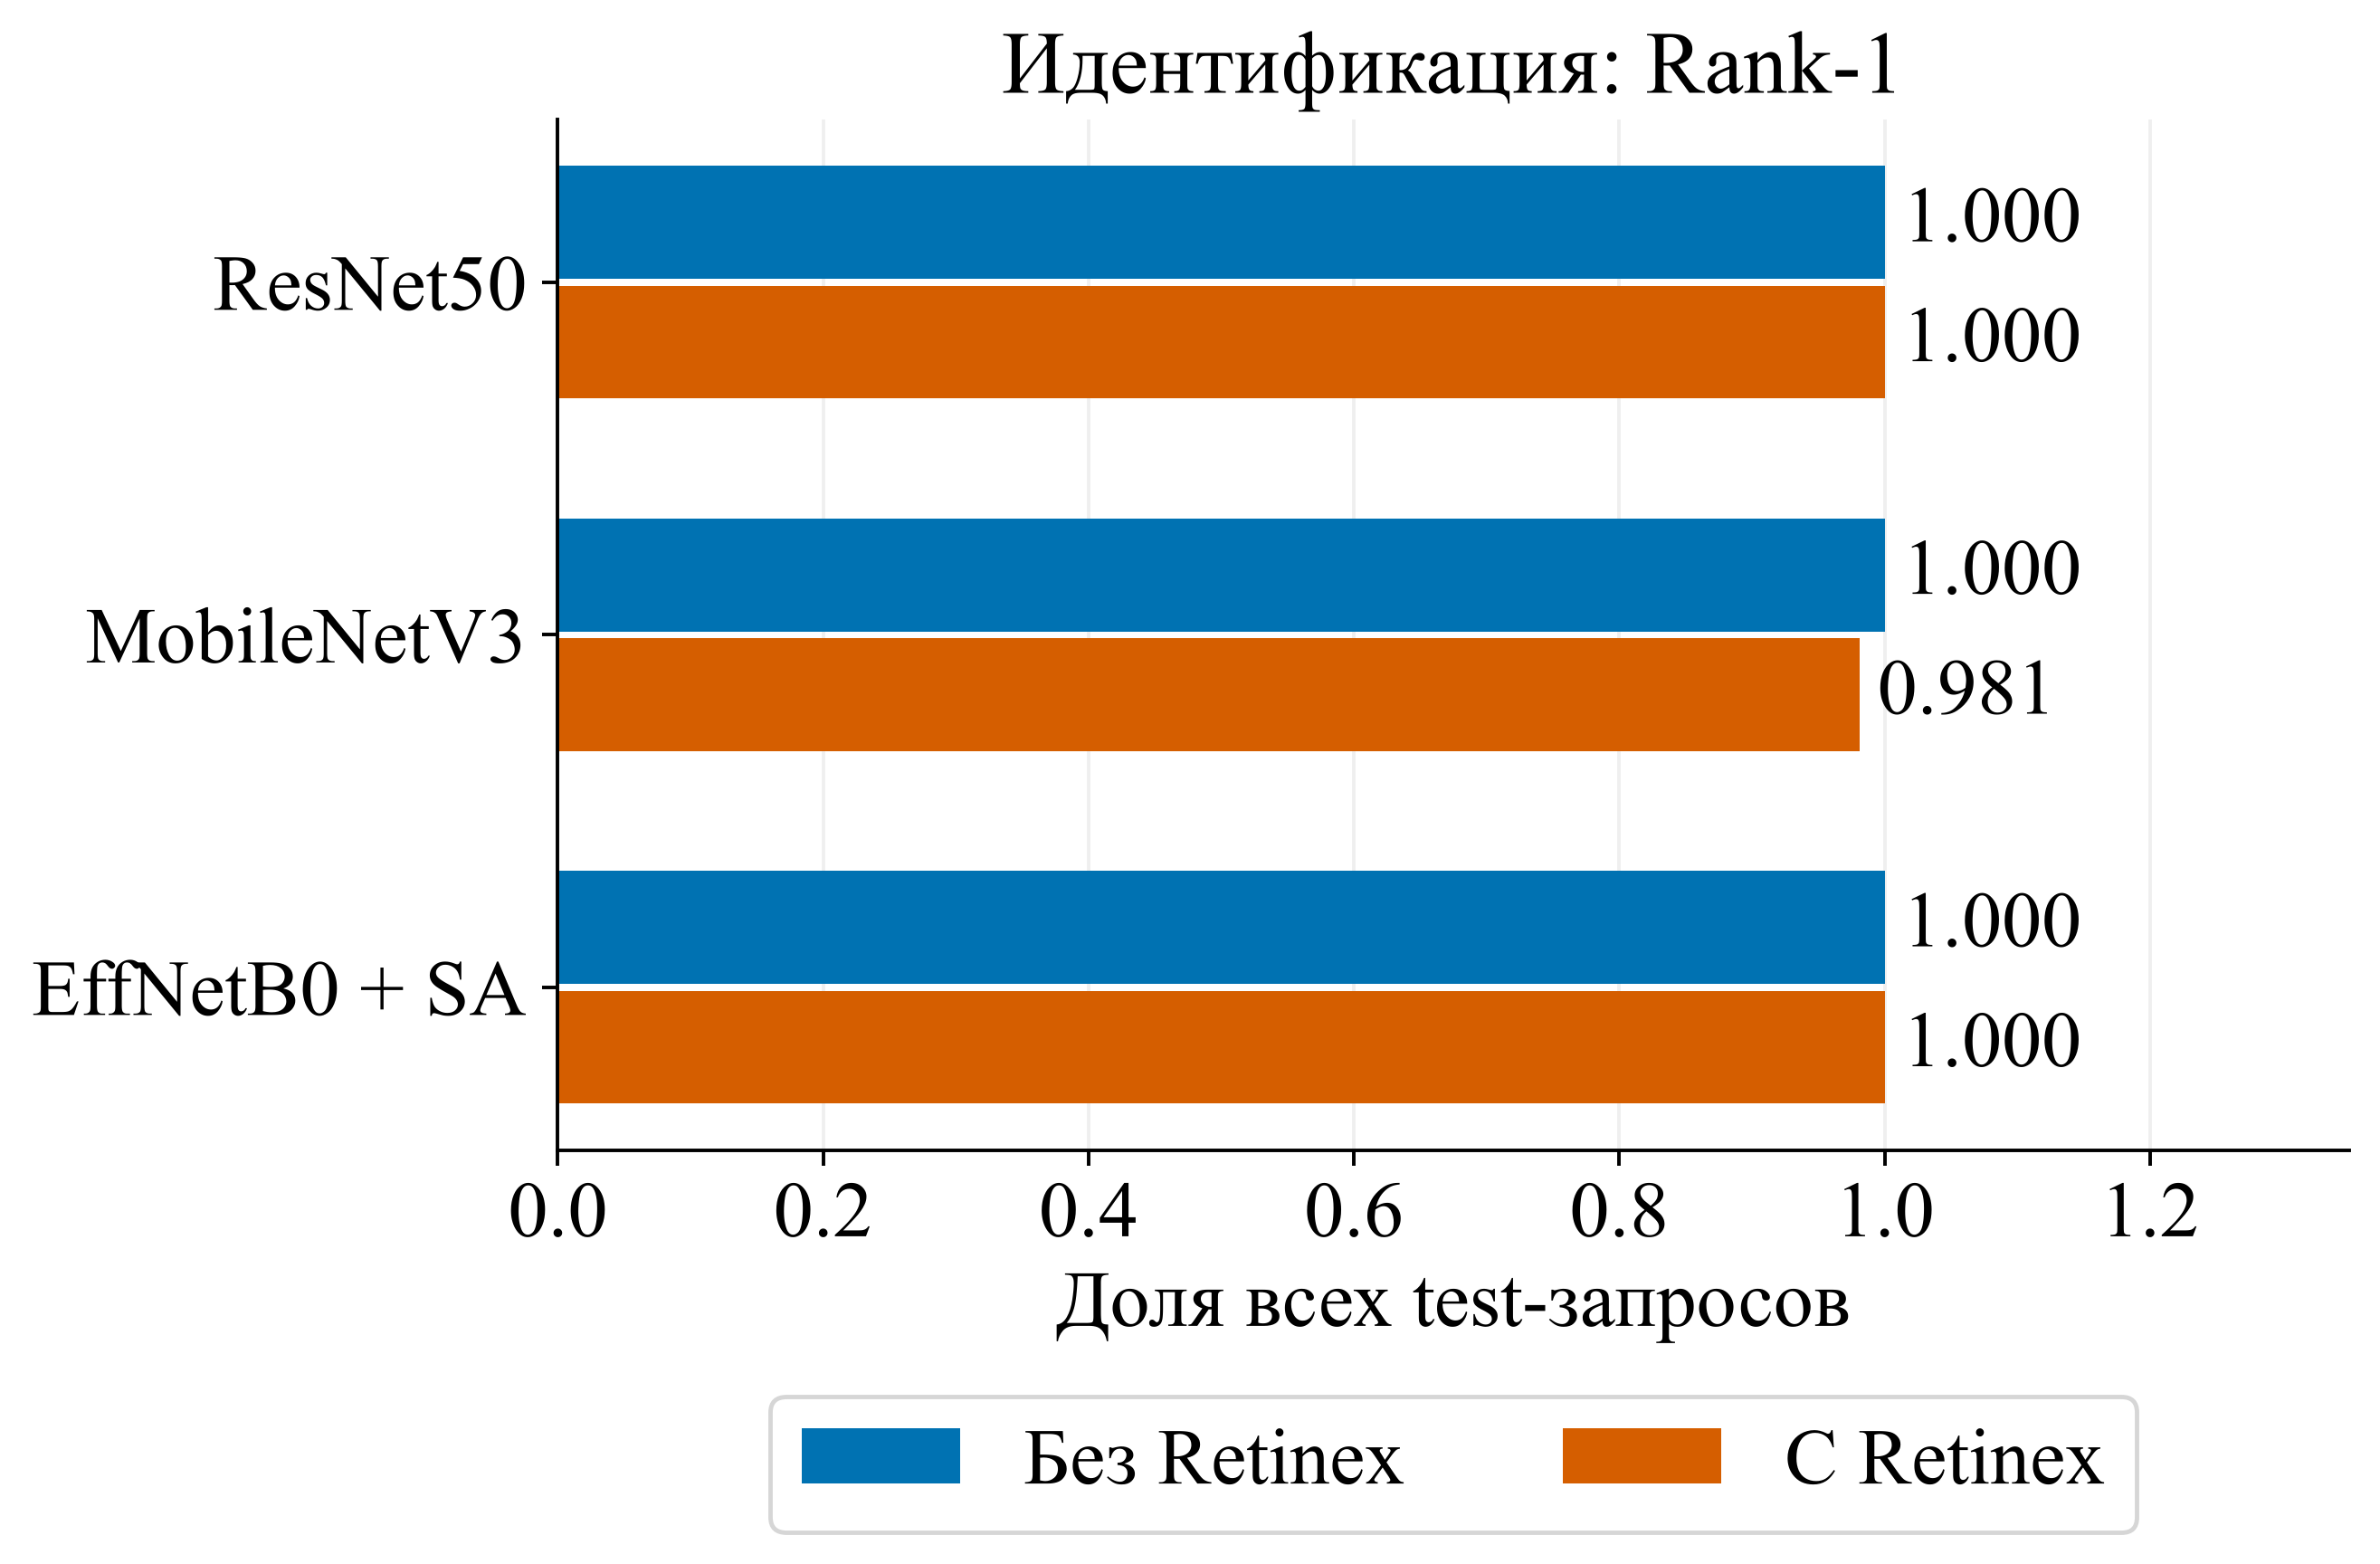

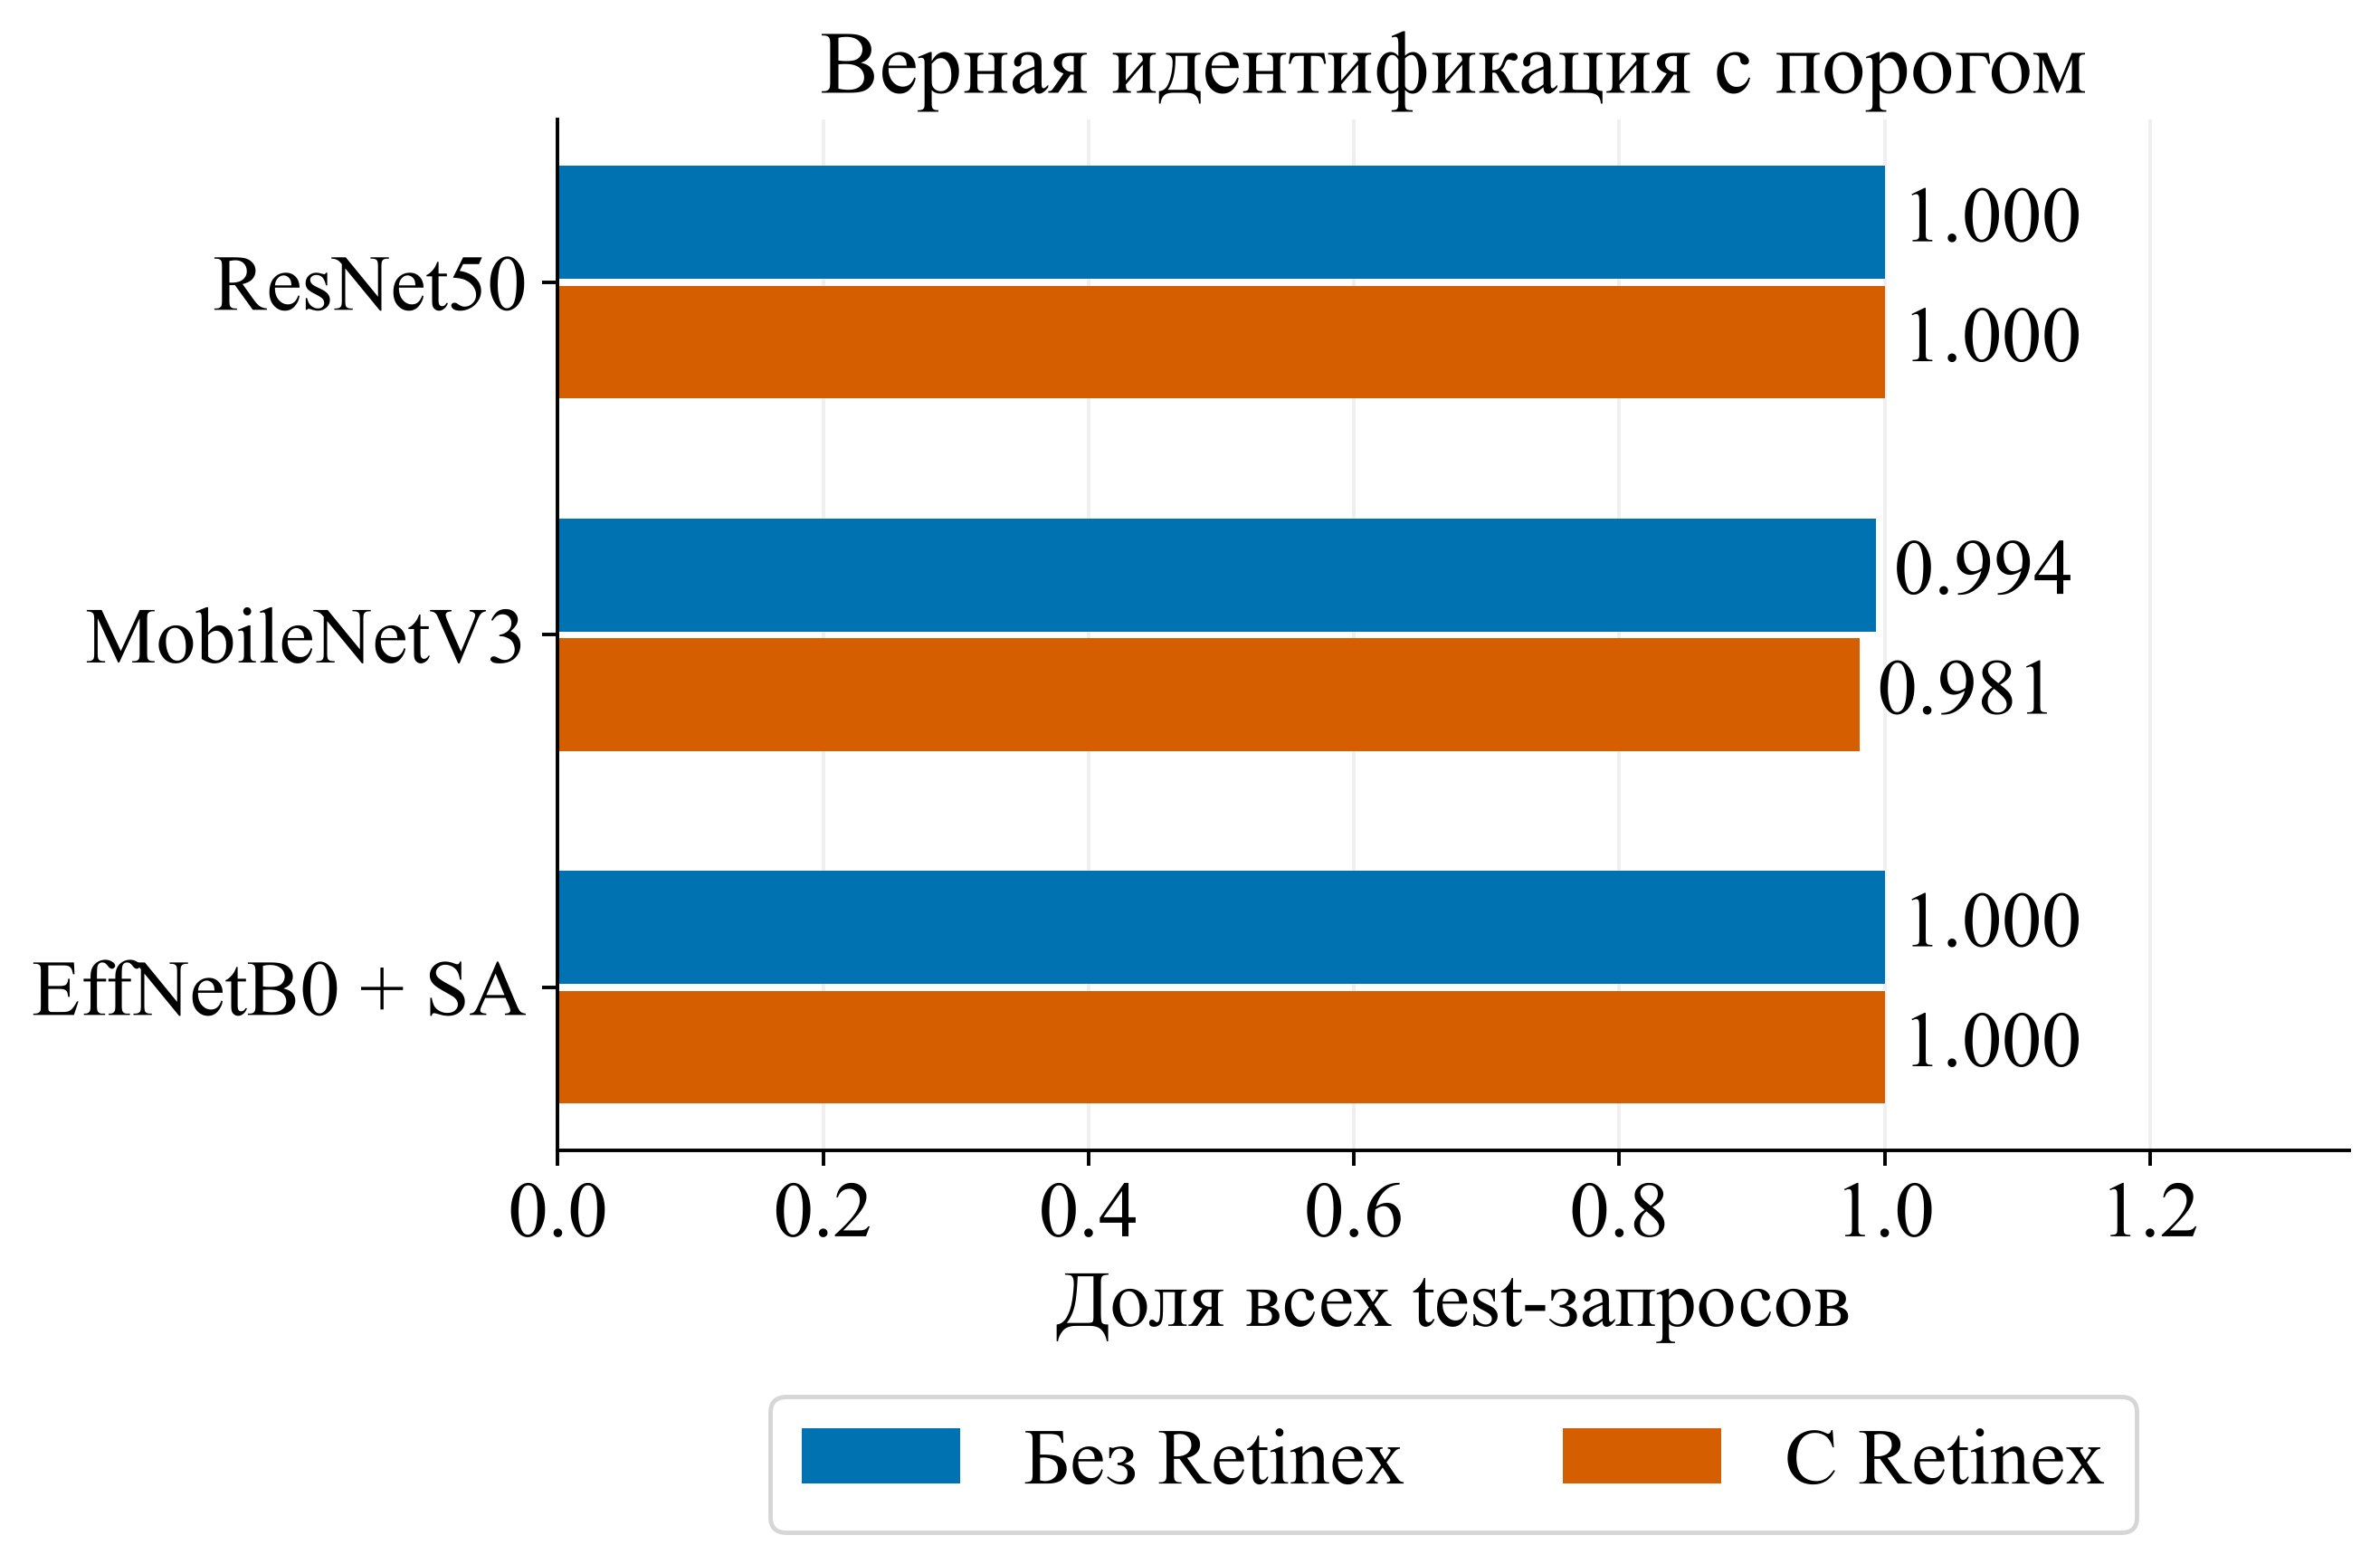

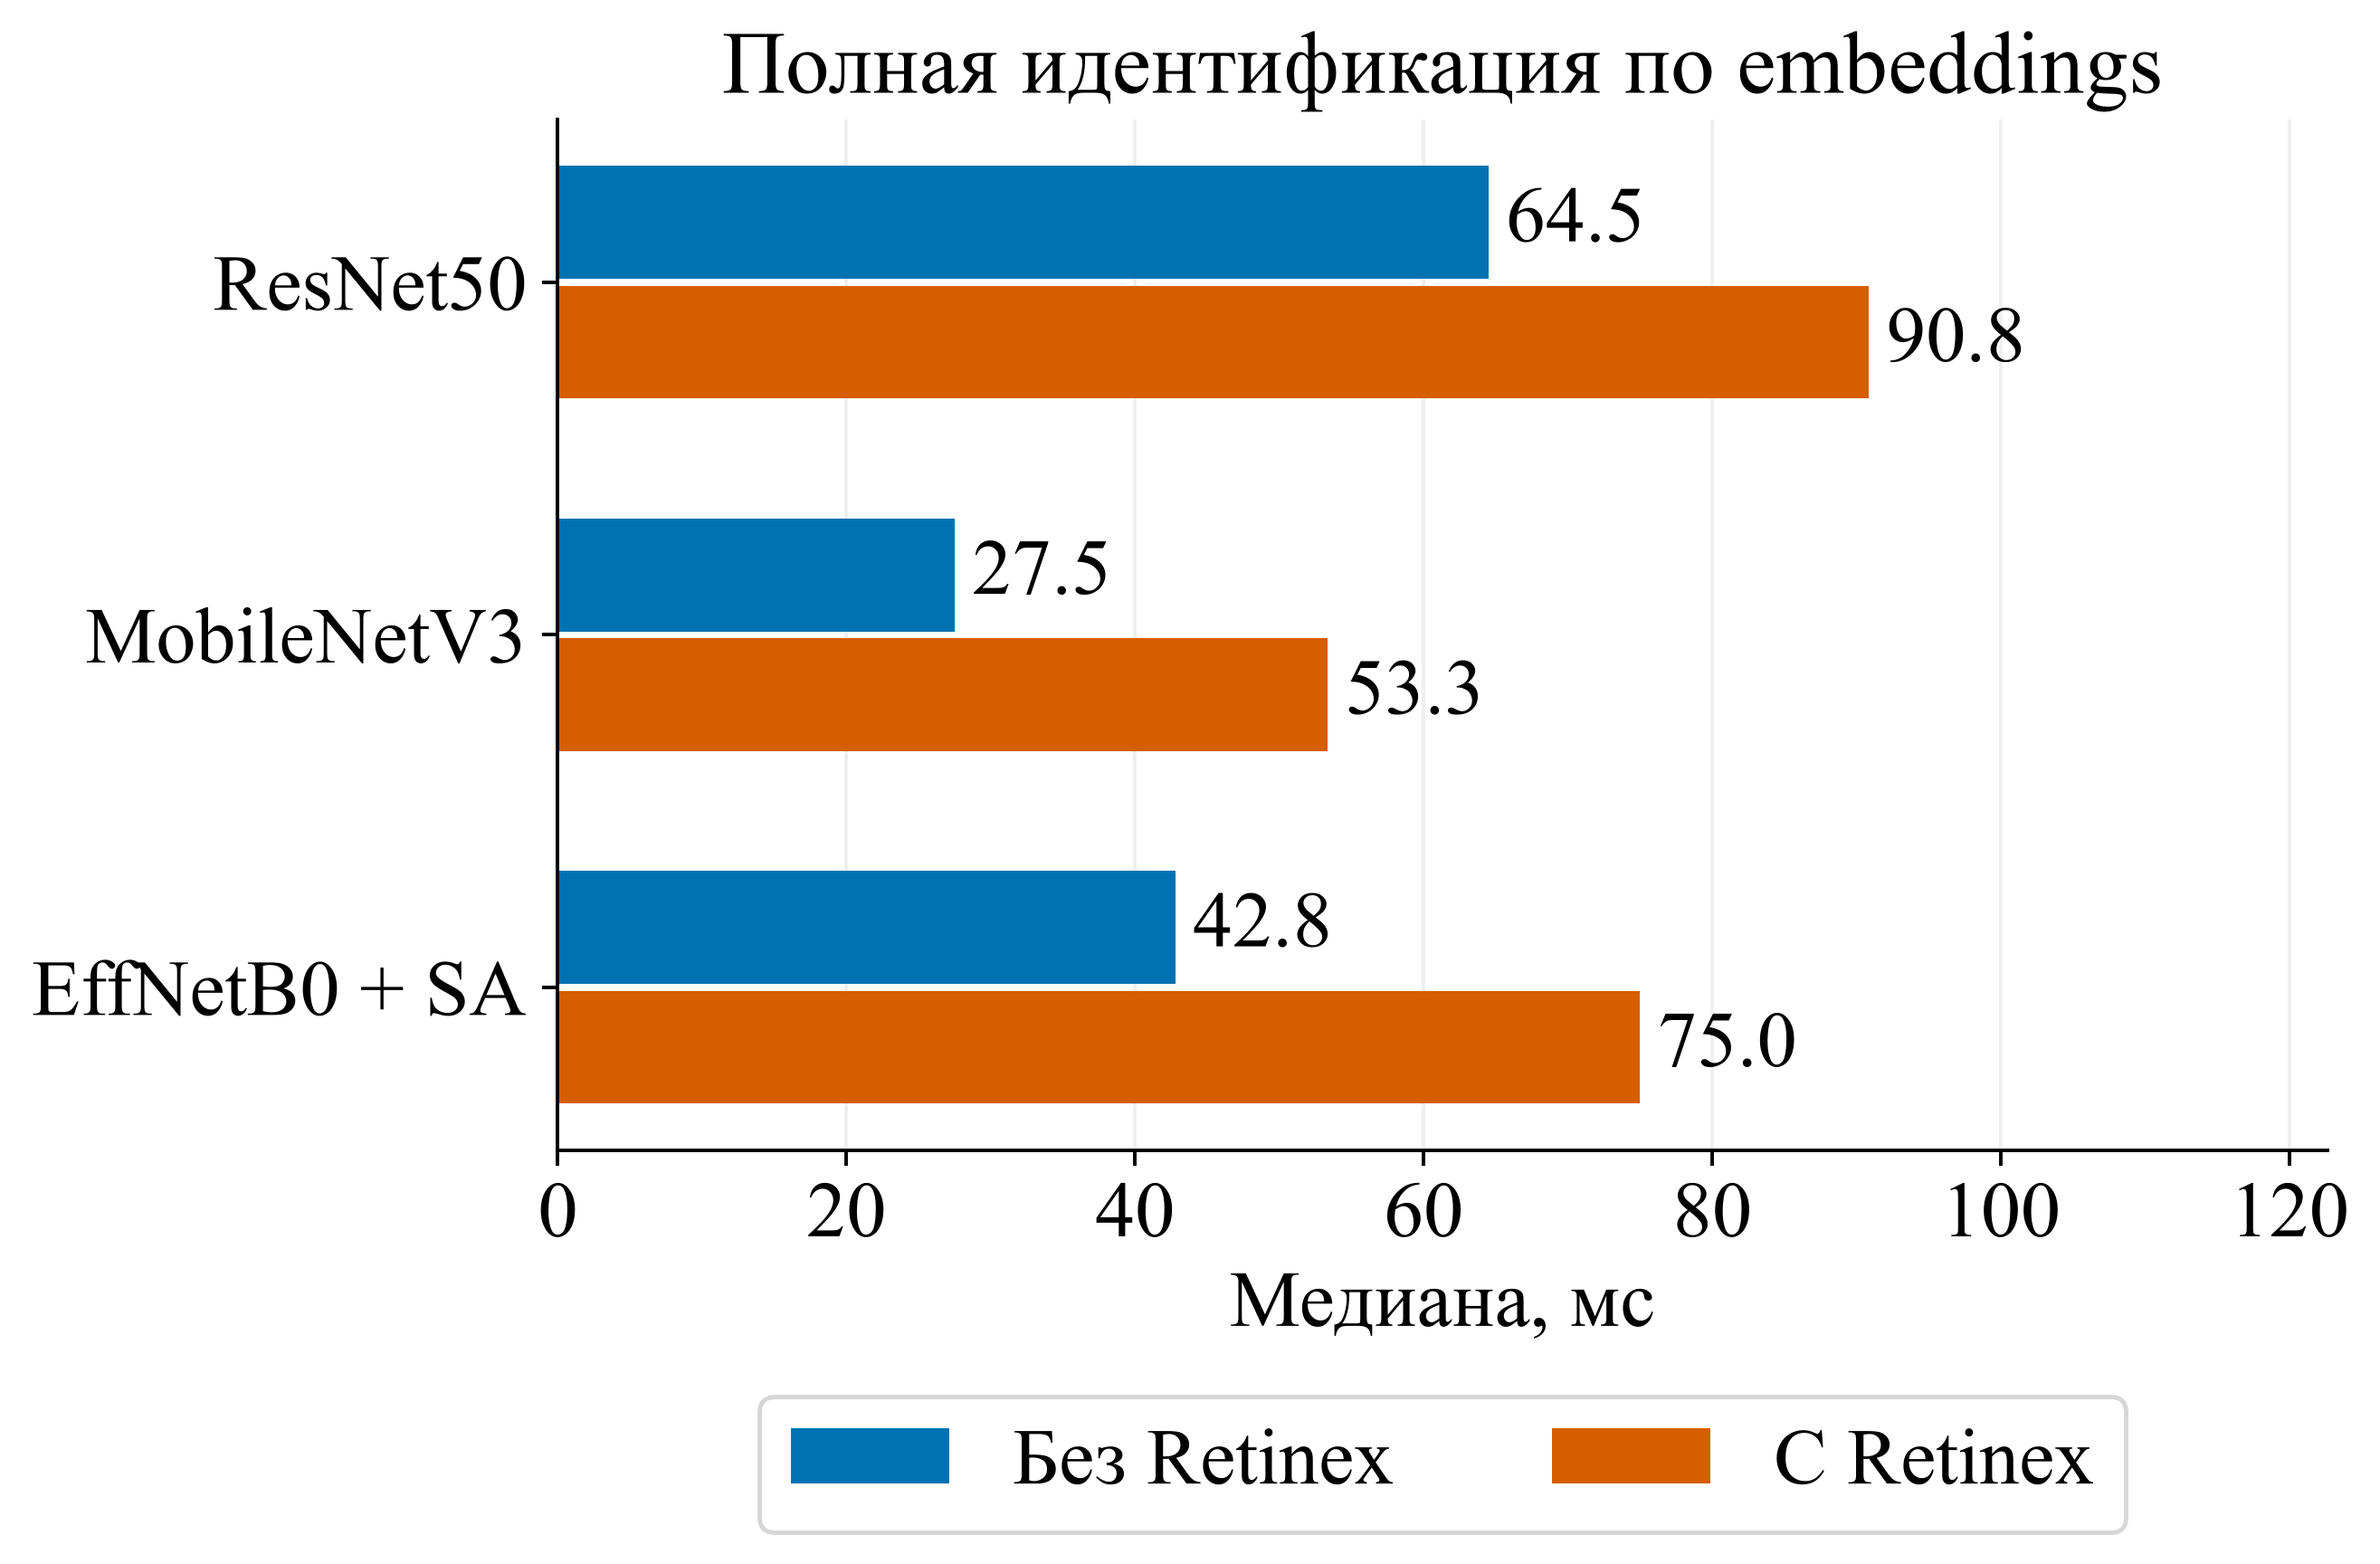

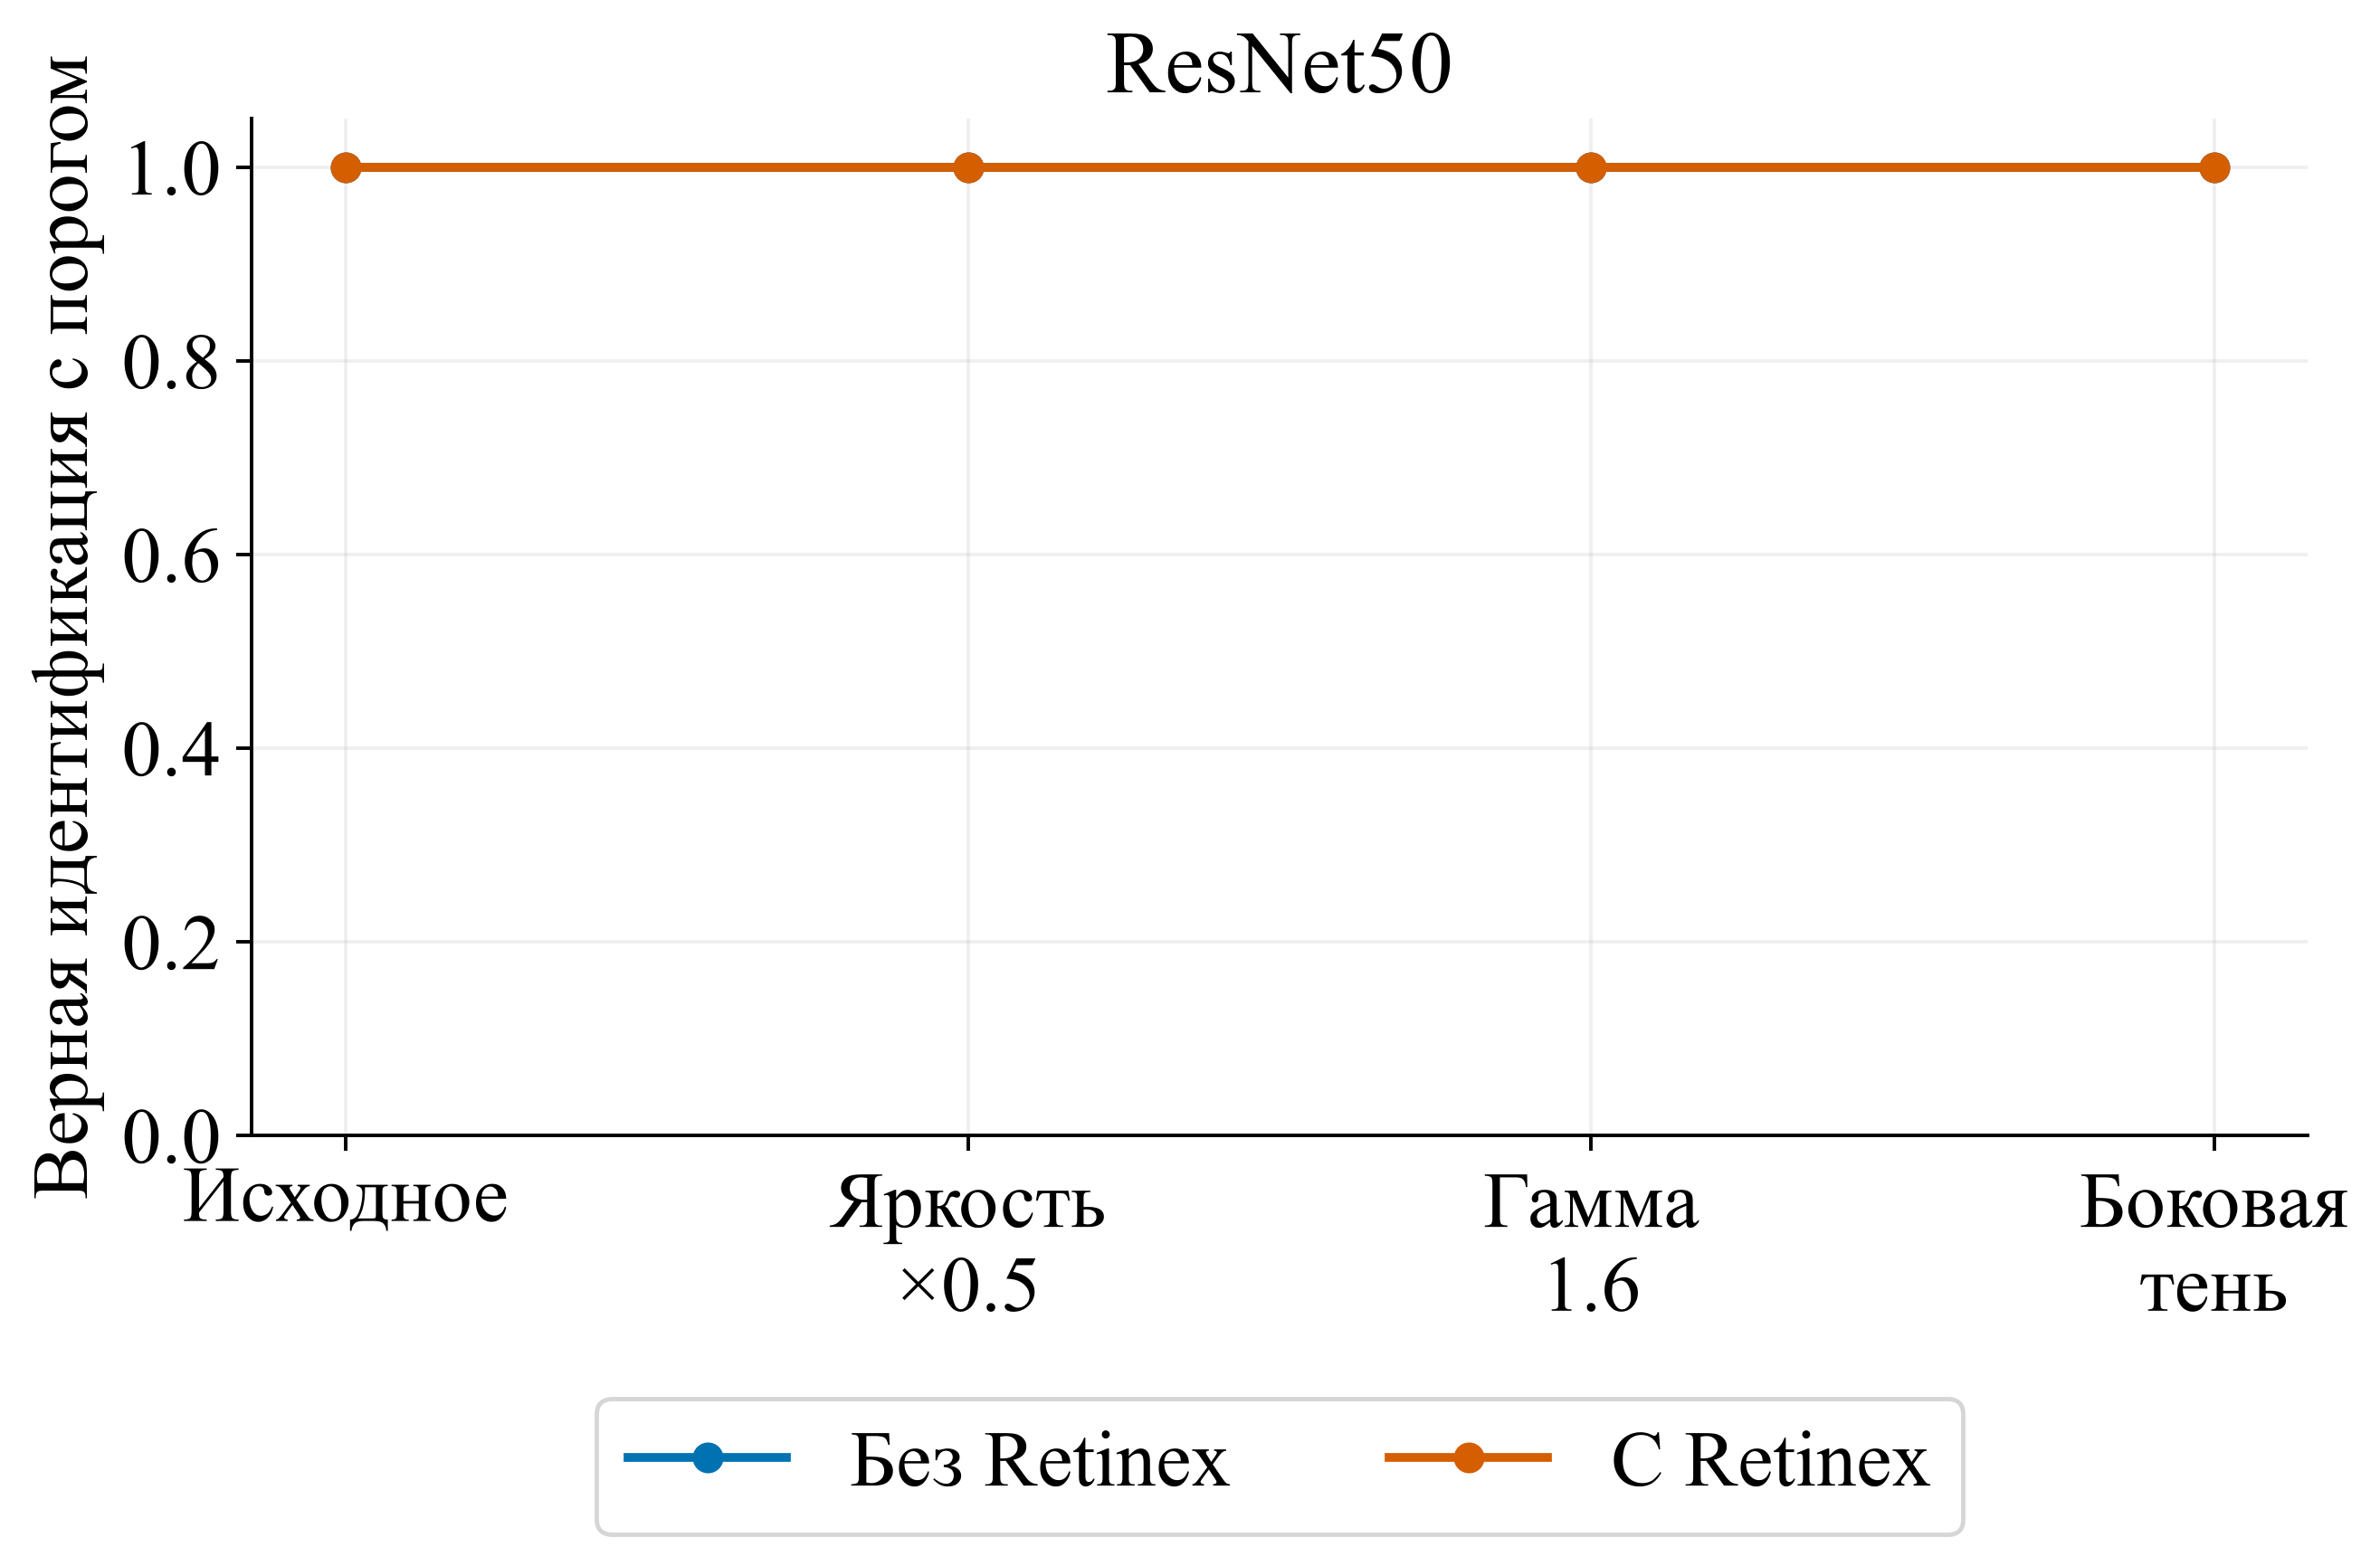

,Без Retinex,С Retinex,"Δ, п.п."
condition,,,
original,1.000,1.000,0.000
brightness_0.5,1.000,1.000,0.000
gamma_1.6,1.000,1.000,0.000
side_shadow,1.000,1.000,0.000


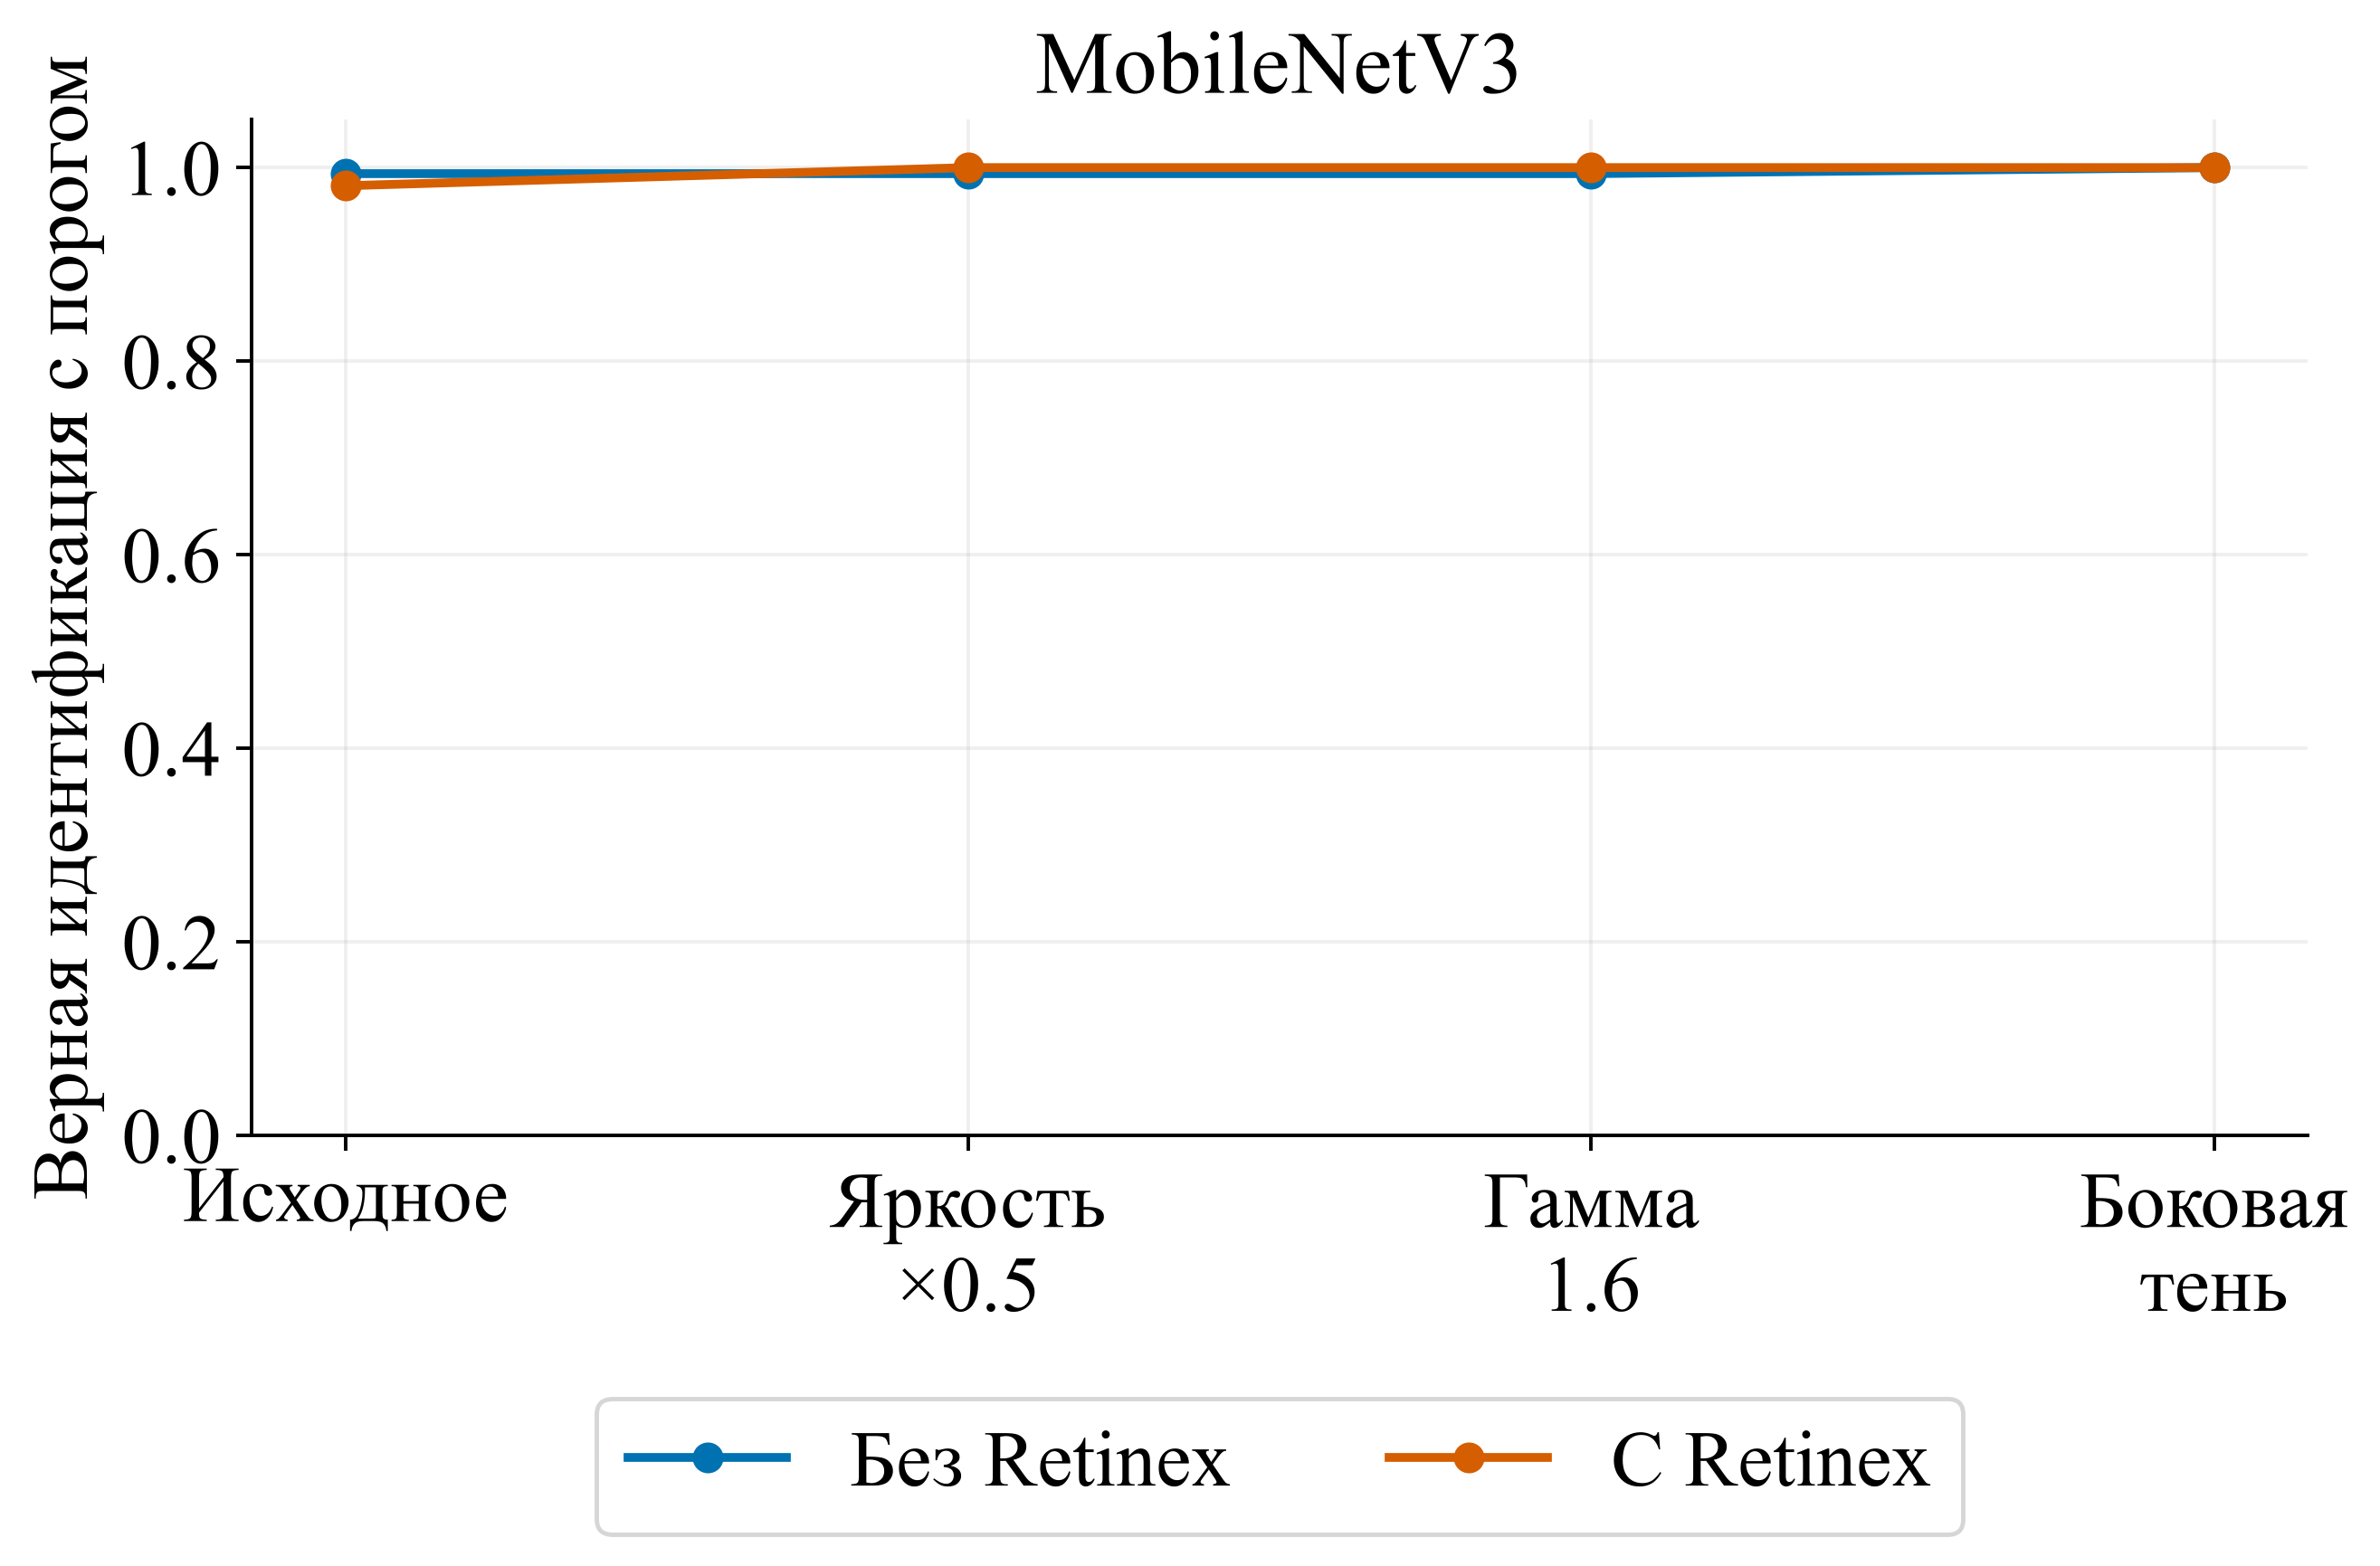

,Без Retinex,С Retinex,"Δ, п.п."
condition,,,
original,0.994,0.981,-1.250
brightness_0.5,0.994,1.000,0.625
gamma_1.6,0.994,1.000,0.625
side_shadow,1.000,1.000,0.000


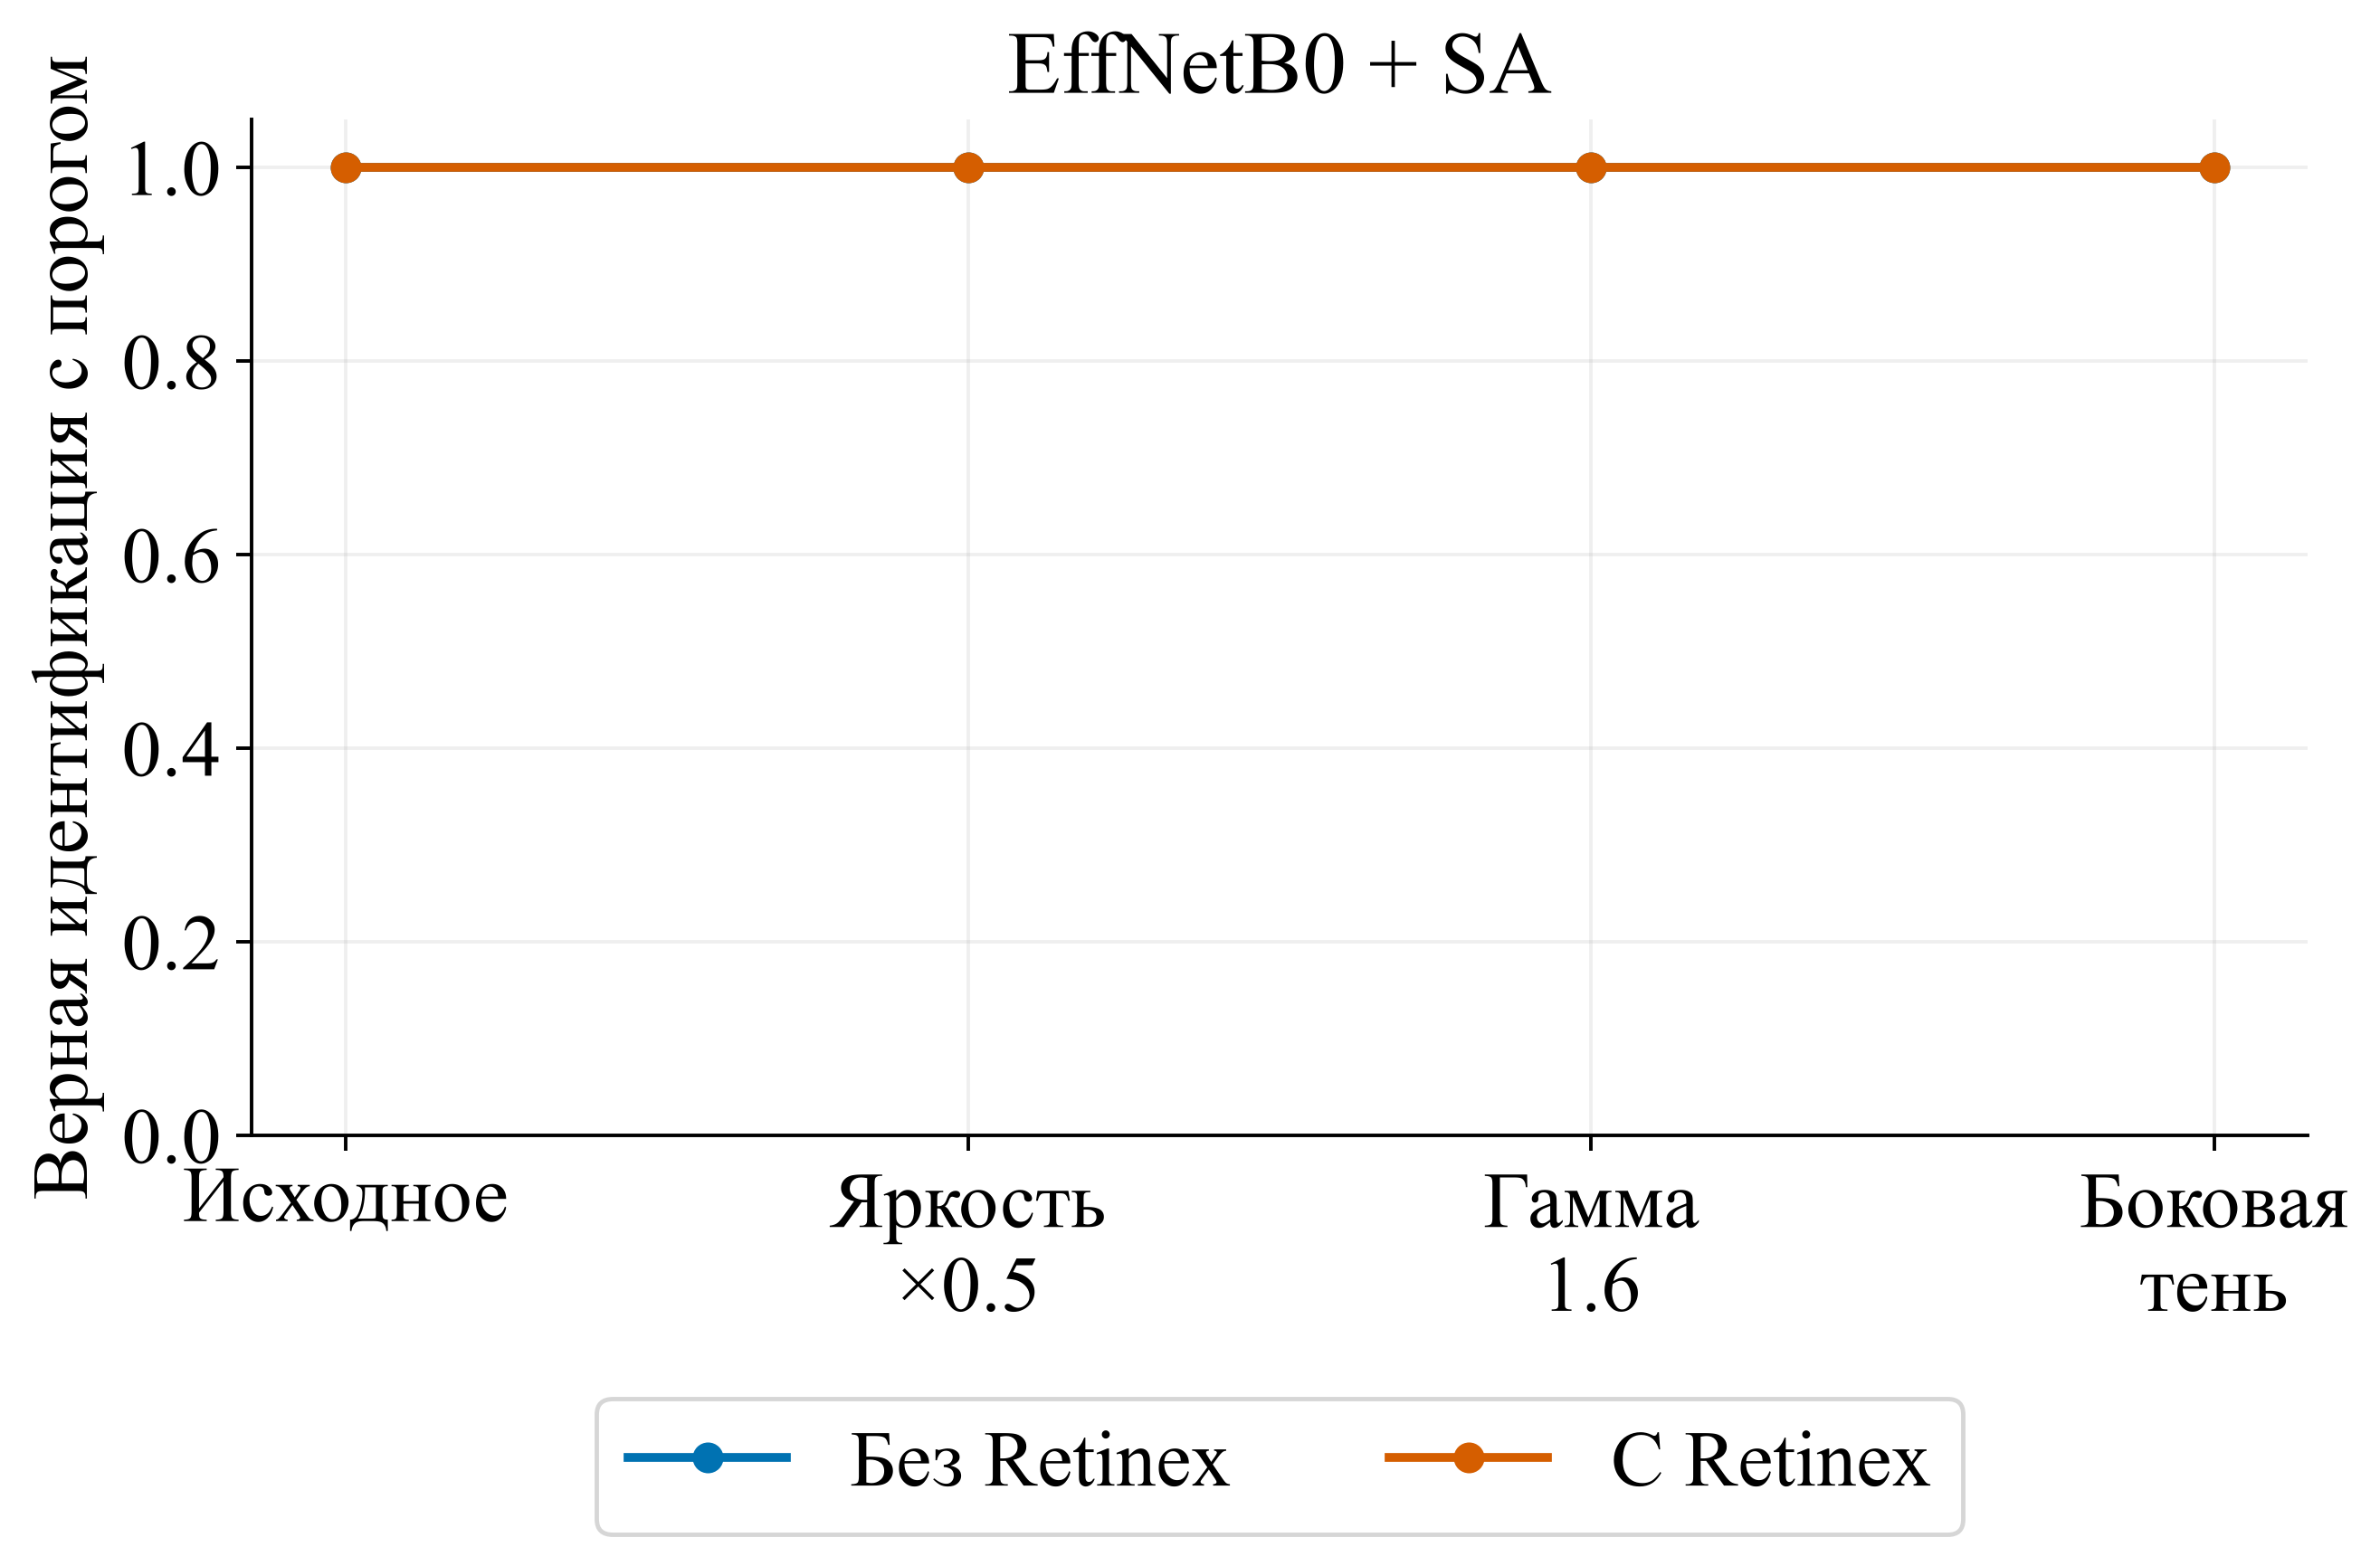

,Без Retinex,С Retinex,"Δ, п.п."
condition,,,
original,1.000,1.000,0.000
brightness_0.5,1.000,1.000,0.000
gamma_1.6,1.000,1.000,0.000
side_shadow,1.000,1.000,0.000


Преимущества оцениваются по фактическим разностям. Гарантия улучшения Retinex не предполагается.
Один seed; автоматическая разметка; независимость съёмочных сессий и пересечение с VGGFace2 не подтверждены.
Все вычисления этого блокнота завершены.


In [23]:
for name in MODEL_NAMES:
    part = identity_table[identity_table.model == name].copy()
    part['Train → inference'] = part.apply(lambda x: f"{'ON' if x.train_retinex else 'OFF'} → {'ON' if x.infer_retinex else 'OFF'}", axis=1)
    frame = part.set_index('Train → inference')[['rank1', 'dir', 'wrong_acceptance', 'rejection_rate', 'threshold']].T
    frame.index = ['Rank-1', 'DIR с порогом', 'Ошибочно принято', 'Отклонено', 'Порог расстояния']
    scientific_table(frame, MODEL_LABELS[name] + ' · идентификация по embeddings')

matched = identity_table[identity_table.train_retinex == identity_table.infer_retinex]
for metric, title, unit in [('rank1', 'Идентификация: Rank-1', 'Доля всех test-запросов'),
                            ('dir', 'Верная идентификация с порогом', 'Доля всех test-запросов'),
                            ('identification_median_ms', 'Полная идентификация по embeddings', 'Медиана, мс')]:
    fig, ax = plt.subplots(figsize=(7.4, 4.8), layout='constrained')
    maximum = 0
    for index, retinex in enumerate((False, True)):
        values = [float(matched[(matched.model == name) & (matched.infer_retinex == retinex)].iloc[0][metric]) for name in MODEL_NAMES]
        variant = 'with_retinex' if retinex else 'without_retinex'
        bars = ax.barh(np.arange(3) + (index - 0.5) * 0.34, values, height=0.32,
                       color=colors[variant], label=variant_labels[variant])
        ax.bar_label(bars, fmt='%.3f' if metric != 'identification_median_ms' else '%.1f', padding=4, fontsize=18)
        maximum = max(maximum, max(values))
    ax.set_yticks(np.arange(3), [MODEL_LABELS[name] for name in MODEL_NAMES])
    ax.set(xlim=(0, max(0.1, maximum) * 1.35), title=title, xlabel=unit)
    ax.invert_yaxis()
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncols=2)
    ax.grid(axis='x', alpha=0.2)
    ax.set_axisbelow(True)
    plt.show()
    plt.close(fig)

condition_labels = ['Исходное', 'Яркость\n×0.5', 'Гамма\n1.6', 'Боковая\nтень']
for name in MODEL_NAMES:
    fig, ax = plt.subplots(figsize=(7.4, 4.8), layout='constrained')
    for retinex in (False, True):
        part = lighting_table[(lighting_table.model == name) & (lighting_table.retinex == retinex)].set_index('condition').loc[LIGHTING]
        variant = 'with_retinex' if retinex else 'without_retinex'
        ax.plot(range(4), part['dir'], marker='o', linewidth=2, color=colors[variant], label=variant_labels[variant])
    ax.set_xticks(range(4), condition_labels)
    ax.set(title=MODEL_LABELS[name], ylabel='Верная идентификация с порогом', ylim=(0, 1.05))
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncols=2)
    ax.grid(alpha=0.2)
    plt.show()
    plt.close(fig)
    part = lighting_table[lighting_table.model == name].pivot(index='condition', columns='retinex', values='dir').loc[LIGHTING]
    part.columns = ['Без Retinex', 'С Retinex']
    part['Δ, п.п.'] = 100 * (part['С Retinex'] - part['Без Retinex'])
    scientific_table(part, MODEL_LABELS[name] + ' · освещённость и DIR')

speed = matched.set_index(['model', 'infer_retinex'])[['identification_median_ms', 'identification_p95_ms',
              'identification_fps', 'benchmark_detection_coverage']]
scientific_table(speed, 'Чтение → Retinex → детектор → FaceNet → поиск эталона')
print('Преимущества оцениваются по фактическим разностям. Гарантия улучшения Retinex не предполагается.')
print('Один seed; автоматическая разметка; независимость съёмочных сессий и пересечение с VGGFace2 не подтверждены.')

assert all(len(histories[(name, variant)]) == 15 for name in MODEL_NAMES for variant in VARIANTS)
assert len(identity_table) == 12 and len(lighting_table) == 24
completed = {'status': 'complete', 'notebook_code_sha256': NOTEBOOK_CODE_HASH, 'dataset': str(DATA_ROOT), 'protocol_hash': PROTOCOL_HASH,
             'epochs': 15, 'detector_runs': 6, 'identity_combinations': 12, 'lighting_results': 24,
             'embedding': 'FaceNet VGGFace2 frozen 512D', 'gallery': 'train only',
             'threshold_calibration': 'validation only', 'figures_inline_only': True,
             'figure_dpi': 350, 'font': 'Times New Roman', 'font_sizes': [18, 20],
             'completed_at': time.time()}
write_json(RUN / 'completion.json', completed)
write_json(RUN / 'work_status.json', completed)
print('Все вычисления этого блокнота завершены.')
